In [ ]:
# ==============================================================================
# DESCRIPTIVE ANALYSIS
# ==============================================================================

In [ ]:
# ==============================================================================
# Imports, configuration, loading and general helpers
# ==============================================================================
import os
import gc
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

warnings.filterwarnings("ignore", category=FutureWarning)

# --- Configuration ---
FILE_NAME = 'dados_uteis_refreshed_v3_memorysafe.pkl'
DATA_PATH = Path('..') / 'data' / 'processed' / FILE_NAME
OUTPUT_DIR = Path('..') / 'reports' / 'descriptive_analysis_refreshed_v3'
TABLE_DIR = OUTPUT_DIR / 'tables'
FIG_DIR = OUTPUT_DIR / 'figures'

for path in [OUTPUT_DIR, TABLE_DIR, FIG_DIR]:
    path.mkdir(parents=True, exist_ok=True)

TARGET = 'ausencia'
SEED = 42
PLOT_SAMPLE_N = 250_000          # Sample used only for expensive plots.
MAX_CATEGORIES_TO_PLOT = 15      # Top categories shown when cardinality is high.
MIN_GROUP_N_FOR_RATE_TABLE = 100 # Keep small groups in CSV, but flag them as low-support.
FIG_DPI = 150

# --- Visual style ---
sns.set_theme(style='whitegrid')
plot_palette_binary = {0: '#3498db', 1: '#e74c3c'}
status_palette = {'Compareceu (0)': '#3498db', 'Faltou (1)': '#e74c3c'}

print(f"Loading checkpoint file: {DATA_PATH}...")
try:
    df_2023 = pd.read_pickle(DATA_PATH)
    print('✅ DataFrame loaded successfully.')
    print(f'Shape of loaded data: {df_2023.shape}')
except FileNotFoundError:
    raise FileNotFoundError(f"❌ ERROR: The checkpoint file was not found at {DATA_PATH}")
except Exception as e:
    raise RuntimeError(f"An unexpected error occurred while loading the dataset: {e}")

# --- Helper functions ---
def br_number(x):
    """Format integer-like numbers using Brazilian thousands separator."""
    try:
        return f"{int(x):,}".replace(',', '.')
    except Exception:
        return str(x)


def br_decimal(x, digits=2):
    """Format decimal numbers using comma as decimal separator."""
    if pd.isna(x):
        return ''
    return f"{float(x):.{digits}f}".replace('.', ',')


def br_percent(x, digits=2):
    """Format a proportion as Brazilian percentage."""
    if pd.isna(x):
        return ''
    return f"{float(x) * 100:.{digits}f}".replace('.', ',') + '%'


def save_current_figure(file_stem):
    """Save current matplotlib figure using the common output directory."""
    safe_stem = str(file_stem).replace(' ', '_').replace('/', '_').replace('\\', '_')
    path = FIG_DIR / f"{safe_stem}.png"
    plt.savefig(path, dpi=FIG_DPI, bbox_inches='tight')
    print(f"Saved figure: {path}")


def available_columns(columns):
    """Return only columns that exist in df_2023, preserving order."""
    return [col for col in columns if col in df_2023.columns]


def require_columns(columns, context=''):
    """Raise a clear error if required columns are missing."""
    missing = [col for col in columns if col not in df_2023.columns]
    if missing:
        raise KeyError(f"Missing required columns for {context}: {missing}")


def smart_sample(df, n=PLOT_SAMPLE_N, seed=SEED):
    """Stratified sample for plotting. Tables/statistics should still use full data."""
    if len(df) <= n:
        return df.copy()
    if TARGET in df.columns:
        # Preserve the target distribution in plots.
        return (
            df.groupby(TARGET, group_keys=False, observed=True)
              .apply(lambda x: x.sample(max(1, int(round(n * len(x) / len(df)))), random_state=seed))
              .reset_index(drop=True)
        )
    return df.sample(n=n, random_state=seed).reset_index(drop=True)


def format_numeric_table_br(table, digits=3):
    """Return a display version with BR decimal formatting."""
    out = table.copy()
    for col in out.columns:
        if pd.api.types.is_numeric_dtype(out[col]):
            out[col] = out[col].map(lambda x: br_decimal(x, digits))
    return out


def save_table(df, file_name, index=False):
    path = TABLE_DIR / file_name
    df.to_csv(path, index=index)
    print(f"Saved table: {path}")
    return path

# --- Basic data checks ---
require_columns([TARGET], context='target analysis')
if not set(df_2023[TARGET].dropna().unique()).issubset({0, 1}):
    raise ValueError(f"Target column {TARGET} must contain only 0/1 values.")

# Make sure date column is datetime when available.
if 'dta_atend' in df_2023.columns and not pd.api.types.is_datetime64_any_dtype(df_2023['dta_atend']):
    df_2023['dta_atend'] = pd.to_datetime(df_2023['dta_atend'], errors='coerce')

# Create day-of-week feature for temporal analyses if it is not already present.
if 'dta_atend' in df_2023.columns and 'dia_da_semana' not in df_2023.columns:
    df_2023['dia_da_semana'] = df_2023['dta_atend'].dt.dayofweek

print('\nAssessing all columns for missing (NaN) values...')
missing_counts = df_2023.isnull().sum()
missing_counts_filtered = missing_counts[missing_counts > 0].sort_values(ascending=False)

if missing_counts_filtered.empty:
    print('✅ No missing (NaN) values found in any column.')
else:
    print('Found missing values in the following columns:')
    display(missing_counts_filtered)
    save_table(missing_counts_filtered.rename('missing_count').reset_index().rename(columns={'index': 'column'}),
               'missing_values_by_column.csv')

total_missing = int(missing_counts.sum())
total_cells = int(df_2023.size)
percentage = (total_missing / total_cells) * 100 if total_cells > 0 else 0
print('-' * 50)
print(f"Grand Total of missing cells: {br_number(total_missing)} ({br_decimal(percentage, 4)}%)")
print(f"Memory usage: {df_2023.memory_usage(deep=True).sum() / 1024**3:.2f} GB")


Loading checkpoint file: ../data/processed/dados_uteis_refreshed_v3_memorysafe.pkl...
✅ DataFrame loaded successfully.
Shape of loaded data: (7113798, 42)

Assessing all columns for missing (NaN) values...
✅ No missing (NaN) values found in any column.
--------------------------------------------------
Grand Total of missing cells: 0 (0,0000%)
Memory usage: 5.66 GB


In [ ]:
# ==============================================================================
# Data quality audit
# ==============================================================================
import numpy as np

print("--- STARTING DATA QUALITY AUDIT ---")

quality_rows = []

def add_quality_check(check_name, condition, severity='warning'):
    """Append one row to the audit table."""
    count = int(condition.sum()) if hasattr(condition, 'sum') else int(condition)
    quality_rows.append({
        'check': check_name,
        'count': count,
        'percentage': count / len(df_2023) if len(df_2023) else np.nan,
        'severity': severity,
    })
    print(f"{check_name}: {br_number(count)} ({br_percent(count / len(df_2023) if len(df_2023) else 0)})")

# --- 1. NEGATIVE TEMPO_ESPERA ---
if 'tempo_espera' in df_2023.columns:
    add_quality_check('negative_tempo_espera', df_2023['tempo_espera'] < 0, severity='critical')

# --- 2. PERCENTUAL_FALTAS consistency ---
if {'contagem_faltas_anteriores', 'total_consultas_anteriores', 'percentual_faltas_anteriores'}.issubset(df_2023.columns):
    expected_percent = (
        pd.to_numeric(df_2023['contagem_faltas_anteriores'], errors='coerce').astype('float64') /
        pd.to_numeric(df_2023['total_consultas_anteriores'], errors='coerce').replace(0, 1).astype('float64')
    ).clip(0, 1)
    actual_percent = pd.to_numeric(df_2023['percentual_faltas_anteriores'], errors='coerce').astype('float64')
    diff = (actual_percent - expected_percent).abs()
    add_quality_check('percentual_faltas_inconsistent_gt_1e_minus_6', diff > 1e-6, severity='warning')

# --- 3. DISTANCE_KM sanity ---
if 'distance_km' in df_2023.columns:
    distance = pd.to_numeric(df_2023['distance_km'], errors='coerce')
    add_quality_check('negative_distance_km', distance < 0, severity='critical')
    add_quality_check('distance_km_equal_zero', distance == 0, severity='info')
    add_quality_check('distance_km_above_1000', distance > 1000, severity='warning')

# --- 4. CEP prefix quality checks from refreshed dataset ---
for col in ['cep_prefix_len_usuario', 'cep_prefix_len_cnes']:
    if col in df_2023.columns:
        values = pd.to_numeric(df_2023[col], errors='coerce')
        add_quality_check(f'{col}_below_5', values < 5, severity='warning')
        add_quality_check(f'{col}_exact_match_8', values == 8, severity='info')

# --- 5. Target sanity ---
add_quality_check('target_not_0_or_1', ~df_2023[TARGET].isin([0, 1]), severity='critical')

quality_audit = pd.DataFrame(quality_rows)
quality_audit['percentage_br'] = quality_audit['percentage'].map(lambda x: br_percent(x))
save_table(quality_audit, 'data_quality_audit_for_descriptive_analysis.csv')
display(quality_audit)

print("--- AUDIT COMPLETE ---")
print("No values were modified in df_2023 by this cell.")


--- STARTING DATA QUALITY AUDIT ---
negative_tempo_espera: 0 (0,00%)
percentual_faltas_inconsistent_gt_1e_minus_6: 0 (0,00%)
negative_distance_km: 0 (0,00%)
distance_km_equal_zero: 1.201.482 (16,89%)
distance_km_above_1000: 120.937 (1,70%)
cep_prefix_len_usuario_below_5: 0 (0,00%)
cep_prefix_len_usuario_exact_match_8: 5.560.329 (78,16%)
cep_prefix_len_cnes_below_5: 0 (0,00%)
cep_prefix_len_cnes_exact_match_8: 5.647.030 (79,38%)
target_not_0_or_1: 0 (0,00%)
Saved table: ../reports/descriptive_analysis_refreshed_v3/tables/data_quality_audit_for_descriptive_analysis.csv


,check,count,percentage,severity,percentage_br
0,negative_tempo_espera,0,0.000000,critical,"0,00%"
1,percentual_faltas_inconsistent_gt_1e_minus_6,0,0.000000,warning,"0,00%"
2,negative_distance_km,0,0.000000,critical,"0,00%"
3,distance_km_equal_zero,1201482,0.168895,info,"16,89%"
4,distance_km_above_1000,120937,0.017000,warning,"1,70%"
5,cep_prefix_len_usuario_below_5,0,0.000000,warning,"0,00%"
6,cep_prefix_len_usuario_exact_match_8,5560329,0.781626,info,"78,16%"
7,cep_prefix_len_cnes_below_5,0,0.000000,warning,"0,00%"
8,cep_prefix_len_cnes_exact_match_8,5647030,0.793814,info,"79,38%"
9,target_not_0_or_1,0,0.000000,critical,"0,00%"


--- AUDIT COMPLETE ---
No values were modified in df_2023 by this cell.


--- Target Variable Analysis (ausencia) ---
Saved table: ../reports/descriptive_analysis_refreshed_v3/tables/target_distribution.csv
Total de Agendamentos: 7.113.798
Total de Faltas: 1.044.553
Taxa de Falta (No-Show): 14,68%
Taxa de Presença: 85,32%
---------------------------------


,label,count_br,percentage_br
0,Compareceu (0),6.069.245,"85,32%"
1,Faltou (1),1.044.553,"14,68%"


Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/01_target_distribution.png


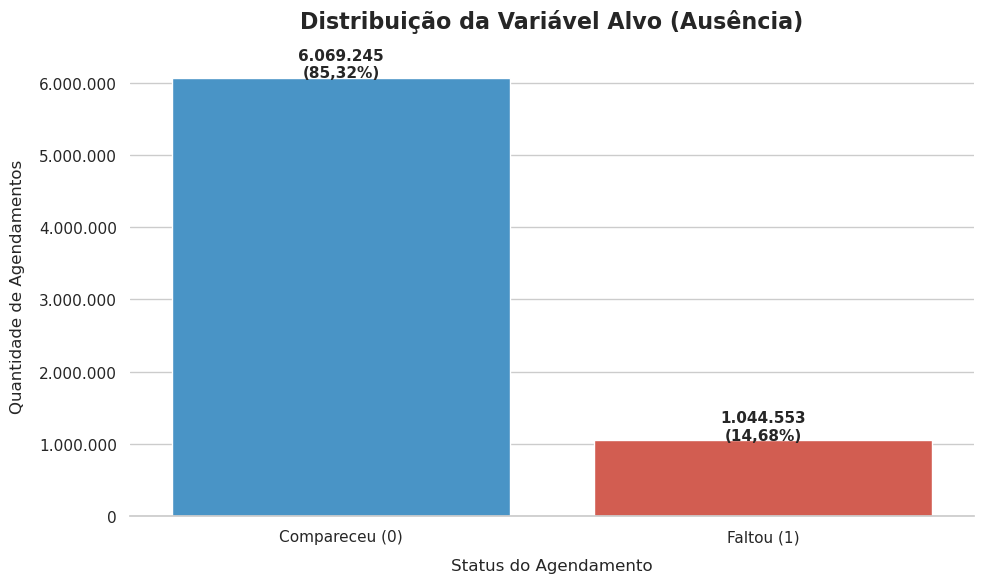

In [ ]:
# ==============================================================================
# Target variable analysis: ausencia
# ==============================================================================
print("--- Target Variable Analysis (ausencia) ---")

# 0 = Compareceu / attended
# 1 = Faltou / no-show
target_counts = (
    df_2023[TARGET]
    .value_counts(dropna=False)
    .rename_axis('ausencia')
    .reset_index(name='count')
    .sort_values('ausencia')
)
target_counts['percentage'] = target_counts['count'] / len(df_2023)
target_counts['label'] = target_counts['ausencia'].map({0: 'Compareceu (0)', 1: 'Faltou (1)'})
target_counts['count_br'] = target_counts['count'].map(br_number)
target_counts['percentage_br'] = target_counts['percentage'].map(br_percent)

save_table(target_counts, 'target_distribution.csv')

total_appointments = len(df_2023)
no_show_count = int(df_2023[TARGET].sum())
no_show_rate = no_show_count / total_appointments

print(f"Total de Agendamentos: {br_number(total_appointments)}")
print(f"Total de Faltas: {br_number(no_show_count)}")
print(f"Taxa de Falta (No-Show): {br_percent(no_show_rate)}")
print(f"Taxa de Presença: {br_percent(1 - no_show_rate)}")
print("---------------------------------")
display(target_counts[['label', 'count_br', 'percentage_br']])

# --- Plot Generation ---
plt.figure(figsize=(10, 6))
ax = sns.countplot(
    data=df_2023,
    x=TARGET,
    palette=plot_palette_binary,
    hue=TARGET,
    legend=False
)

# --- Formatting (PT-BR) ---
ax.set_title('Distribuição da Variável Alvo (Ausência)', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Status do Agendamento', fontsize=12, labelpad=10)
ax.set_ylabel('Quantidade de Agendamentos', fontsize=12, labelpad=10)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Compareceu (0)', 'Faltou (1)'], fontsize=11)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: br_number(x)))

# Add percentage labels (BR format)
for p in ax.patches:
    height = p.get_height()
    percentage = br_percent(height / total_appointments)
    ax.annotate(
        text=f'{br_number(height)}\n({percentage})',
        xy=(p.get_x() + p.get_width() / 2, height),
        ha='center',
        va='center',
        xytext=(0, 10),
        textcoords='offset points',
        fontsize=11,
        fontweight='bold'
    )

sns.despine(left=True)
plt.tight_layout()
save_current_figure('01_target_distribution')
plt.show()


--- Descriptive Statistics for Numerical Features ---
Numerical features analyzed (8): ['idade_usuario', 'tempo_espera', 'distance_km', 'contagem_faltas_anteriores', 'total_consultas_anteriores', 'percentual_faltas_anteriores', 'cep_prefix_len_usuario', 'cep_prefix_len_cnes']
Saved table: ../reports/descriptive_analysis_refreshed_v3/tables/numerical_descriptive_statistics.csv


,count,mean,std,min,25%,50%,75%,max,missing_count,missing_pct,skew,kurtosis
idade_usuario,7113798.0,44.881058,22.804116,0.0,28.0,49.0,63.0,123.0,"0,000","0,000","-0,362","-0,839"
tempo_espera,7113798.0,51.635818,113.821934,0.0,7.0,20.0,54.0,3947.0,"0,000","0,000","7,824","93,248"
distance_km,7113798.0,53.71347,212.94725,0.0,1.428954,4.768192,14.269498,4172.231445,"0,000","0,000","7,363","66,243"
contagem_faltas_anteriores,7113798.0,0.206664,0.977725,0.0,0.0,0.0,0.0,58.0,"0,000","0,000","14,529","350,211"
total_consultas_anteriores,7113798.0,1.796986,5.357801,0.0,0.0,0.0,2.0,218.0,"0,000","0,000","9,915","148,783"
percentual_faltas_anteriores,7113798.0,0.057726,0.188529,0.0,0.0,0.0,0.0,1.0,"0,000","0,000","3,835","14,483"
cep_prefix_len_usuario,7113798.0,7.564518,0.898277,5.0,8.0,8.0,8.0,8.0,"0,000","0,000","-1,880","2,097"
cep_prefix_len_cnes,7113798.0,7.579564,0.88937,5.0,8.0,8.0,8.0,8.0,"0,000","0,000","-1,915","2,203"


---------------------------------------------------------
Plot sample size: 250.000
Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/02_univariate_numeric_idade_usuario.png


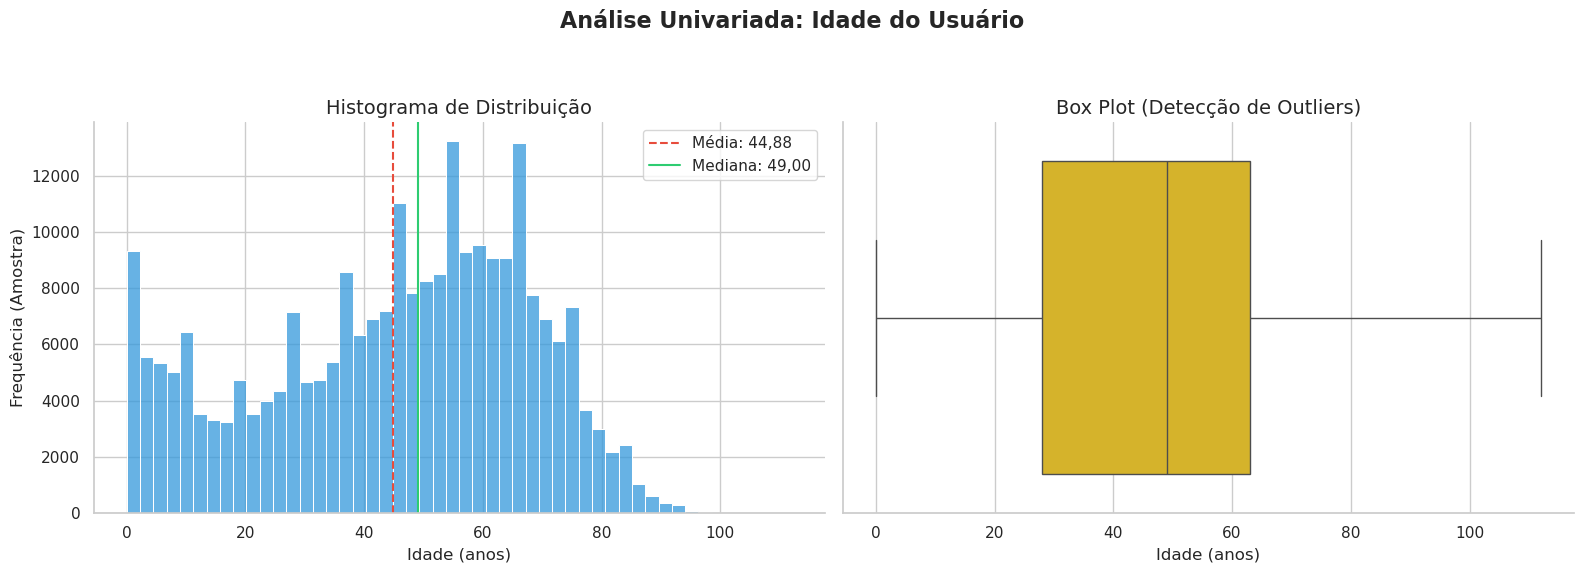

Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/02_univariate_numeric_tempo_espera.png


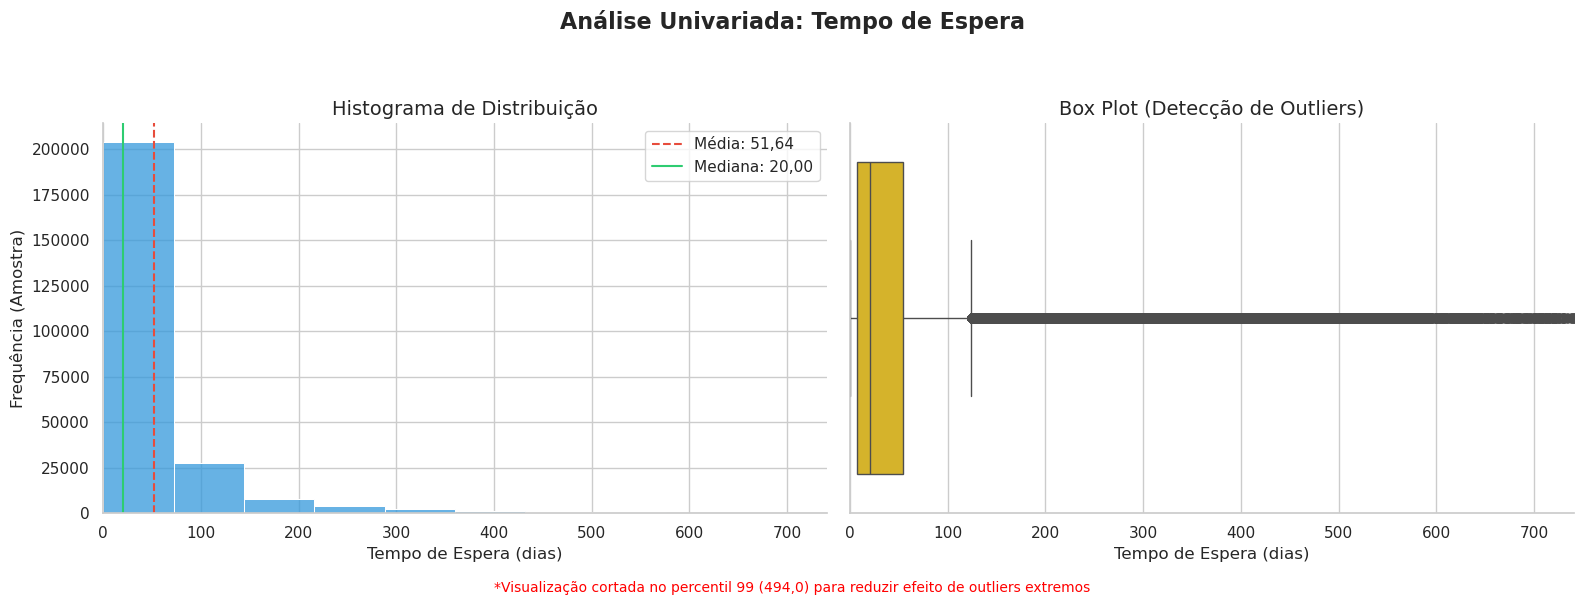

Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/02_univariate_numeric_distance_km.png


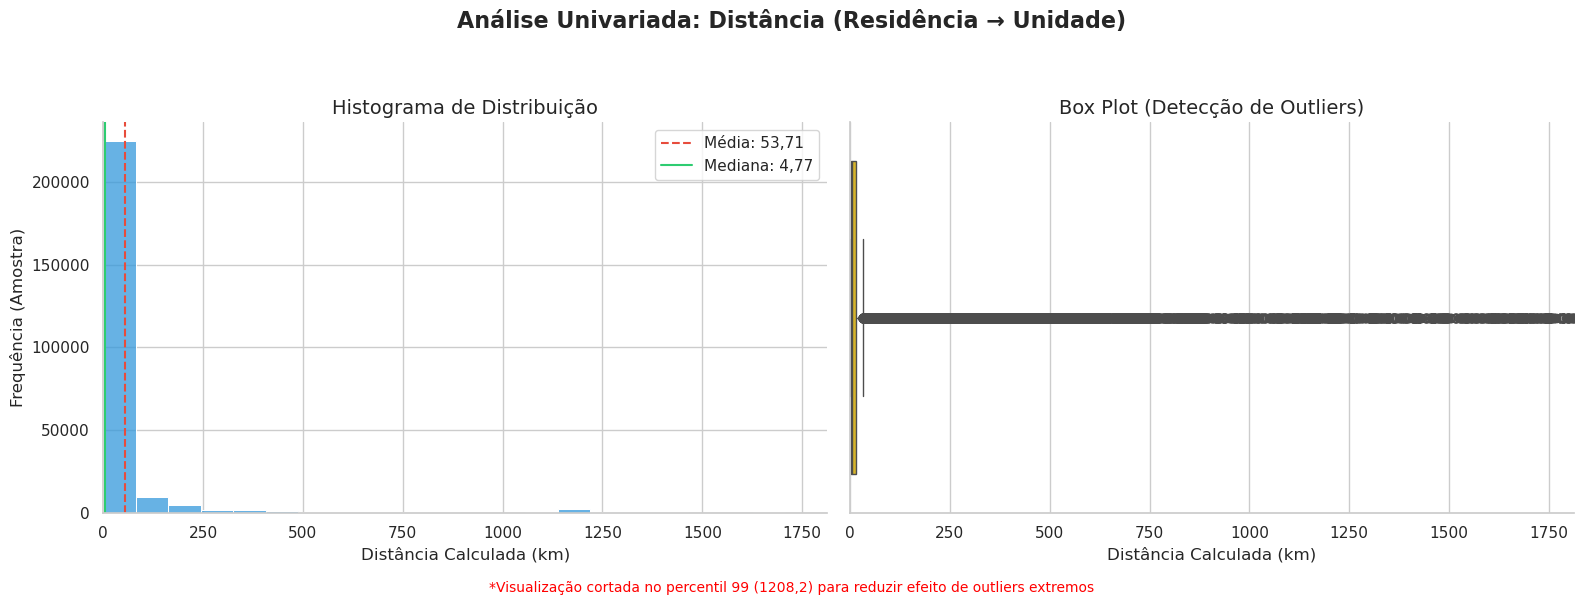

Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/02_univariate_numeric_contagem_faltas_anteriores.png


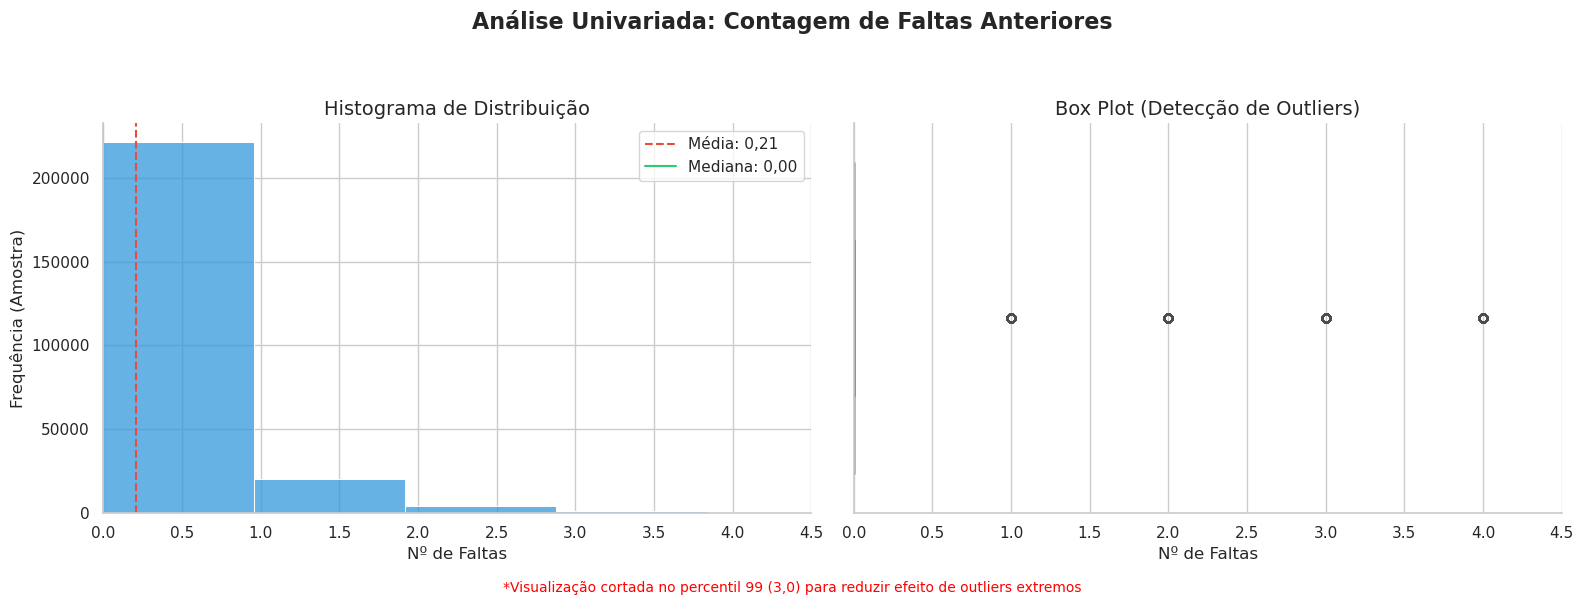

Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/02_univariate_numeric_total_consultas_anteriores.png


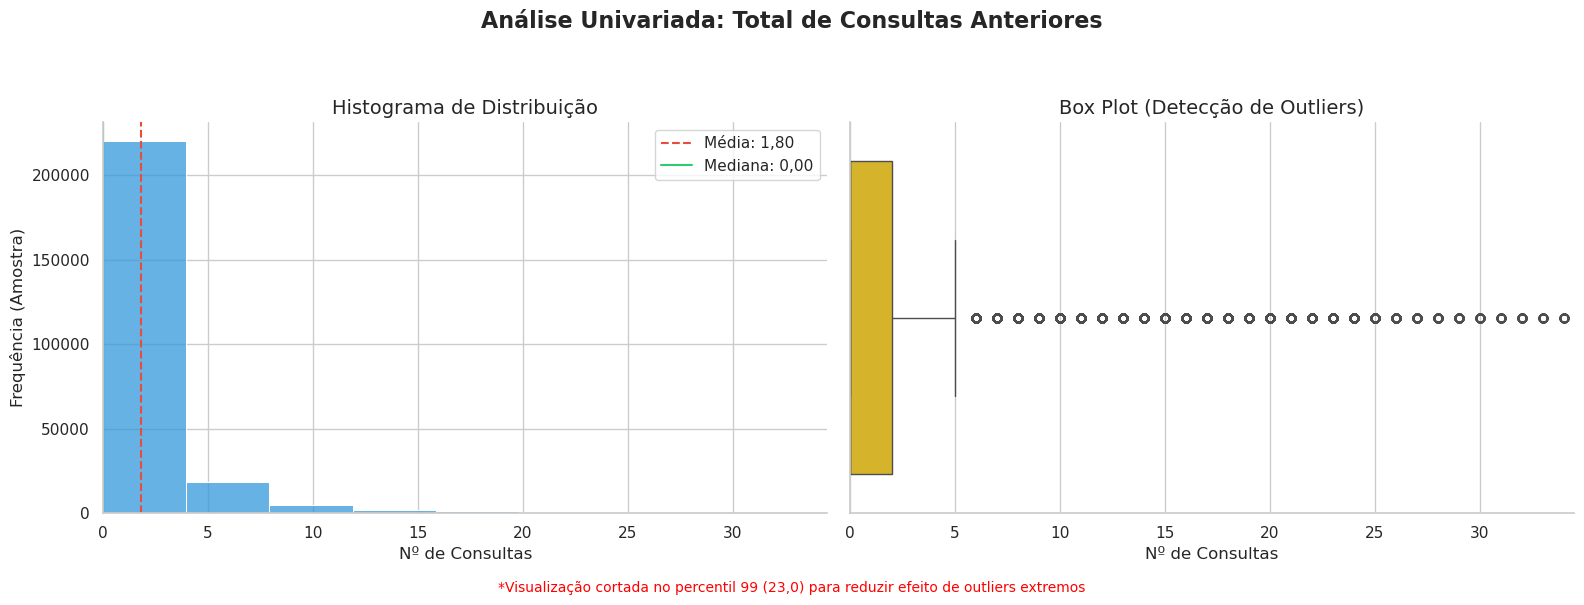

Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/02_univariate_numeric_percentual_faltas_anteriores.png


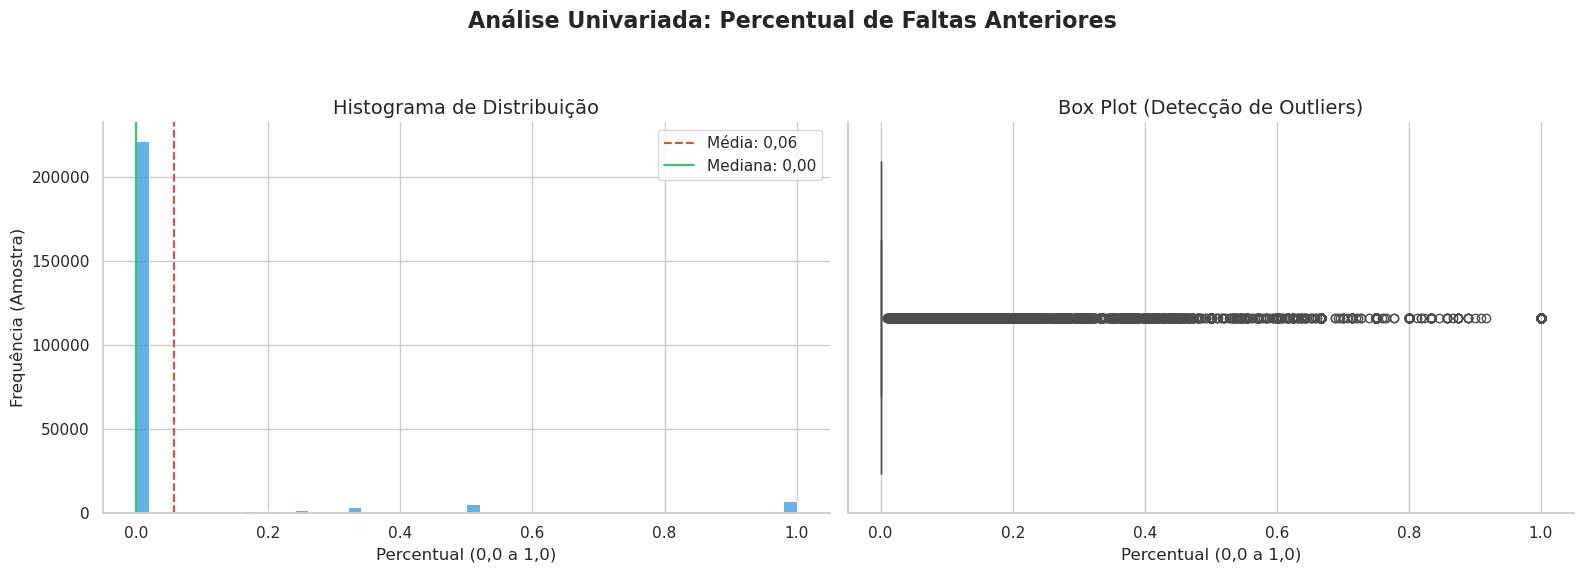

Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/02_univariate_numeric_cep_prefix_len_usuario.png


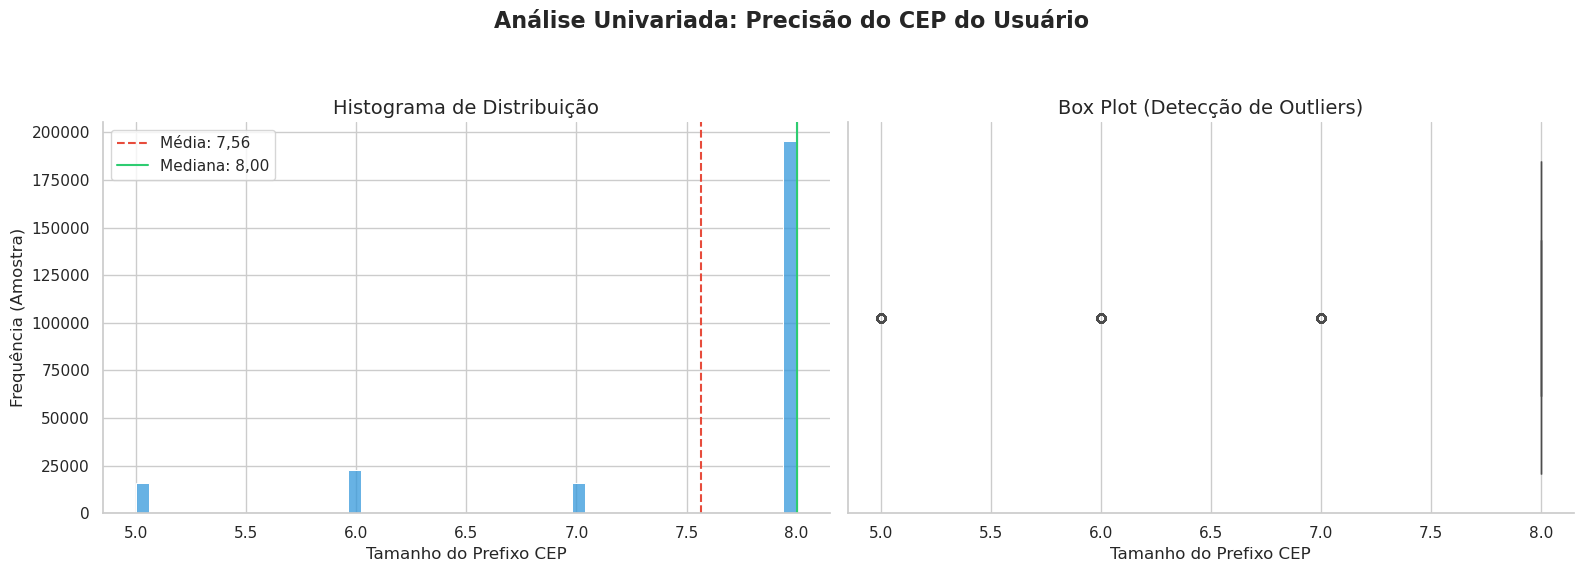

Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/02_univariate_numeric_cep_prefix_len_cnes.png


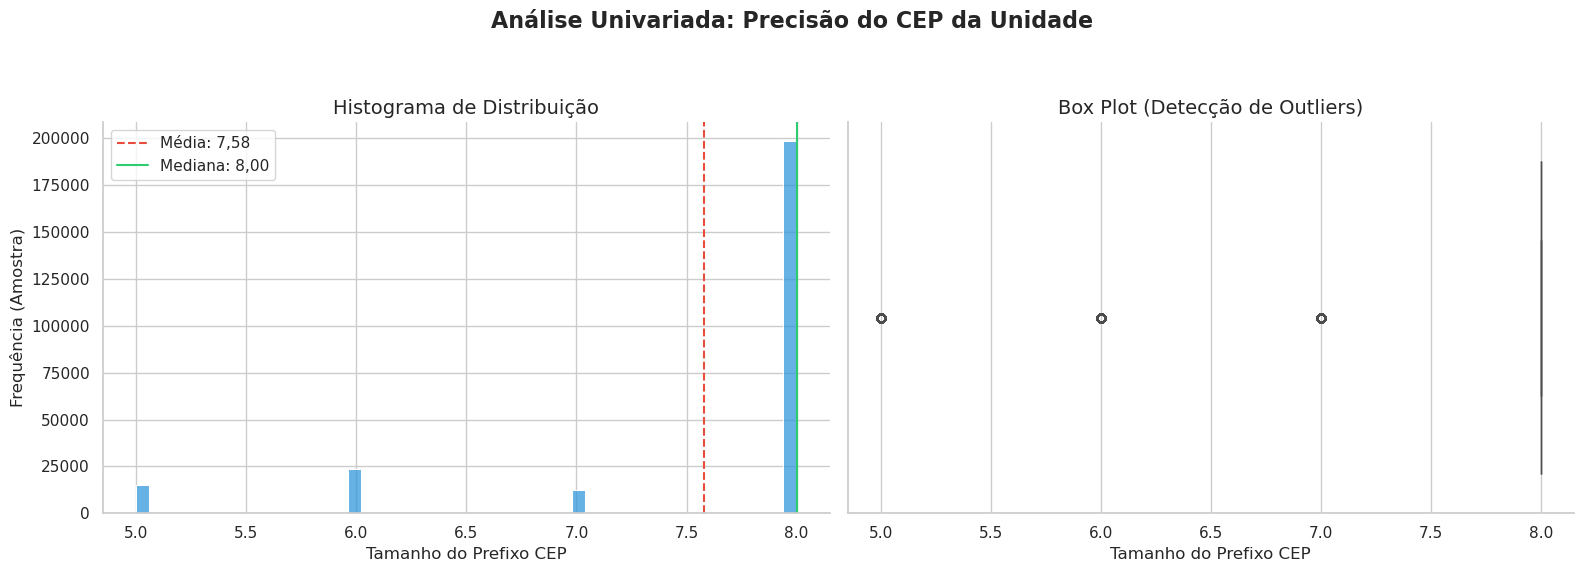

35837

In [ ]:
# ==============================================================================
# Univariate analysis: numerical features
# ==============================================================================
print("--- Descriptive Statistics for Numerical Features ---")

# --- 1. Define Numerical Features ---
base_numerical_features = [
    'idade_usuario',
    'tempo_espera',
    'distance_km',                 # distance to healthcare unit
    'contagem_faltas_anteriores',
    'total_consultas_anteriores',
    'percentual_faltas_anteriores',
    'cep_prefix_len_usuario',
    'cep_prefix_len_cnes',
]

numerical_features = available_columns(base_numerical_features)
print(f"Numerical features analyzed ({len(numerical_features)}): {numerical_features}")

# .describe() gives count, mean, std, min, 25%, 50%, 75%, max.
desc = df_2023[numerical_features].describe().T.copy()
desc['missing_count'] = df_2023[numerical_features].isna().sum()
desc['missing_pct'] = desc['missing_count'] / len(df_2023)
desc['skew'] = df_2023[numerical_features].skew(numeric_only=True)
desc['kurtosis'] = df_2023[numerical_features].kurtosis(numeric_only=True)

save_table(desc.reset_index().rename(columns={'index': 'feature'}), 'numerical_descriptive_statistics.csv')
display(format_numeric_table_br(desc, digits=3))
print("---------------------------------------------------------")

# --- 2. Plot Distributions ---
# Plotting the entire 7M+ rows with KDE/violin can be very slow, so figures use a
# stratified sample. The descriptive table above uses the full dataset.
df_plot_num = smart_sample(df_2023[[TARGET] + numerical_features], n=PLOT_SAMPLE_N, seed=SEED)
print(f"Plot sample size: {br_number(len(df_plot_num))}")

plot_labels_num = {
    'idade_usuario': {'title': 'Idade do Usuário', 'xlabel': 'Idade (anos)'},
    'tempo_espera': {'title': 'Tempo de Espera', 'xlabel': 'Tempo de Espera (dias)'},
    'distance_km': {'title': 'Distância (Residência → Unidade)', 'xlabel': 'Distância Calculada (km)'},
    'contagem_faltas_anteriores': {'title': 'Contagem de Faltas Anteriores', 'xlabel': 'Nº de Faltas'},
    'total_consultas_anteriores': {'title': 'Total de Consultas Anteriores', 'xlabel': 'Nº de Consultas'},
    'percentual_faltas_anteriores': {'title': 'Percentual de Faltas Anteriores', 'xlabel': 'Percentual (0,0 a 1,0)'},
    'cep_prefix_len_usuario': {'title': 'Precisão do CEP do Usuário', 'xlabel': 'Tamanho do Prefixo CEP'},
    'cep_prefix_len_cnes': {'title': 'Precisão do CEP da Unidade', 'xlabel': 'Tamanho do Prefixo CEP'},
}

for col in numerical_features:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    title_text = plot_labels_num.get(col, {}).get('title', col)
    xlabel_text = plot_labels_num.get(col, {}).get('xlabel', col)
    fig.suptitle(f'Análise Univariada: {title_text}', fontsize=16, fontweight='bold')

    # --- Plot 1: Histogram (Distribution Shape) ---
    sns.histplot(
        data=df_plot_num,
        x=col,
        kde=False,  # KDE on very large/skewed data may be slow and visually misleading.
        ax=axes[0],
        bins=50,
        color='#3498db',
        edgecolor='white'
    )
    axes[0].set_title('Histograma de Distribuição', fontsize=14)
    axes[0].set_xlabel(xlabel_text)
    axes[0].set_ylabel('Frequência (Amostra)')

    mean_val = df_2023[col].mean()
    median_val = df_2023[col].median()
    axes[0].axvline(mean_val, color='#e74c3c', linestyle='--', label=f'Média: {br_decimal(mean_val, 2)}')
    axes[0].axvline(median_val, color='#2ecc71', linestyle='-', label=f'Mediana: {br_decimal(median_val, 2)}')
    axes[0].legend()

    # --- Plot 2: Box Plot (Outliers) ---
    sns.boxplot(data=df_plot_num, x=col, ax=axes[1], color='#f1c40f')
    axes[1].set_title('Box Plot (Detecção de Outliers)', fontsize=14)
    axes[1].set_xlabel(xlabel_text)

    # --- Handling skewed data ---
    q99 = df_2023[col].quantile(0.99)
    max_val = df_2023[col].max()
    if pd.notnull(max_val) and pd.notnull(q99) and max_val > (3 * q99) and q99 > 0:
        axes[0].set_xlim(0, q99 * 1.5)
        axes[1].set_xlim(0, q99 * 1.5)
        fig.text(
            0.5, 0.01,
            f"*Visualização cortada no percentil 99 ({br_decimal(q99, 1)}) para reduzir efeito de outliers extremos",
            ha='center', fontsize=10, color='red'
        )

    sns.despine()
    plt.tight_layout(rect=[0, 0.03, 1, 0.93])
    save_current_figure(f'02_univariate_numeric_{col}')
    plt.show()

del df_plot_num
gc.collect()


--- VERIFICAÇÃO PÓS-CORREÇÃO: PODER PREDITIVO DAS FEATURES DERIVADAS ---
Features checked: ['distance_km', 'percentual_faltas_anteriores', 'contagem_faltas_anteriores', 'total_consultas_anteriores', 'cep_prefix_len_usuario', 'cep_prefix_len_cnes']

Medianas por Status (Compareceu vs Faltou):
Saved table: ../reports/descriptive_analysis_refreshed_v3/tables/derived_features_medians_by_target.csv


,distance_km,percentual_faltas_anteriores,contagem_faltas_anteriores,total_consultas_anteriores,cep_prefix_len_usuario,cep_prefix_len_cnes
ausencia,,,,,,
Compareceu (0),"4,598","0,000","0,000","0,000","8,000","8,000"
Faltou (1),"5,794","0,000","0,000","0,000","8,000","8,000"



Verificando Correlações Lineares com o Alvo:
Saved table: ../reports/descriptive_analysis_refreshed_v3/tables/derived_features_correlation_matrix.csv


,ausencia,distance_km,percentual_faltas_anteriores,contagem_faltas_anteriores,total_consultas_anteriores,cep_prefix_len_usuario,cep_prefix_len_cnes
ausencia,"1,000","0,016","0,107","0,074","-0,014","-0,014","-0,018"
distance_km,"0,016","1,000","-0,003","-0,013","-0,024","-0,068","-0,221"
percentual_faltas_anteriores,"0,107","-0,003","1,000","0,432","0,099","-0,025","-0,020"
contagem_faltas_anteriores,"0,074","-0,013","0,432","1,000","0,584","-0,022","-0,036"
total_consultas_anteriores,"-0,014","-0,024","0,099","0,584","1,000","-0,007","-0,054"
cep_prefix_len_usuario,"-0,014","-0,068","-0,025","-0,022","-0,007","1,000","0,276"
cep_prefix_len_cnes,"-0,018","-0,221","-0,020","-0,036","-0,054","0,276","1,000"


Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/03_derived_features_correlation_heatmap.png


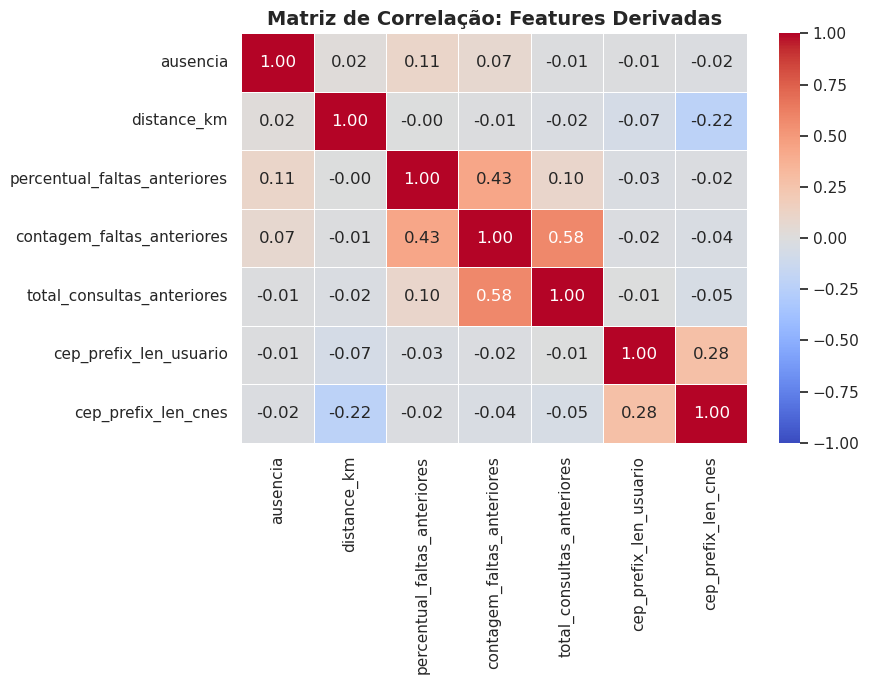

Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/04_derived_feature_by_status_distance_km.png


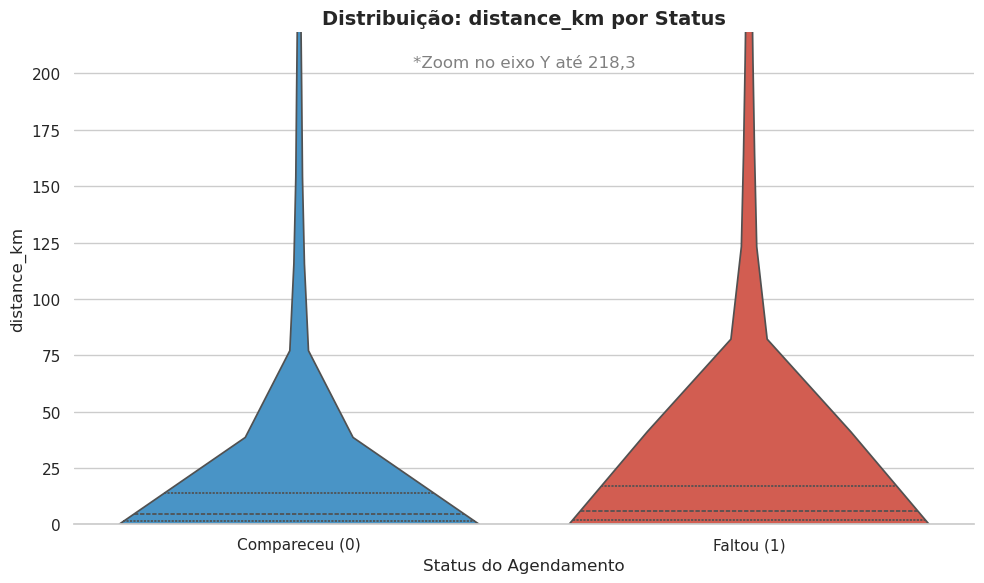

Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/04_derived_feature_by_status_percentual_faltas_anteriores.png


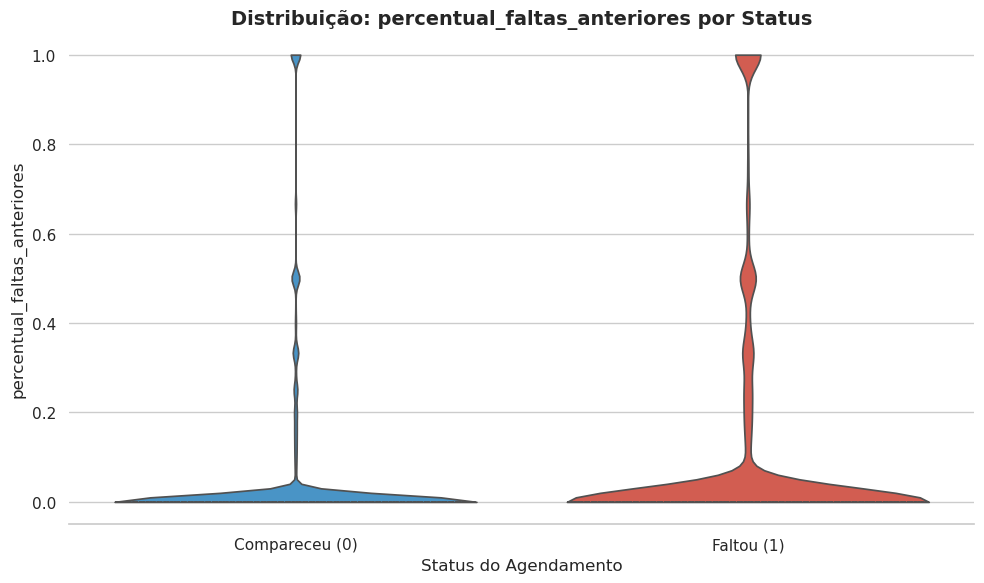

Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/04_derived_feature_by_status_contagem_faltas_anteriores.png


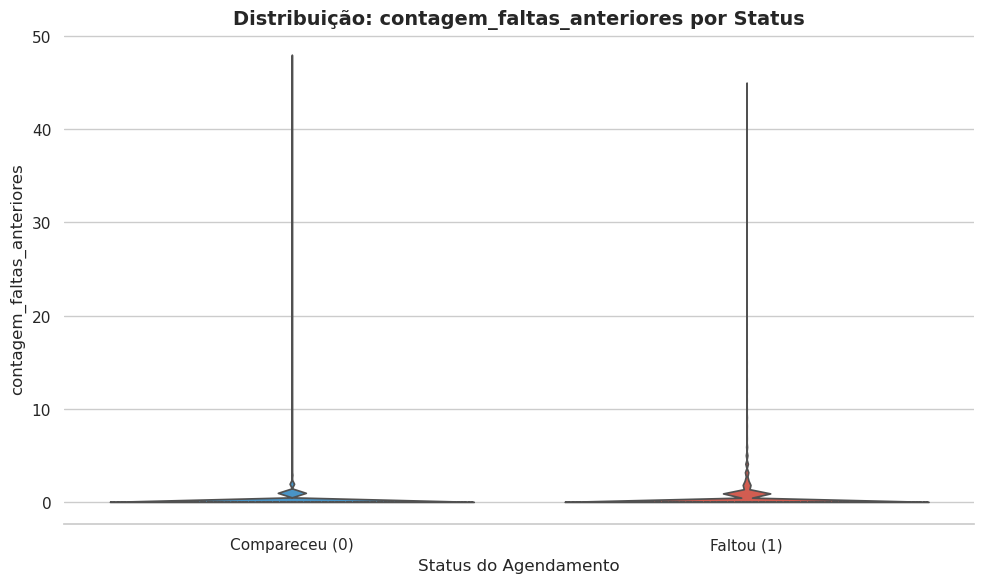

Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/04_derived_feature_by_status_total_consultas_anteriores.png


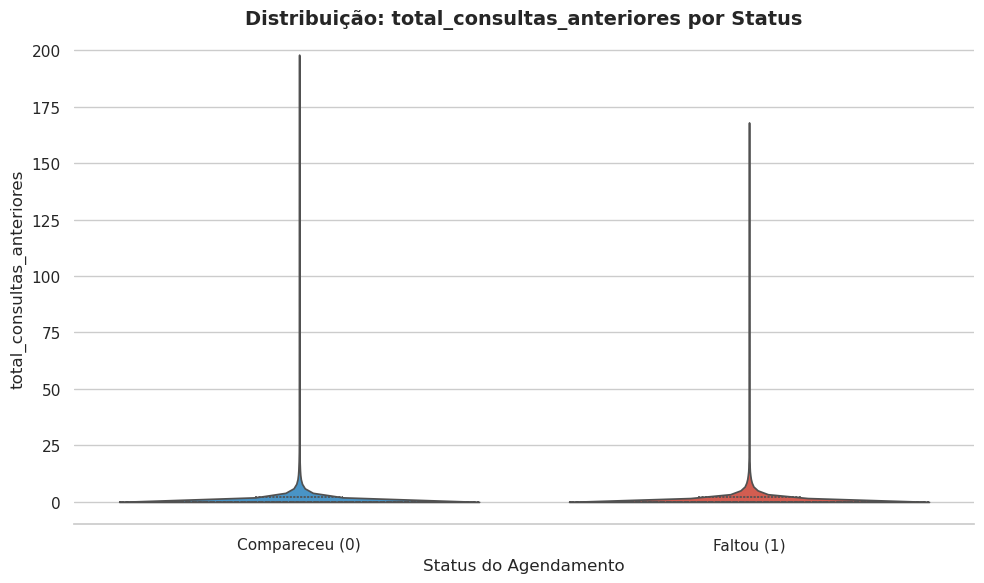

Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/04_derived_feature_by_status_cep_prefix_len_usuario.png


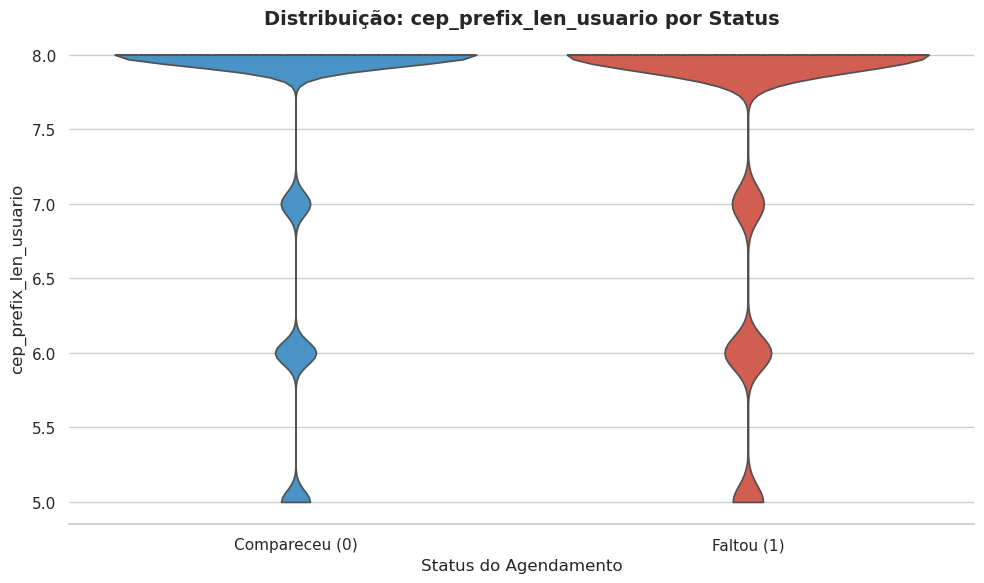

Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/04_derived_feature_by_status_cep_prefix_len_cnes.png


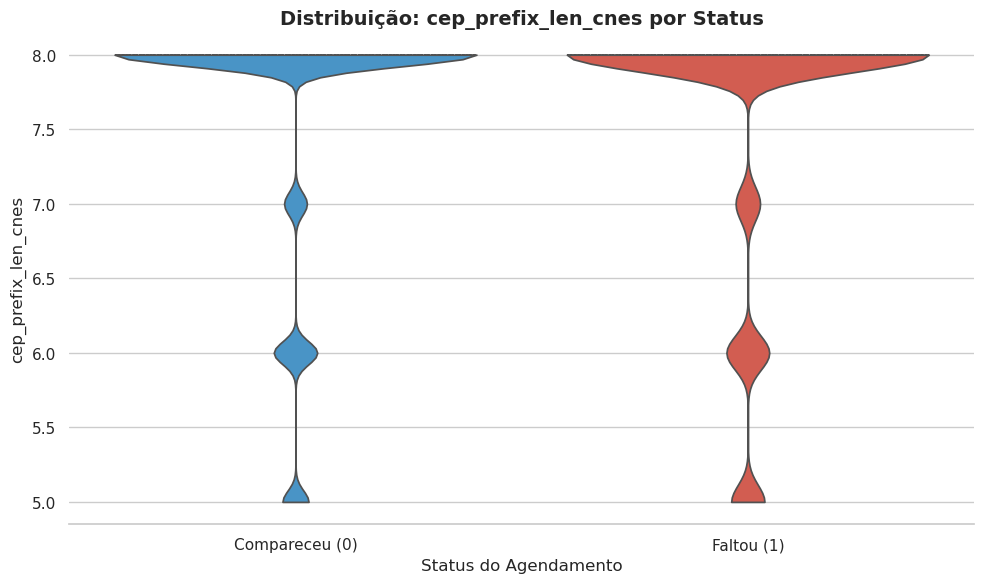

40850

In [ ]:
# ==============================================================================
# Post-cleaning diagnostic features vs target
# ==============================================================================
print("--- VERIFICAÇÃO PÓS-CORREÇÃO: PODER PREDITIVO DAS FEATURES DERIVADAS ---")

# This cell checks whether important
# derived features differ between attendance and no-show groups.
verify_features = available_columns([
    'distance_km',
    'percentual_faltas_anteriores',
    'contagem_faltas_anteriores',
    'total_consultas_anteriores',
    'cep_prefix_len_usuario',
    'cep_prefix_len_cnes',
])

print(f"Features checked: {verify_features}")

# --- 1. Median comparison ---
print("\nMedianas por Status (Compareceu vs Faltou):")
medians = df_2023.groupby(TARGET, observed=True)[verify_features].median()
medians.index = medians.index.map({0: 'Compareceu (0)', 1: 'Faltou (1)'})
save_table(medians.reset_index().rename(columns={TARGET: 'status'}), 'derived_features_medians_by_target.csv')
display(format_numeric_table_br(medians, digits=3))

# --- 2. Correlation matrix with target ---
print("\nVerificando Correlações Lineares com o Alvo:")
corr_cols = [TARGET] + verify_features
corr_matrix = df_2023[corr_cols].apply(pd.to_numeric, errors='coerce').corr(method='pearson')
save_table(corr_matrix.reset_index().rename(columns={'index': 'feature'}), 'derived_features_correlation_matrix.csv')
display(format_numeric_table_br(corr_matrix, digits=3))

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=.5
)
plt.title('Matriz de Correlação: Features Derivadas', fontsize=14, fontweight='bold')
plt.tight_layout()
save_current_figure('03_derived_features_correlation_heatmap')
plt.show()

# --- 3. Violin plots using sample ---
df_plot = smart_sample(df_2023[[TARGET] + verify_features], n=PLOT_SAMPLE_N, seed=SEED)
df_plot['status'] = df_plot[TARGET].map({0: 'Compareceu (0)', 1: 'Faltou (1)'})

for col in verify_features:
    plt.figure(figsize=(10, 6))
    ax = sns.violinplot(
        data=df_plot,
        x='status',
        y=col,
        order=['Compareceu (0)', 'Faltou (1)'],
        palette=status_palette,
        inner='quartile',
        hue='status',
        legend=False,
        cut=0,
    )
    ax.set_title(f'Distribuição: {col} por Status', fontsize=14, fontweight='bold')
    ax.set_xlabel('Status do Agendamento')
    ax.set_ylabel(col)

    if col in ['distance_km', 'tempo_espera']:
        limit = df_2023[col].quantile(0.95)
        if pd.notnull(limit) and limit > 0:
            ax.set_ylim(0, limit)
            ax.text(0.5, 0.93, f"*Zoom no eixo Y até {br_decimal(limit, 1)}", transform=ax.transAxes, ha='center', color='gray')

    sns.despine(left=True)
    plt.tight_layout()
    save_current_figure(f'04_derived_feature_by_status_{col}')
    plt.show()

del df_plot
gc.collect()


--- Análise Univariada: Features Categóricas ---
Categorical features analyzed (10): ['sexo_usuario', 'prioridade', 'raca_cor_usuario', 'tip_marcacao', 'deslocamento', 'cbo_espec', 'uf_usuario', 'uf_cnes', 'regiao_usuario', 'regiao_cnes']

--- Feature: sexo_usuario ---
Número de categorias únicas: 3


,sexo_usuario,count,percentage,feature,percentage_br
0,f,4459936,0.626942,sexo_usuario,"62,69%"
1,m,2653861,0.373058,sexo_usuario,"37,31%"
2,i,1,0.0,sexo_usuario,"0,00%"


Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/05_univariate_categorical_sexo_usuario.png


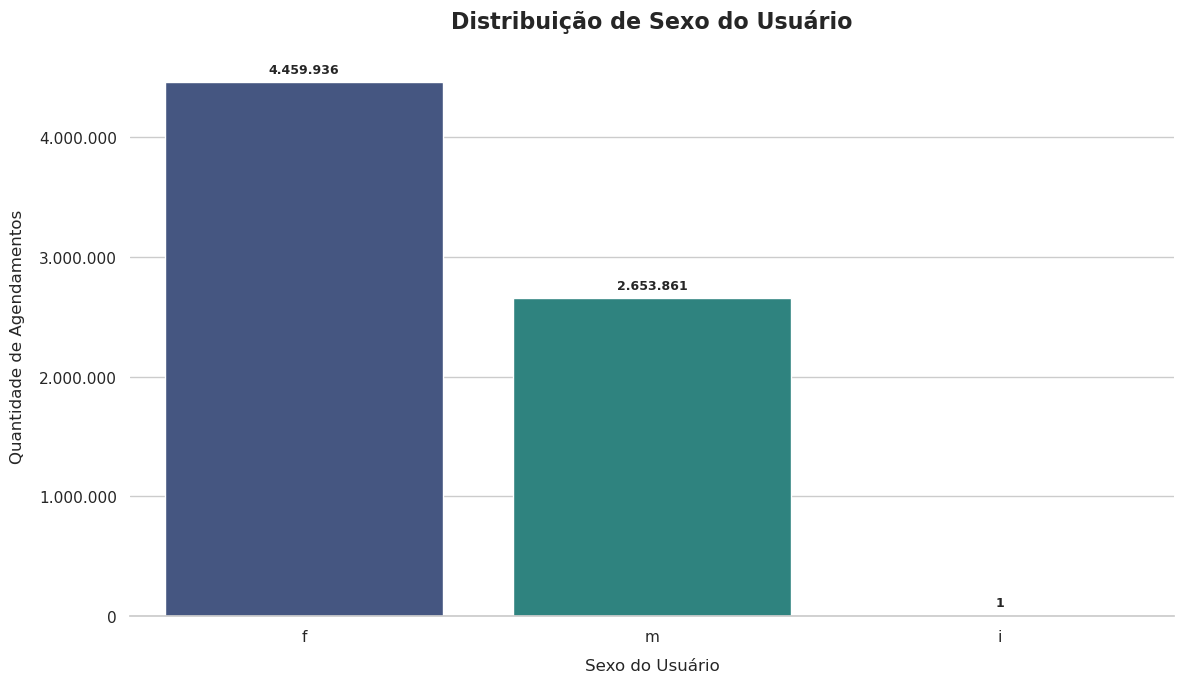


--- Feature: prioridade ---
Número de categorias únicas: 4


,prioridade,count,percentage,feature,percentage_br
0,3,5451672,0.766352,prioridade,"76,64%"
1,1,754145,0.106012,prioridade,"10,60%"
2,2,576549,0.081047,prioridade,"8,10%"
3,0,331432,0.04659,prioridade,"4,66%"


Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/05_univariate_categorical_prioridade.png


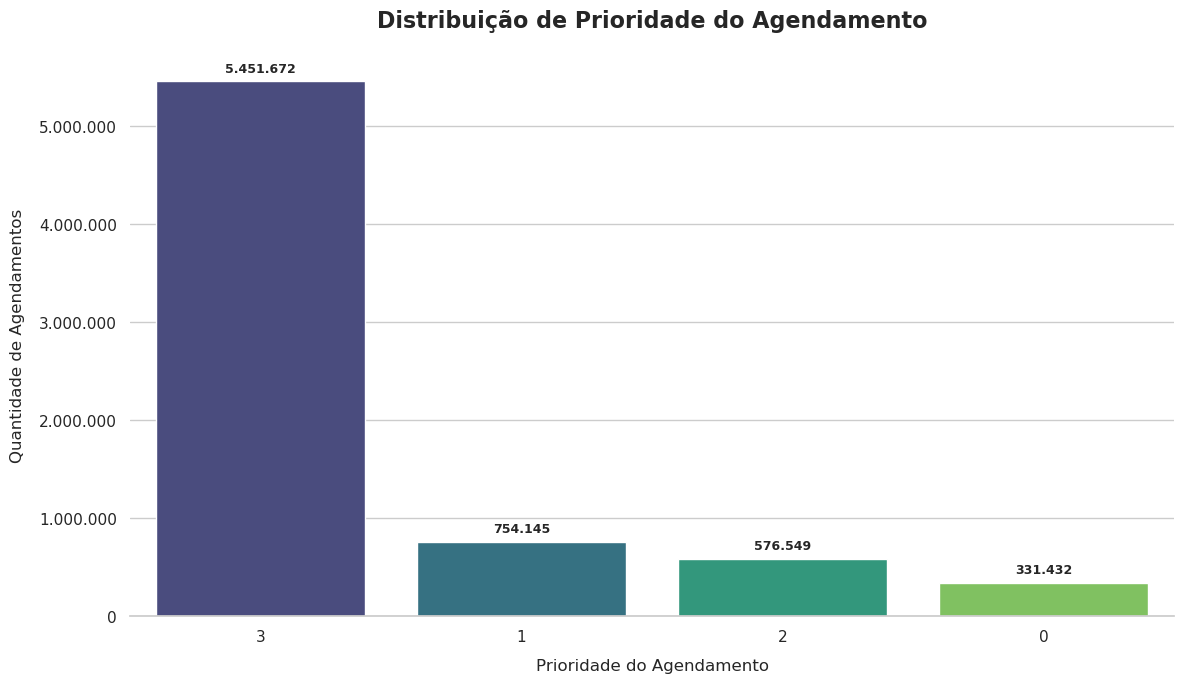


--- Feature: raca_cor_usuario ---
Número de categorias únicas: 6


,raca_cor_usuario,count,percentage,feature,percentage_br
0,01,2888069,0.405981,raca_cor_usuario,"40,60%"
1,03,2624663,0.368954,raca_cor_usuario,"36,90%"
2,04,858851,0.12073,raca_cor_usuario,"12,07%"
3,02,437639,0.06152,raca_cor_usuario,"6,15%"
4,99,288163,0.040508,raca_cor_usuario,"4,05%"
5,05,16413,0.002307,raca_cor_usuario,"0,23%"


Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/05_univariate_categorical_raca_cor_usuario.png


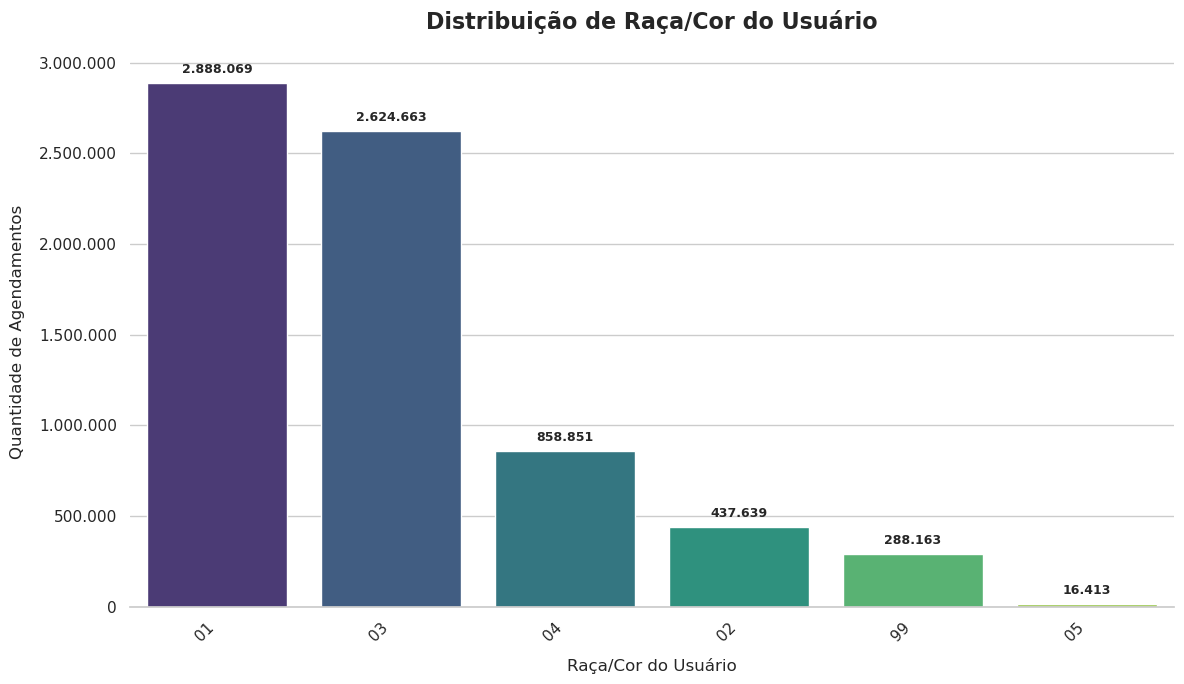


--- Feature: tip_marcacao ---
Número de categorias únicas: 3


,tip_marcacao,count,percentage,feature,percentage_br
0,0,3224941,0.453336,tip_marcacao,"45,33%"
1,2,2116132,0.297469,tip_marcacao,"29,75%"
2,1,1772725,0.249195,tip_marcacao,"24,92%"


Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/05_univariate_categorical_tip_marcacao.png


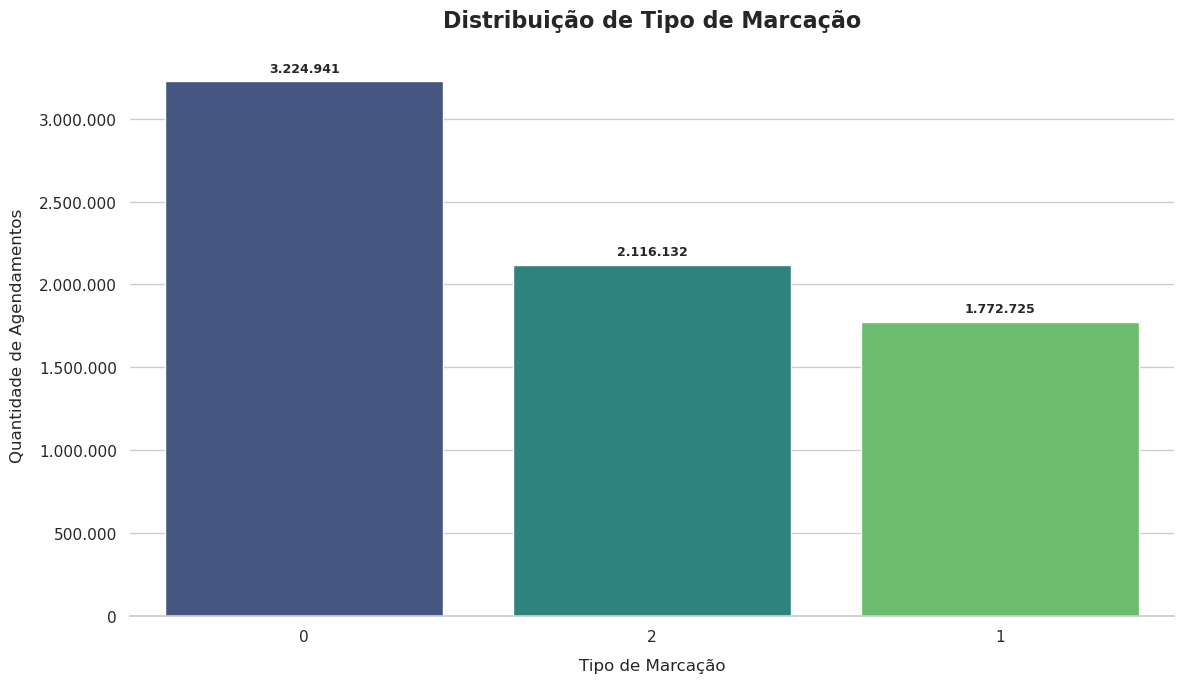


--- Feature: deslocamento ---
Número de categorias únicas: 3


,deslocamento,count,percentage,feature,percentage_br
0,0,5759603,0.809638,deslocamento,"80,96%"
1,1,1270888,0.178651,deslocamento,"17,87%"
2,2,83307,0.011711,deslocamento,"1,17%"


Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/05_univariate_categorical_deslocamento.png


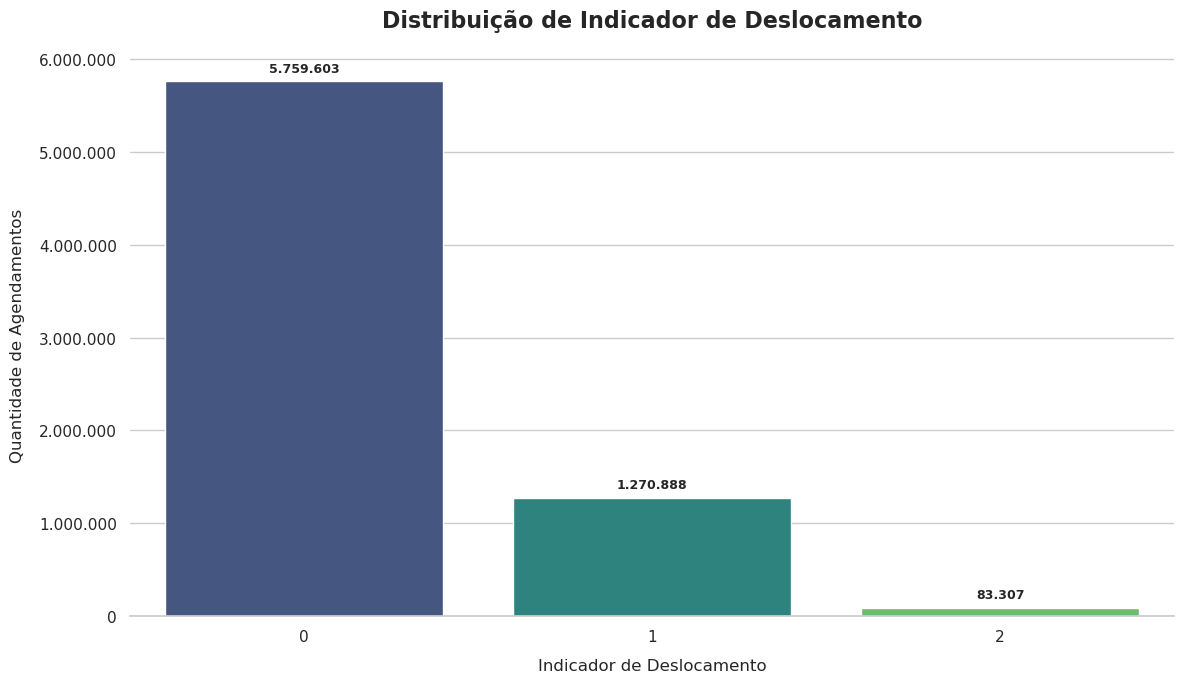


--- Feature: cbo_espec ---
Número de categorias únicas: 76


,cbo_espec,count,percentage,feature,percentage_br
0,225265,762526,0.10719,cbo_espec,"10,72%"
1,225270,695363,0.097748,cbo_espec,"9,77%"
2,225250,528967,0.074358,cbo_espec,"7,44%"
3,225120,461418,0.064862,cbo_espec,"6,49%"
4,225225,290885,0.04089,cbo_espec,"4,09%"
5,225112,290329,0.040812,cbo_espec,"4,08%"
6,225135,281452,0.039564,cbo_espec,"3,96%"
7,223208,271582,0.038177,cbo_espec,"3,82%"
8,223605,269459,0.037878,cbo_espec,"3,79%"
9,225133,251831,0.0354,cbo_espec,"3,54%"


Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/05_univariate_categorical_cbo_espec.png


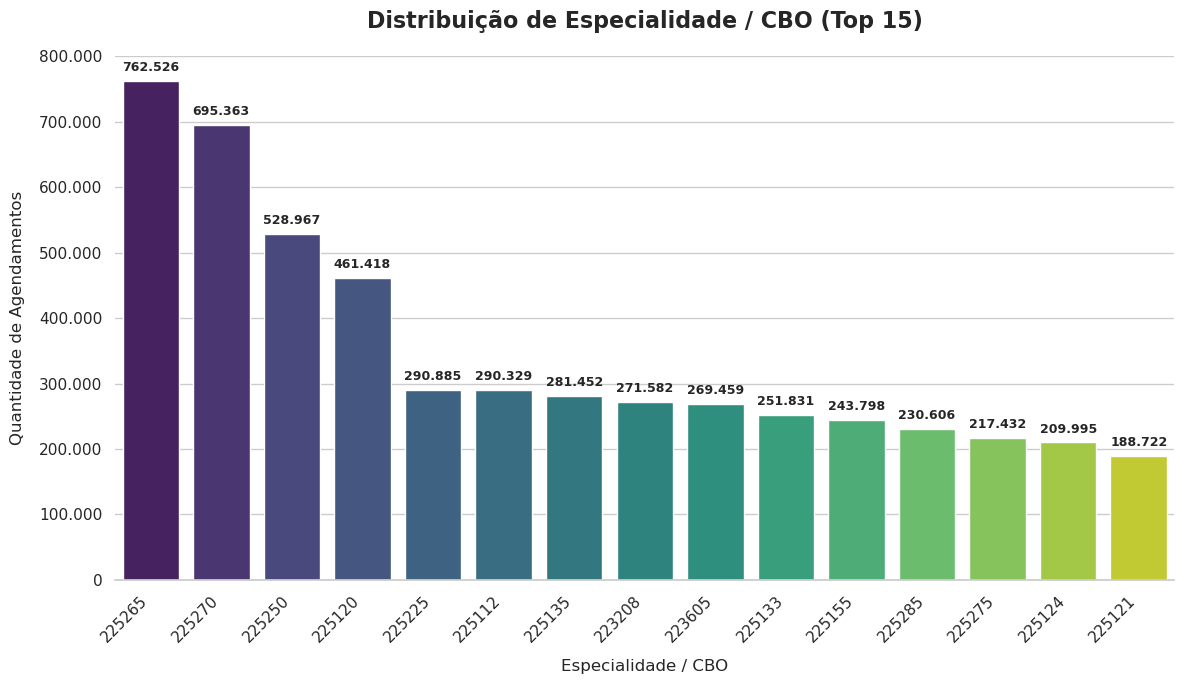


--- Feature: uf_usuario ---
Número de categorias únicas: 26


,uf_usuario,count,percentage,feature,percentage_br
0,sc,1419920,0.199601,uf_usuario,"19,96%"
1,rj,1275850,0.179349,uf_usuario,"17,93%"
2,ma,748188,0.105174,uf_usuario,"10,52%"
3,ms,409678,0.057589,uf_usuario,"5,76%"
4,am,330979,0.046526,uf_usuario,"4,65%"
5,mt,308608,0.043382,uf_usuario,"4,34%"
6,go,302022,0.042456,uf_usuario,"4,25%"
7,mg,275767,0.038765,uf_usuario,"3,88%"
8,pb,260517,0.036621,uf_usuario,"3,66%"
9,pa,239234,0.03363,uf_usuario,"3,36%"


Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/05_univariate_categorical_uf_usuario.png


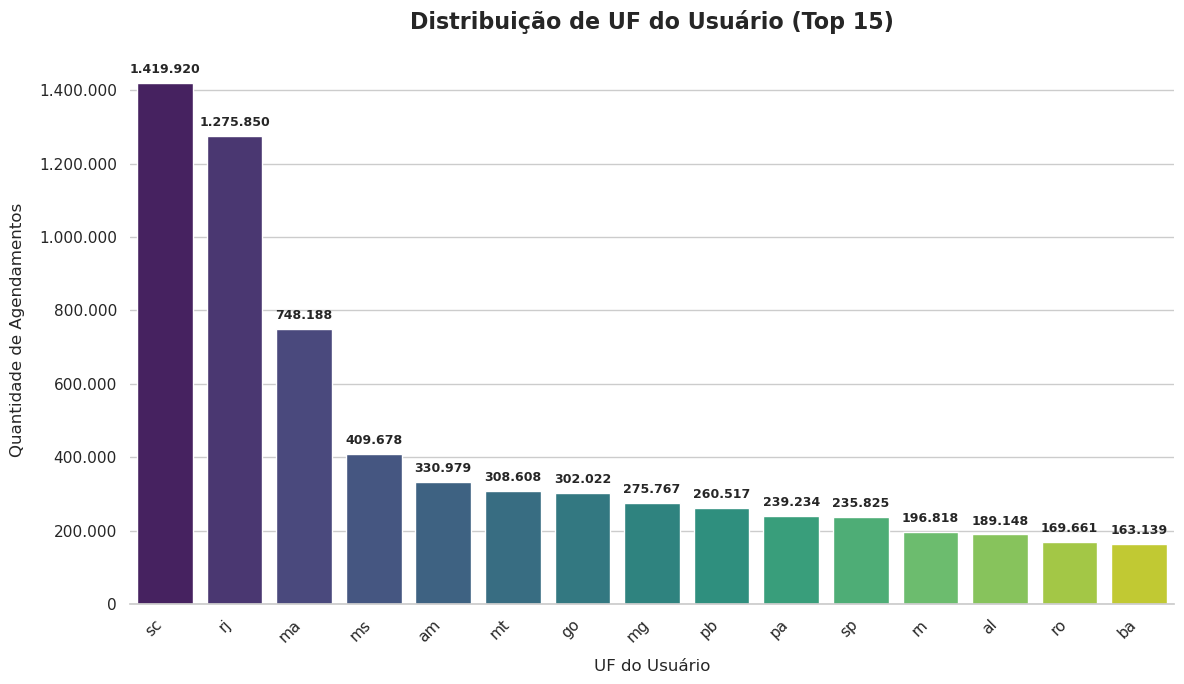


--- Feature: uf_cnes ---
Número de categorias únicas: 24


,uf_cnes,count,percentage,feature,percentage_br
0,sc,1435078,0.201732,uf_cnes,"20,17%"
1,rj,1281692,0.18017,uf_cnes,"18,02%"
2,ma,758063,0.106562,uf_cnes,"10,66%"
3,ms,407936,0.057344,uf_cnes,"5,73%"
4,am,404815,0.056906,uf_cnes,"5,69%"
5,mt,315353,0.04433,uf_cnes,"4,43%"
6,go,297026,0.041754,uf_cnes,"4,18%"
7,mg,271418,0.038154,uf_cnes,"3,82%"
8,pb,260584,0.036631,uf_cnes,"3,66%"
9,pa,234128,0.032912,uf_cnes,"3,29%"


Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/05_univariate_categorical_uf_cnes.png


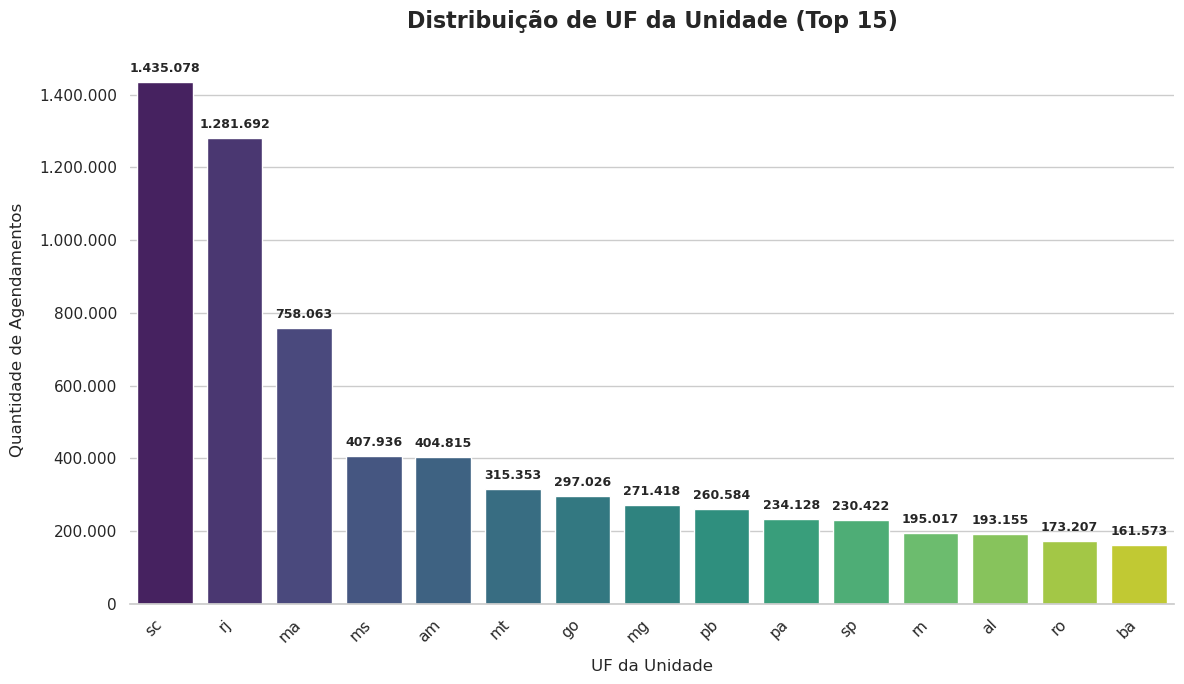


--- Feature: regiao_usuario ---
Número de categorias únicas: 5


,regiao_usuario,count,percentage,feature,percentage_br
0,sudeste,1864500,0.262096,regiao_usuario,"26,21%"
1,nordeste,1675203,0.235486,regiao_usuario,"23,55%"
2,sul,1543859,0.217023,regiao_usuario,"21,70%"
3,centro-oeste,1020308,0.143427,regiao_usuario,"14,34%"
4,norte,1009928,0.141967,regiao_usuario,"14,20%"


Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/05_univariate_categorical_regiao_usuario.png


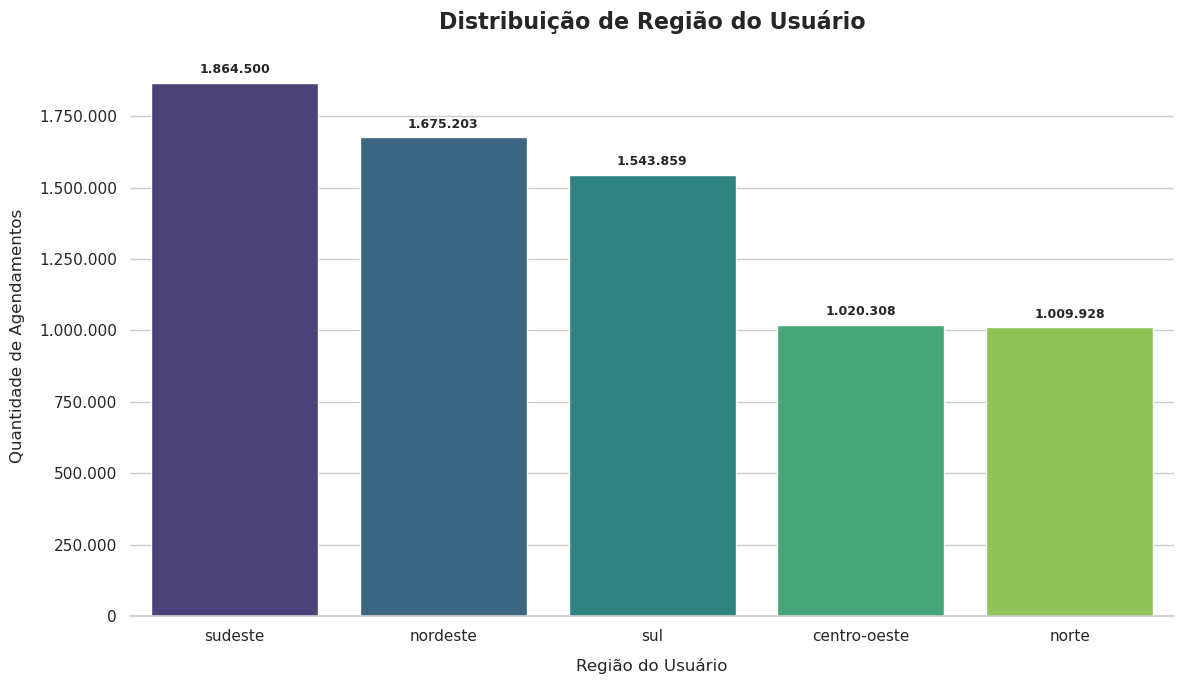


--- Feature: regiao_cnes ---
Número de categorias únicas: 5


,regiao_cnes,count,percentage,feature,percentage_br
0,sudeste,1859939,0.261455,regiao_cnes,"26,15%"
1,nordeste,1680858,0.236281,regiao_cnes,"23,63%"
2,sul,1543343,0.216951,regiao_cnes,"21,70%"
3,centro-oeste,1020315,0.143428,regiao_cnes,"14,34%"
4,norte,1009343,0.141885,regiao_cnes,"14,19%"


Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/05_univariate_categorical_regiao_cnes.png


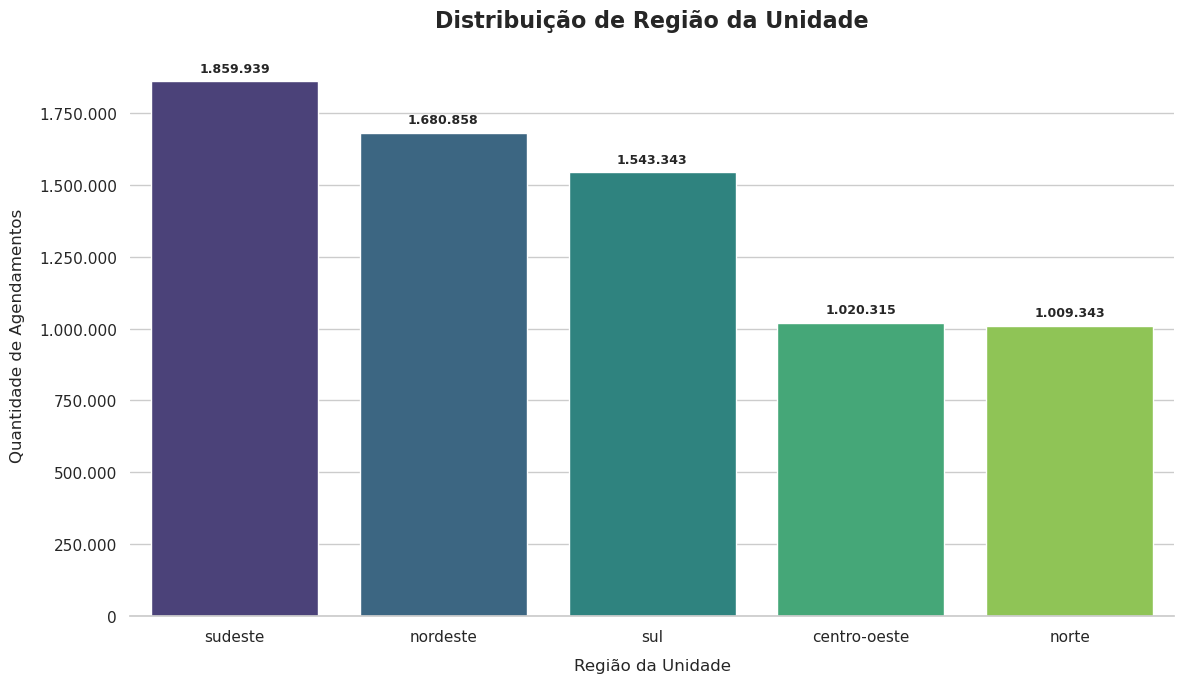

Saved table: ../reports/descriptive_analysis_refreshed_v3/tables/categorical_univariate_distributions.csv


PosixPath('../reports/descriptive_analysis_refreshed_v3/tables/categorical_univariate_distributions.csv')

In [ ]:
# ==============================================================================
# Univariate analysis: categorical features
# ==============================================================================
print("--- Análise Univariada: Features Categóricas ---")

# --- 1. Define Categorical Features ---
categorical_features = available_columns([
    'sexo_usuario',
    'prioridade',
    'raca_cor_usuario',
    'tip_marcacao',
    'deslocamento',
    'cbo_espec',
    'uf_usuario',
    'uf_cnes',
    'regiao_usuario',
    'regiao_cnes',
])

plot_labels_cat = {
    'sexo_usuario': 'Sexo do Usuário',
    'prioridade': 'Prioridade do Agendamento',
    'raca_cor_usuario': 'Raça/Cor do Usuário',
    'tip_marcacao': 'Tipo de Marcação',
    'deslocamento': 'Indicador de Deslocamento',
    'cbo_espec': 'Especialidade / CBO',
    'uf_usuario': 'UF do Usuário',
    'uf_cnes': 'UF da Unidade',
    'regiao_usuario': 'Região do Usuário',
    'regiao_cnes': 'Região da Unidade',
}

print(f"Categorical features analyzed ({len(categorical_features)}): {categorical_features}")

all_cat_rows = []
for col in categorical_features:
    print(f"\n--- Feature: {col} ---")
    value_table = (
        df_2023[col]
        .astype('string')
        .value_counts(dropna=False)
        .rename_axis(col)
        .reset_index(name='count')
    )
    value_table['percentage'] = value_table['count'] / len(df_2023)
    value_table['feature'] = col
    all_cat_rows.append(value_table[['feature', col, 'count', 'percentage']].rename(columns={col: 'category'}))

    print(f"Número de categorias únicas: {df_2023[col].nunique(dropna=False)}")
    display(value_table.head(15).assign(percentage_br=lambda x: x['percentage'].map(br_percent)))

    # --- Handling High Cardinality ---
    top_n = MAX_CATEGORIES_TO_PLOT
    plot_table = value_table.head(top_n).copy()
    title_suffix = f" (Top {top_n})" if len(value_table) > top_n else ""

    plt.figure(figsize=(12, 7))
    ax = sns.barplot(
        data=plot_table,
        x=col,
        y='count',
        order=plot_table[col].tolist(),
        palette='viridis',
        errorbar=None
    )
    ax.set_title(f'Distribuição de {plot_labels_cat.get(col, col)}{title_suffix}', fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel(plot_labels_cat.get(col, col), fontsize=12, labelpad=10)
    ax.set_ylabel('Quantidade de Agendamentos', fontsize=12, labelpad=10)
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: br_number(x)))

    for p in ax.patches:
        height = p.get_height()
        if pd.notnull(height) and height > 0:
            ax.annotate(
                f'{br_number(height)}',
                (p.get_x() + p.get_width()/2, height),
                ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points',
                fontsize=9, fontweight='bold'
            )

    if len(plot_table) > 5:
        plt.xticks(rotation=45, ha='right')
    sns.despine(left=True)
    plt.tight_layout()
    save_current_figure(f'05_univariate_categorical_{col}')
    plt.show()

categorical_distribution_table = pd.concat(all_cat_rows, ignore_index=True) if all_cat_rows else pd.DataFrame()
save_table(categorical_distribution_table, 'categorical_univariate_distributions.csv')


--- Análise Univariada Temporal ---
Saved table: ../reports/descriptive_analysis_refreshed_v3/tables/temporal_univariate_month_counts.csv
Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/06_temporal_univariate_month_counts.png


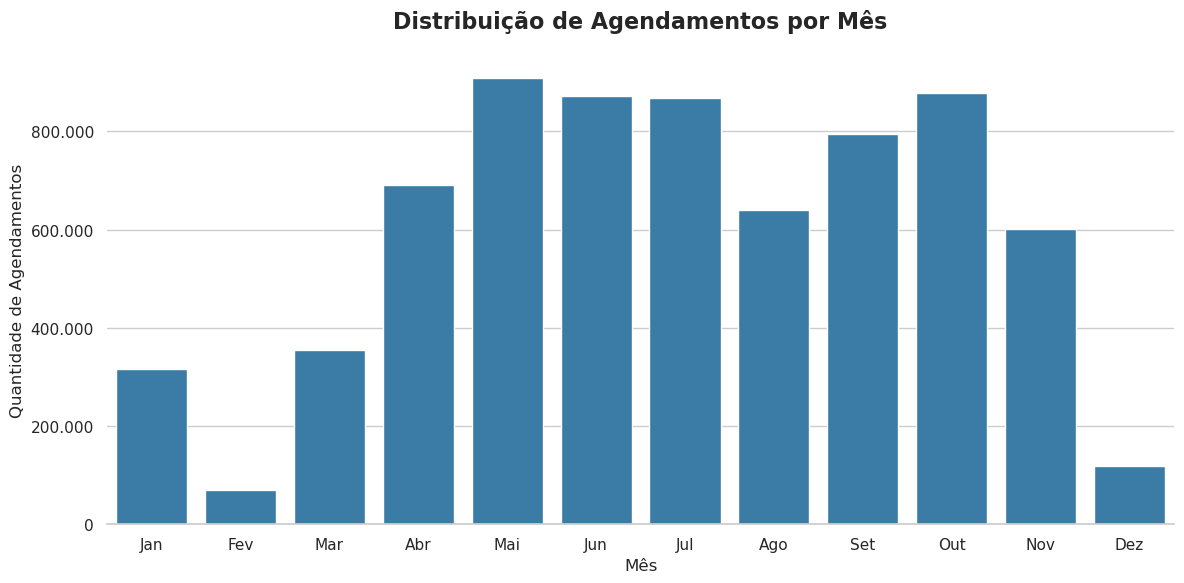

Saved table: ../reports/descriptive_analysis_refreshed_v3/tables/temporal_univariate_day_of_week_counts.csv
Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/07_temporal_univariate_day_of_week_counts.png


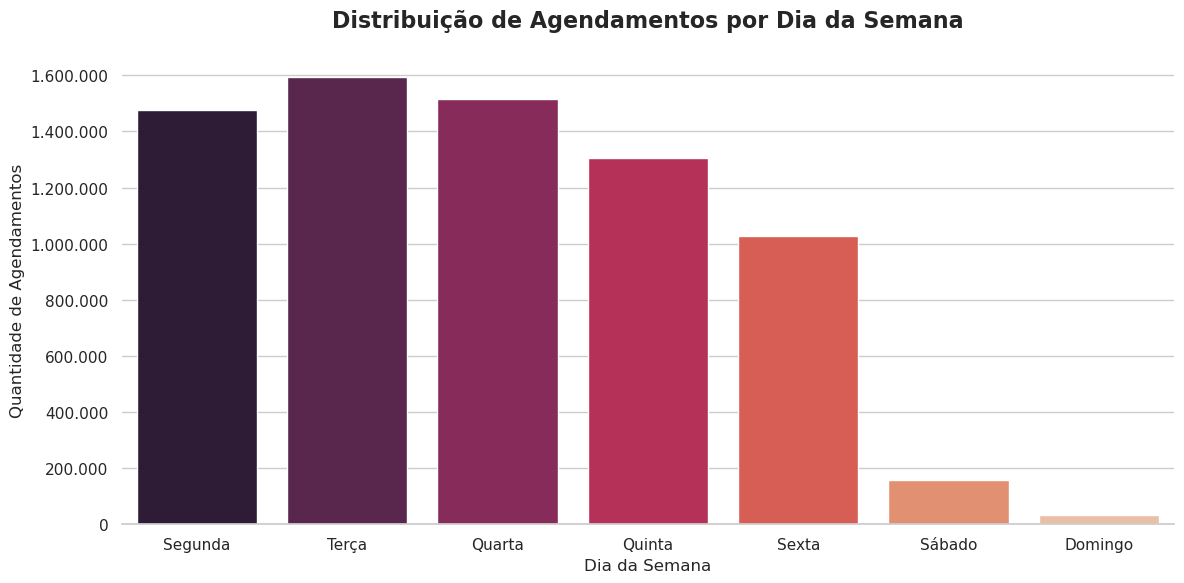

Saved table: ../reports/descriptive_analysis_refreshed_v3/tables/temporal_univariate_day_of_month_counts.csv
Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/08_temporal_univariate_day_of_month_counts.png


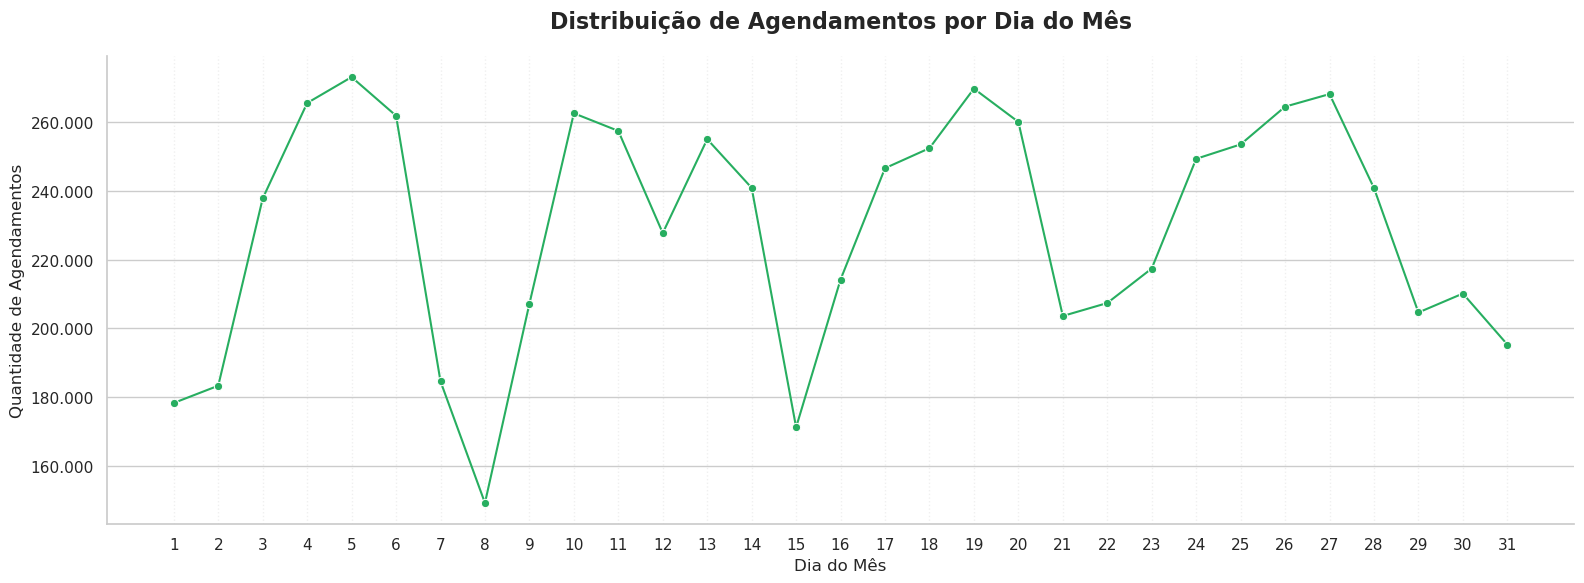

28052

In [ ]:
# ==============================================================================
# Univariate temporal analysis
# ==============================================================================
print("--- Análise Univariada Temporal ---")

require_columns(['mes_consulta', 'dia_consulta'], context='temporal univariate analysis')

# Ensure 'dia_da_semana' exists.
if 'dia_da_semana' not in df_2023.columns:
    require_columns(['dta_atend'], context='create dia_da_semana')
    df_2023['dia_da_semana'] = df_2023['dta_atend'].dt.dayofweek

mapa_mes = {
    1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr', 5: 'Mai', 6: 'Jun',
    7: 'Jul', 8: 'Ago', 9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez'
}
mapa_dia_semana = {
    0: 'Segunda', 1: 'Terça', 2: 'Quarta', 3: 'Quinta',
    4: 'Sexta', 5: 'Sábado', 6: 'Domingo'
}

# Create clean plotting dataframe.
df_time = df_2023[[TARGET, 'mes_consulta', 'dia_da_semana', 'dia_consulta']].copy()
df_time['mes_nome'] = df_time['mes_consulta'].map(mapa_mes)
df_time['dia_semana_nome'] = df_time['dia_da_semana'].map(mapa_dia_semana)

# --- Frequency by month ---
month_counts = df_time['mes_nome'].value_counts().reindex(list(mapa_mes.values())).reset_index()
month_counts.columns = ['mes_nome', 'count']
month_counts['percentage'] = month_counts['count'] / len(df_time)
save_table(month_counts, 'temporal_univariate_month_counts.csv')

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=month_counts, x='mes_nome', y='count', order=list(mapa_mes.values()), color='#2980b9')
ax.set_title('Distribuição de Agendamentos por Mês', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Mês')
ax.set_ylabel('Quantidade de Agendamentos')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: br_number(x)))
sns.despine(left=True)
plt.tight_layout()
save_current_figure('06_temporal_univariate_month_counts')
plt.show()

# --- Frequency by day of week ---
day_order = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']
day_counts = df_time['dia_semana_nome'].value_counts().reindex(day_order).reset_index()
day_counts.columns = ['dia_semana_nome', 'count']
day_counts['percentage'] = day_counts['count'] / len(df_time)
save_table(day_counts, 'temporal_univariate_day_of_week_counts.csv')

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=day_counts, x='dia_semana_nome', y='count', order=day_order, palette='rocket')
ax.set_title('Distribuição de Agendamentos por Dia da Semana', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Dia da Semana')
ax.set_ylabel('Quantidade de Agendamentos')
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: br_number(x)))
sns.despine(left=True)
plt.tight_layout()
save_current_figure('07_temporal_univariate_day_of_week_counts')
plt.show()

# --- Frequency by day of month ---
dom_counts = df_time['dia_consulta'].value_counts().sort_index().reset_index()
dom_counts.columns = ['dia_consulta', 'count']
dom_counts['percentage'] = dom_counts['count'] / len(df_time)
save_table(dom_counts, 'temporal_univariate_day_of_month_counts.csv')

plt.figure(figsize=(16, 6))
ax = sns.lineplot(data=dom_counts, x='dia_consulta', y='count', marker='o', color='#27ae60')
ax.set_title('Distribuição de Agendamentos por Dia do Mês', fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Dia do Mês')
ax.set_ylabel('Quantidade de Agendamentos')
ax.set_xticks(range(1, 32))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: br_number(x)))
ax.grid(axis='x', linestyle=':', alpha=0.3)
sns.despine()
plt.tight_layout()
save_current_figure('08_temporal_univariate_day_of_month_counts')
plt.show()

del df_time
gc.collect()


--- Análise Bivariada: Features Numéricas vs. Alvo ---
Bivariate numerical features (8): ['idade_usuario', 'tempo_espera', 'distance_km', 'contagem_faltas_anteriores', 'total_consultas_anteriores', 'percentual_faltas_anteriores', 'cep_prefix_len_usuario', 'cep_prefix_len_cnes']
Saved table: ../reports/descriptive_analysis_refreshed_v3/tables/bivariate_numerical_summary_by_target.csv


idade_usuario                              tempo_espera             \
                 count       mean median        std        count       mean   
ausencia                                                                      
0              6069245  45.443862   49.0  22.767435      6069245  46.222683   
1              1044553  41.610958   43.0  22.742182      1044553  83.088162   

                            distance_km             ...  \
         median         std       count       mean  ...   
ausencia                                            ...   
0          18.0  101.077244     6069245  52.253643  ...   
1          35.0  166.461838     1044553  62.195618  ...   

         percentual_faltas_anteriores           cep_prefix_len_usuario  \
                               median       std                  count   
ausencia                                                                 
0                                 0.0  0.177834                6069245   
1                                 0.0  0.263203                1044553   

                                    cep_prefix_len_cnes                   \
              mean median       std               count      mean median   
ausencia                                                                   
0         7.569792    8.0  0.894355             6069245  7.586362    8.0   
1         7.533872    8.0  0.920134             1044553  7.540065    8.0   

                    
               std  
ausencia            
0         0.881309  
1         0.933857  

[2 rows x 32 columns]


--- Comparação das Medianas (Compareceu vs. Faltou) ---


,idade_usuario,tempo_espera,distance_km,contagem_faltas_anteriores,total_consultas_anteriores,percentual_faltas_anteriores,cep_prefix_len_usuario,cep_prefix_len_cnes
ausencia,,,,,,,,
Compareceu (0),"49,000","18,000","4,598","0,000","0,000","0,000","8,000","8,000"
Faltou (1),"43,000","35,000","5,794","0,000","0,000","0,000","8,000","8,000"


---------------------------------------------------------
Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/09_bivariate_numeric_by_target_idade_usuario.png


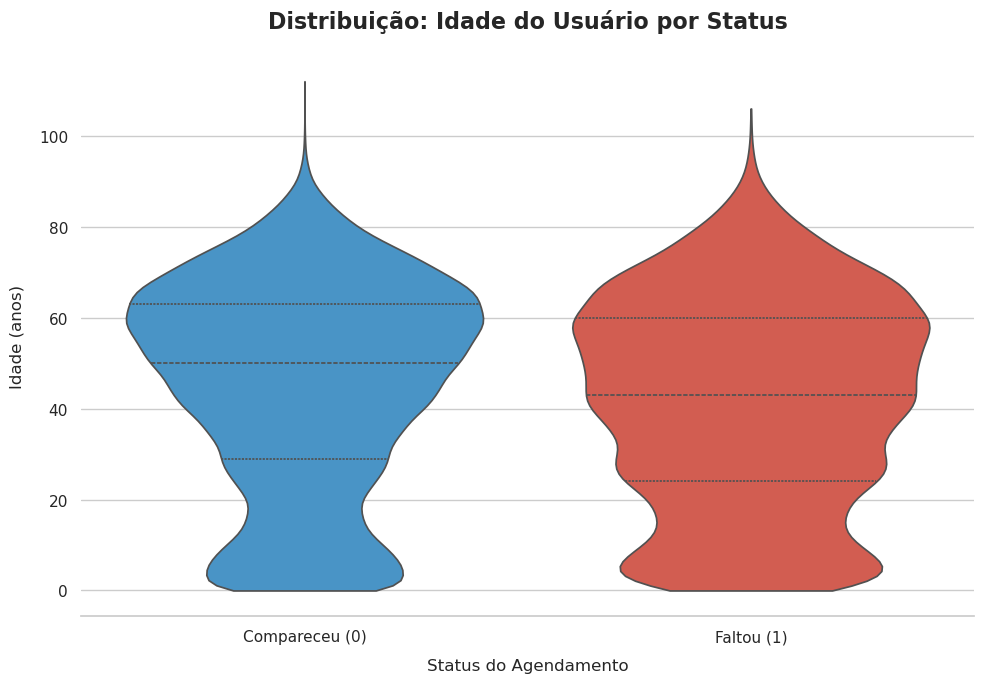

Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/09_bivariate_numeric_by_target_tempo_espera.png


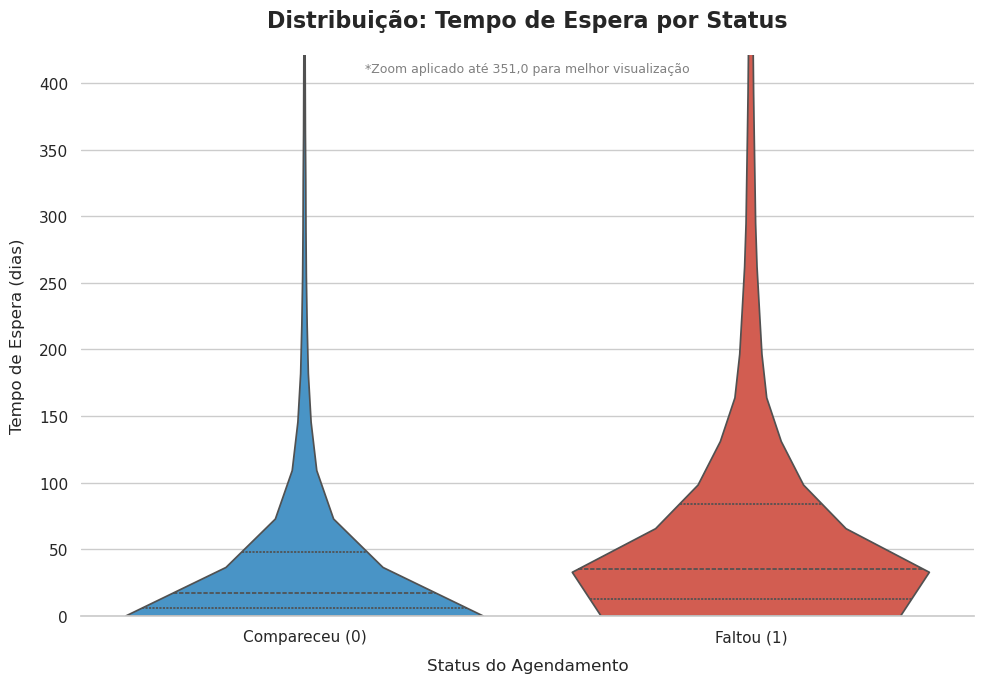

Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/09_bivariate_numeric_by_target_distance_km.png


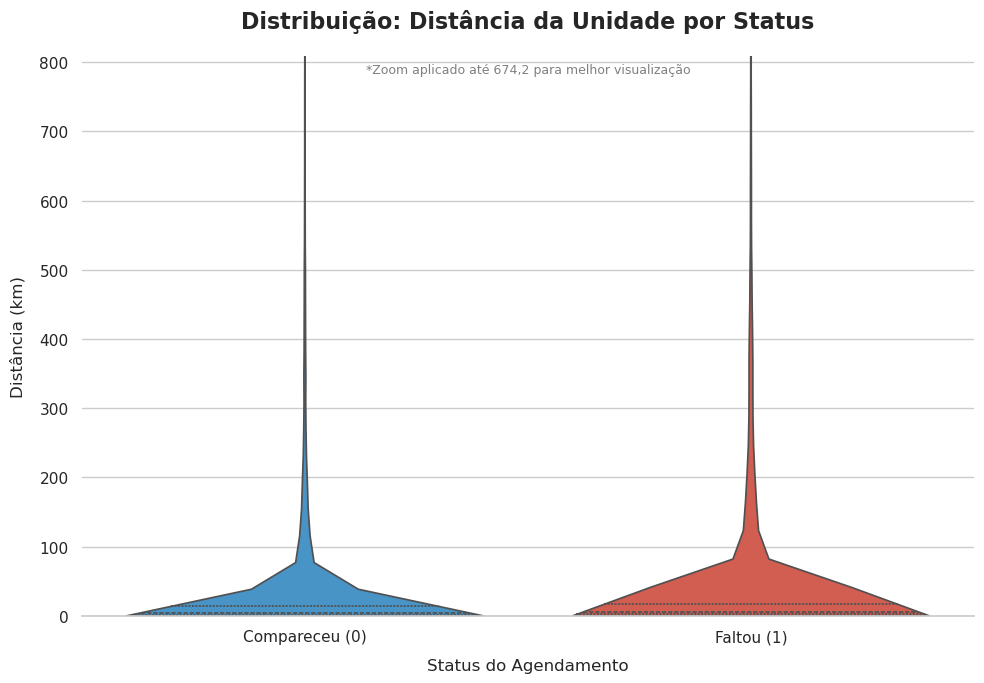

Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/09_bivariate_numeric_by_target_contagem_faltas_anteriores.png


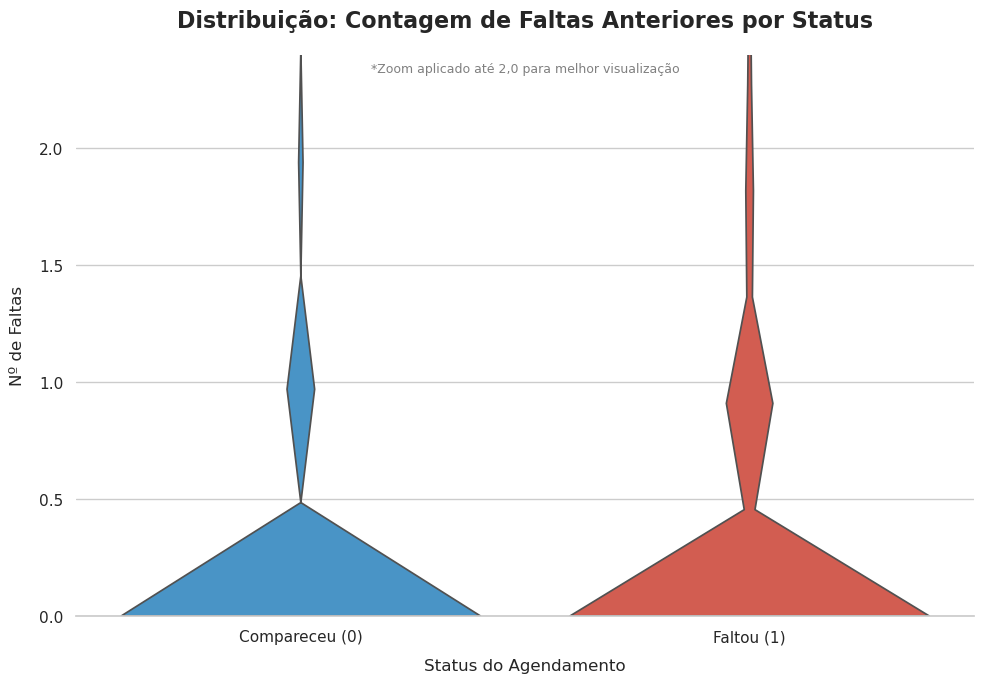

Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/09_bivariate_numeric_by_target_total_consultas_anteriores.png


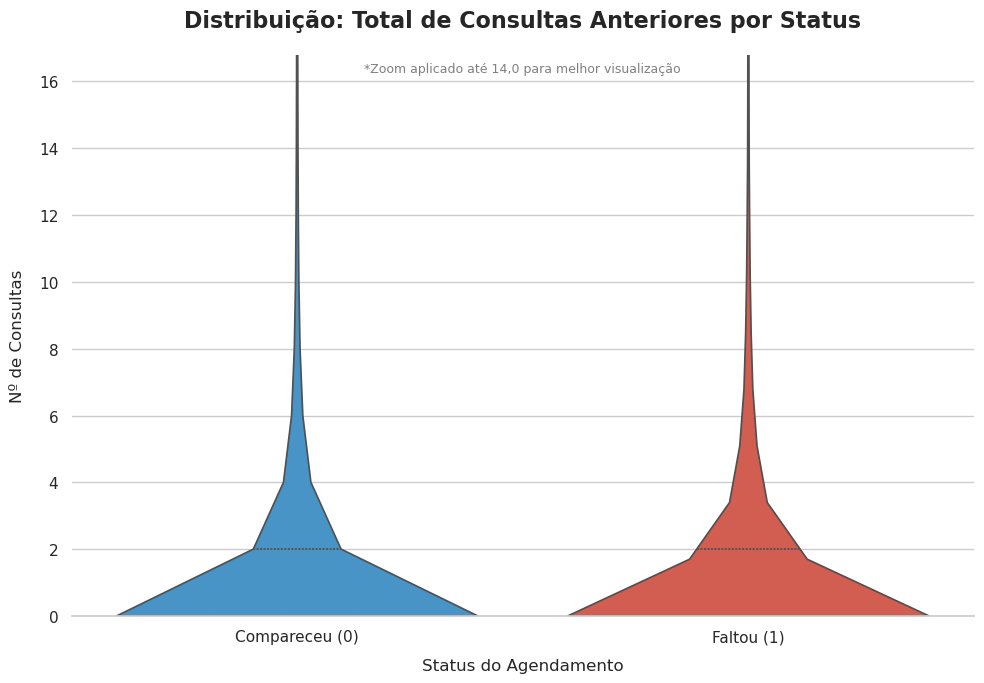

Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/09_bivariate_numeric_by_target_percentual_faltas_anteriores.png


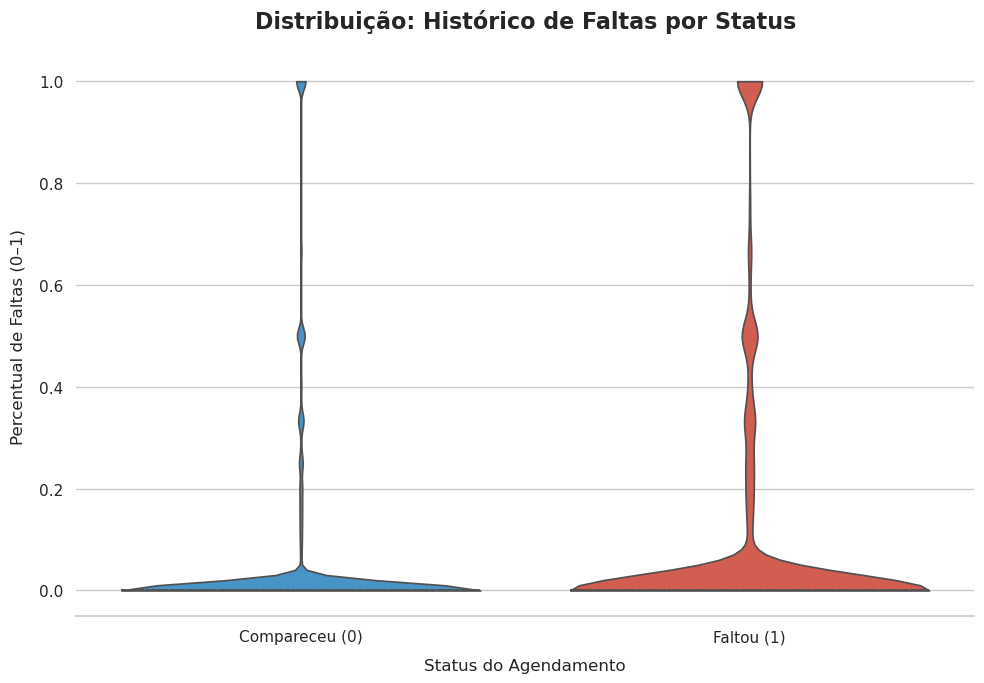

Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/09_bivariate_numeric_by_target_cep_prefix_len_usuario.png


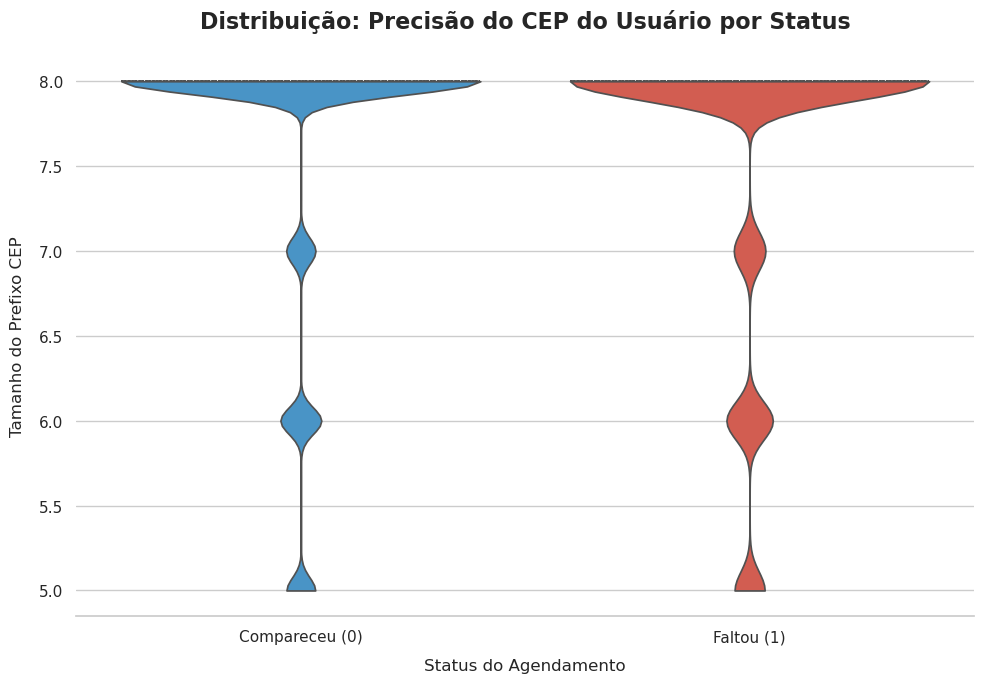

Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/09_bivariate_numeric_by_target_cep_prefix_len_cnes.png


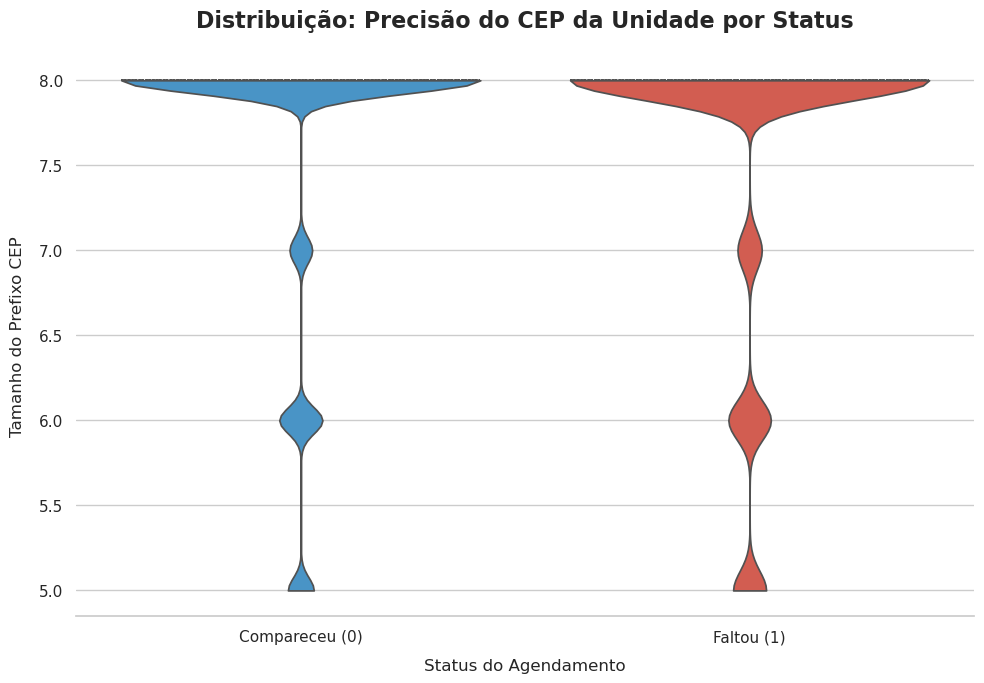

45570

In [ ]:
# ==============================================================================
# Bivariate analysis: numerical features vs target
# ==============================================================================
print("--- Análise Bivariada: Features Numéricas vs. Alvo ---")

# --- 1. Define Features ---
bivariate_numerical_features = available_columns([
    'idade_usuario',
    'tempo_espera',
    'distance_km',
    'contagem_faltas_anteriores',
    'total_consultas_anteriores',
    'percentual_faltas_anteriores',
    'cep_prefix_len_usuario',
    'cep_prefix_len_cnes',
])

print(f"Bivariate numerical features ({len(bivariate_numerical_features)}): {bivariate_numerical_features}")

# --- 2. Compare summary statistics by target ---
summary_by_target = df_2023.groupby(TARGET, observed=True)[bivariate_numerical_features].agg(['count', 'mean', 'median', 'std'])
save_table(summary_by_target.reset_index(), 'bivariate_numerical_summary_by_target.csv')
display(summary_by_target)

# More compact median table for dissertation text.
median_comparison = df_2023.groupby(TARGET, observed=True)[bivariate_numerical_features].median()
median_comparison.index = median_comparison.index.map({0: 'Compareceu (0)', 1: 'Faltou (1)'})
print("\n--- Comparação das Medianas (Compareceu vs. Faltou) ---")
display(format_numeric_table_br(median_comparison, digits=3))
print("---------------------------------------------------------")

# --- 3. Generate Violin Plots ---
# Create a mapped column just for plotting labels. Use sample for plot efficiency.
df_plot = smart_sample(df_2023[[TARGET] + bivariate_numerical_features], n=PLOT_SAMPLE_N, seed=SEED)
df_plot['status'] = df_plot[TARGET].map({0: 'Compareceu (0)', 1: 'Faltou (1)'})
status_order = ['Compareceu (0)', 'Faltou (1)']

plot_labels_biv_num = {
    'idade_usuario': {'title': 'Idade do Usuário', 'ylabel': 'Idade (anos)'},
    'tempo_espera': {'title': 'Tempo de Espera', 'ylabel': 'Tempo de Espera (dias)'},
    'distance_km': {'title': 'Distância da Unidade', 'ylabel': 'Distância (km)'},
    'contagem_faltas_anteriores': {'title': 'Contagem de Faltas Anteriores', 'ylabel': 'Nº de Faltas'},
    'total_consultas_anteriores': {'title': 'Total de Consultas Anteriores', 'ylabel': 'Nº de Consultas'},
    'percentual_faltas_anteriores': {'title': 'Histórico de Faltas', 'ylabel': 'Percentual de Faltas (0–1)'},
    'cep_prefix_len_usuario': {'title': 'Precisão do CEP do Usuário', 'ylabel': 'Tamanho do Prefixo CEP'},
    'cep_prefix_len_cnes': {'title': 'Precisão do CEP da Unidade', 'ylabel': 'Tamanho do Prefixo CEP'},
}

for col in bivariate_numerical_features:
    plt.figure(figsize=(10, 7))
    ax = sns.violinplot(
        data=df_plot,
        x='status',
        y=col,
        order=status_order,
        palette=status_palette,
        inner='quartile',
        hue='status',
        legend=False,
        cut=0,
    )

    feature_title = plot_labels_biv_num.get(col, {}).get('title', col)
    ax.set_title(f'Distribuição: {feature_title} por Status', fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Status do Agendamento', fontsize=12, labelpad=10)
    ax.set_ylabel(plot_labels_biv_num.get(col, {}).get('ylabel', col), fontsize=12, labelpad=10)

    # --- Intelligent Visual Zoom ---
    if col in ['distance_km', 'tempo_espera', 'contagem_faltas_anteriores', 'total_consultas_anteriores']:
        q98 = df_2023[col].quantile(0.98)
        if pd.notnull(q98) and q98 > 0:
            ax.set_ylim(0, q98 * 1.2)
            ax.text(
                x=0.5, y=0.97,
                s=f"*Zoom aplicado até {br_decimal(q98, 1)} para melhor visualização",
                transform=ax.transAxes,
                ha='center',
                fontsize=9,
                color='gray'
            )

    sns.despine(left=True)
    plt.tight_layout()
    save_current_figure(f'09_bivariate_numeric_by_target_{col}')
    plt.show()

del df_plot
gc.collect()


--- Análise Bivariada: Indicadores Binários e Geográficos vs. Alvo ---
Binary/geographic indicators analyzed (6): ['mesma_unidade_anterior', 'mesma_cidade', 'mesmo_estado', 'mesma_regiao', 'cep_aprox_usuario', 'cep_aprox_cnes']

--- Feature: mesma_unidade_anterior ---


,mesma_unidade_anterior,count,no_show_rate,no_show_count,feature,label,lift_vs_global,no_show_rate_br,lift_br
0,0,4670217,0.15647,730749,mesma_unidade_anterior,Não / 0,1.06562,"15,65%","1,066"
1,1,2443581,0.12842,313804,mesma_unidade_anterior,Sim / 1,0.874587,"12,84%","0,875"


Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/10_bivariate_binary_mesma_unidade_anterior.png


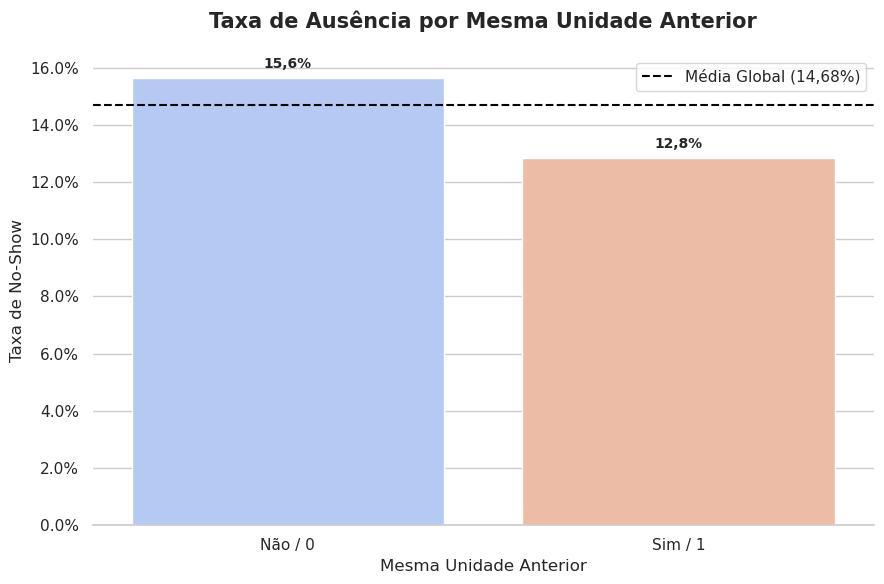


--- Feature: mesma_cidade ---


,mesma_cidade,count,no_show_rate,no_show_count,feature,label,lift_vs_global,no_show_rate_br,lift_br
0,0,1486188,0.146498,217723,mesma_cidade,Não / 0,0.997704,"14,65%","0,998"
1,1,5627610,0.146924,826830,mesma_cidade,Sim / 1,1.000606,"14,69%","1,001"


Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/10_bivariate_binary_mesma_cidade.png


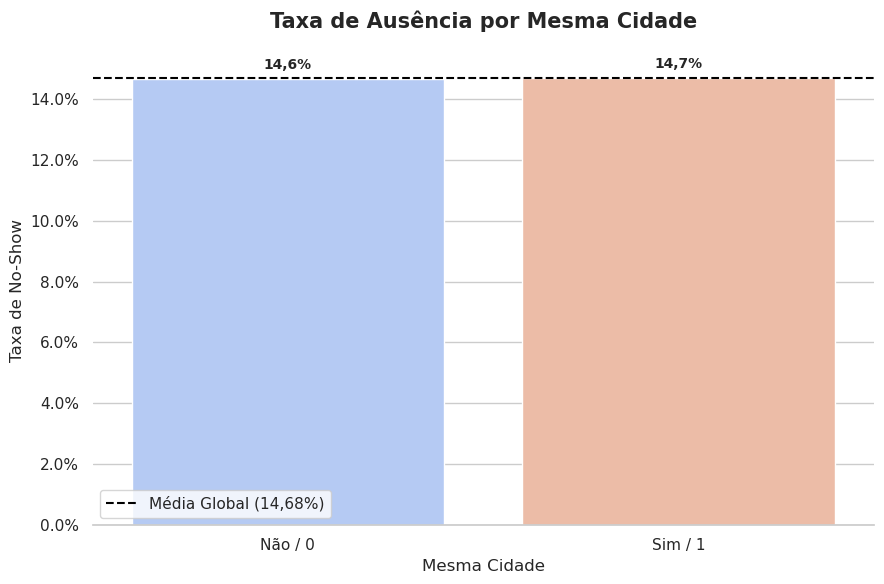


--- Feature: mesmo_estado ---


,mesmo_estado,count,no_show_rate,no_show_count,feature,label,lift_vs_global,no_show_rate_br,lift_br
0,0,181144,0.169213,30652,mesmo_estado,Não / 0,1.152407,"16,92%","1,152"
1,1,6932654,0.14625,1013901,mesmo_estado,Sim / 1,0.996018,"14,63%","0,996"


Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/10_bivariate_binary_mesmo_estado.png


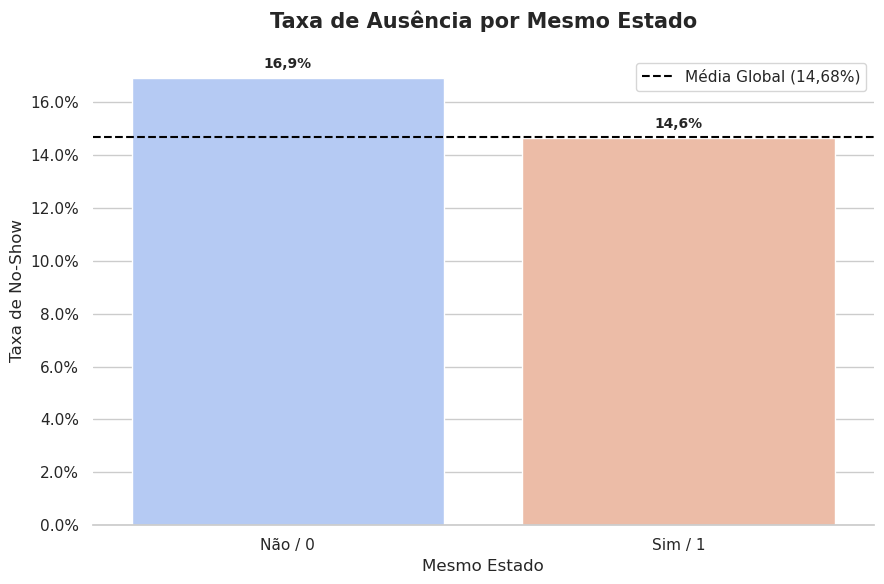


--- Feature: mesma_regiao ---


,mesma_regiao,count,no_show_rate,no_show_count,feature,label,lift_vs_global,no_show_rate_br,lift_br
0,0,58541,0.183205,10725,mesma_regiao,Não / 0,1.247694,"18,32%","1,248"
1,1,7055257,0.146533,1033828,mesma_regiao,Sim / 1,0.997945,"14,65%","0,998"


Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/10_bivariate_binary_mesma_regiao.png


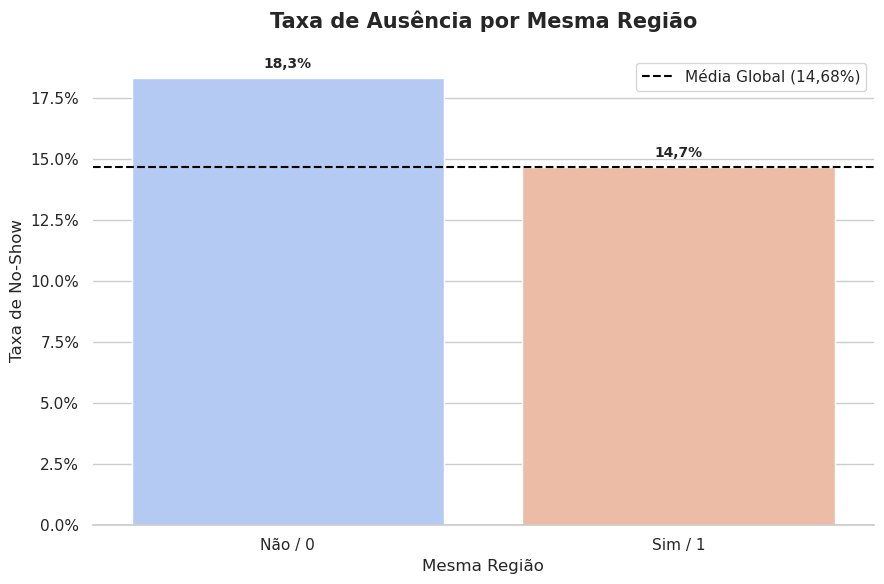


--- Feature: cep_aprox_usuario ---


,cep_aprox_usuario,count,no_show_rate,no_show_count,feature,label,lift_vs_global,no_show_rate_br,lift_br
0,0,5560329,0.143904,800153,cep_aprox_usuario,Não / 0,0.98004,"14,39%","0,980"
1,1,1553469,0.157325,244400,cep_aprox_usuario,Sim / 1,1.071444,"15,73%","1,071"


Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/10_bivariate_binary_cep_aprox_usuario.png


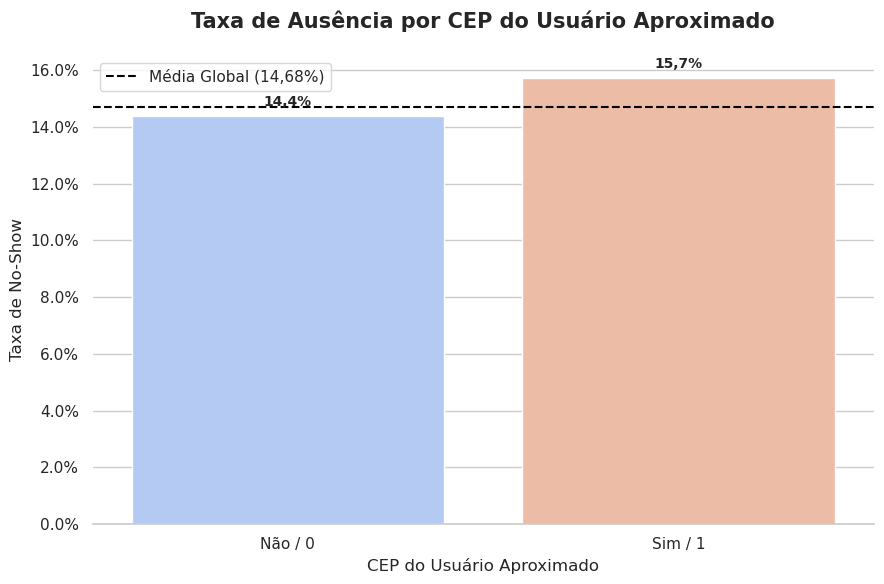


--- Feature: cep_aprox_cnes ---


,cep_aprox_cnes,count,no_show_rate,no_show_count,feature,label,lift_vs_global,no_show_rate_br,lift_br
0,0,5647030,0.144134,813931,cep_aprox_cnes,Não / 0,0.981609,"14,41%","0,982"
1,1,1466768,0.157231,230622,cep_aprox_cnes,Sim / 1,1.070805,"15,72%","1,071"


Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/10_bivariate_binary_cep_aprox_cnes.png


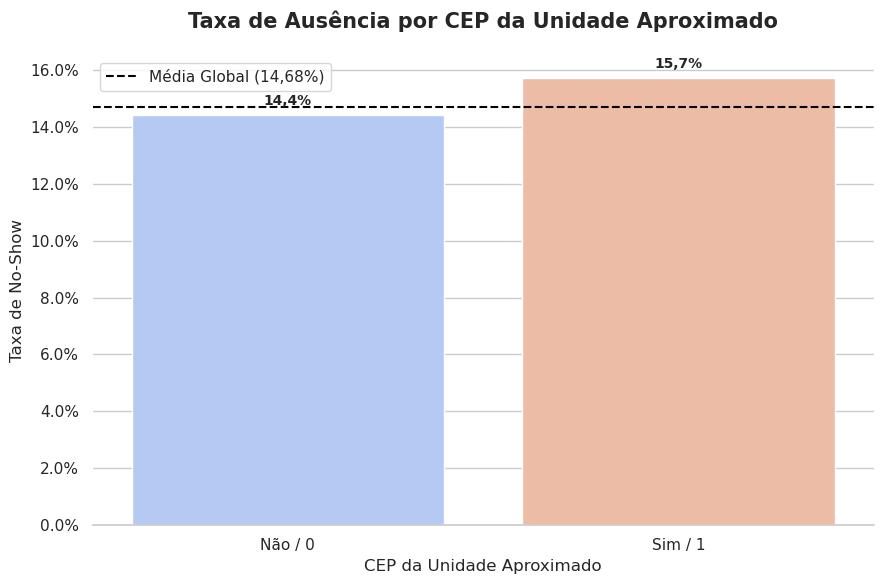

Saved table: ../reports/descriptive_analysis_refreshed_v3/tables/bivariate_binary_indicators_vs_target.csv


PosixPath('../reports/descriptive_analysis_refreshed_v3/tables/bivariate_binary_indicators_vs_target.csv')

In [ ]:
# ==============================================================================
# Bivariate analysis: binary/geographic indicators vs target
# ==============================================================================
print("--- Análise Bivariada: Indicadores Binários e Geográficos vs. Alvo ---")

# This cell makes explicit the analysis of binary
# engineered features created by the preprocessing pipeline.
binary_features = available_columns([
    'mesma_unidade_anterior',
    'mesma_cidade',
    'mesmo_estado',
    'mesma_regiao',
    'cep_aprox_usuario',
    'cep_aprox_cnes',
])

binary_labels = {
    'mesma_unidade_anterior': 'Mesma Unidade Anterior',
    'mesma_cidade': 'Mesma Cidade',
    'mesmo_estado': 'Mesmo Estado',
    'mesma_regiao': 'Mesma Região',
    'cep_aprox_usuario': 'CEP do Usuário Aproximado',
    'cep_aprox_cnes': 'CEP da Unidade Aproximado',
}

print(f"Binary/geographic indicators analyzed ({len(binary_features)}): {binary_features}")
global_rate = df_2023[TARGET].mean()
all_binary_rows = []

for col in binary_features:
    table = (
        df_2023.groupby(col, observed=True)[TARGET]
        .agg(count='count', no_show_rate='mean', no_show_count='sum')
        .reset_index()
    )
    table['feature'] = col
    table['label'] = table[col].map({0: 'Não / 0', 1: 'Sim / 1'}).fillna(table[col].astype(str))
    table['lift_vs_global'] = table['no_show_rate'] / global_rate if global_rate > 0 else np.nan
    all_binary_rows.append(table[['feature', col, 'label', 'count', 'no_show_count', 'no_show_rate', 'lift_vs_global']].rename(columns={col: 'value'}))

    print(f"\n--- Feature: {col} ---")
    display(table.assign(no_show_rate_br=lambda x: x['no_show_rate'].map(br_percent), lift_br=lambda x: x['lift_vs_global'].map(lambda v: br_decimal(v, 3))))

    plt.figure(figsize=(9, 6))
    ax = sns.barplot(data=table, x='label', y='no_show_rate', palette='coolwarm', errorbar=None)
    ax.set_title(f'Taxa de Ausência por {binary_labels.get(col, col)}', fontsize=15, fontweight='bold', pad=20)
    ax.set_xlabel(binary_labels.get(col, col))
    ax.set_ylabel('Taxa de No-Show')
    ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0))
    ax.axhline(global_rate, color='black', linestyle='--', linewidth=1.5, label=f'Média Global ({br_percent(global_rate)})')
    ax.legend()

    for p in ax.patches:
        height = p.get_height()
        if pd.notnull(height):
            ax.annotate(
                br_percent(height, 1),
                (p.get_x() + p.get_width()/2, height),
                ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points',
                fontsize=10, fontweight='bold'
            )

    sns.despine(left=True)
    plt.tight_layout()
    save_current_figure(f'10_bivariate_binary_{col}')
    plt.show()

binary_bivariate_table = pd.concat(all_binary_rows, ignore_index=True) if all_binary_rows else pd.DataFrame()
save_table(binary_bivariate_table, 'bivariate_binary_indicators_vs_target.csv')


--- Análise Bivariada: Features Categóricas vs. Alvo ---

--- Feature: sexo_usuario ---
Número de categorias únicas: 3


,sexo_usuario,count,no_show_count,no_show_rate,feature,lift_vs_global,low_support_flag,no_show_rate_br
2,Masculino,2653861,395632,0.149078,sexo_usuario,1.015276,False,"14,91%"
0,Feminino,4459936,648921,0.1455,sexo_usuario,0.99091,False,"14,55%"
1,Indefinido,1,0,0.0,sexo_usuario,0.0,True,"0,00%"


Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/11_bivariate_categorical_sexo_usuario.png


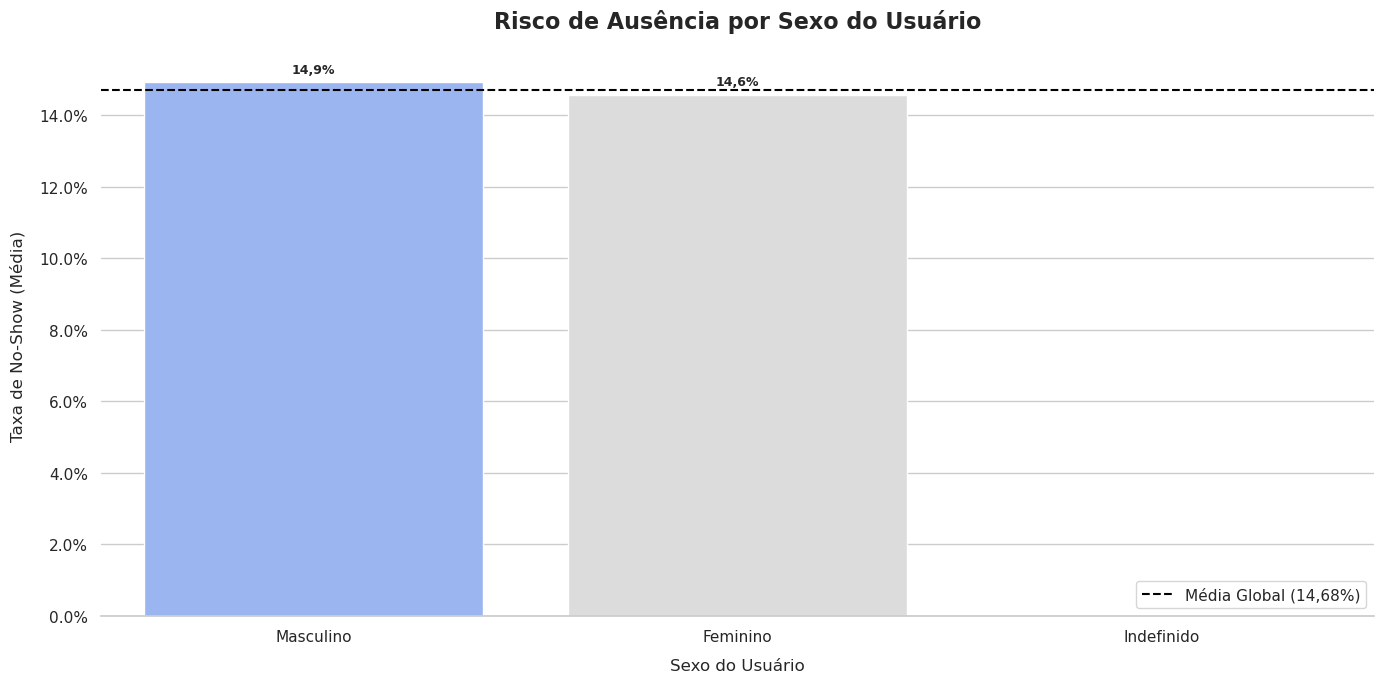


--- Feature: prioridade ---
Número de categorias únicas: 4


,prioridade,count,no_show_count,no_show_rate,feature,lift_vs_global,low_support_flag,no_show_rate_br
0,0,331432,66528,0.200729,prioridade,1.36704,False,"20,07%"
1,1,754145,146013,0.193614,prioridade,1.318584,False,"19,36%"
2,2,576549,107192,0.18592,prioridade,1.266185,False,"18,59%"
3,3,5451672,724820,0.132954,prioridade,0.905465,False,"13,30%"


Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/11_bivariate_categorical_prioridade.png


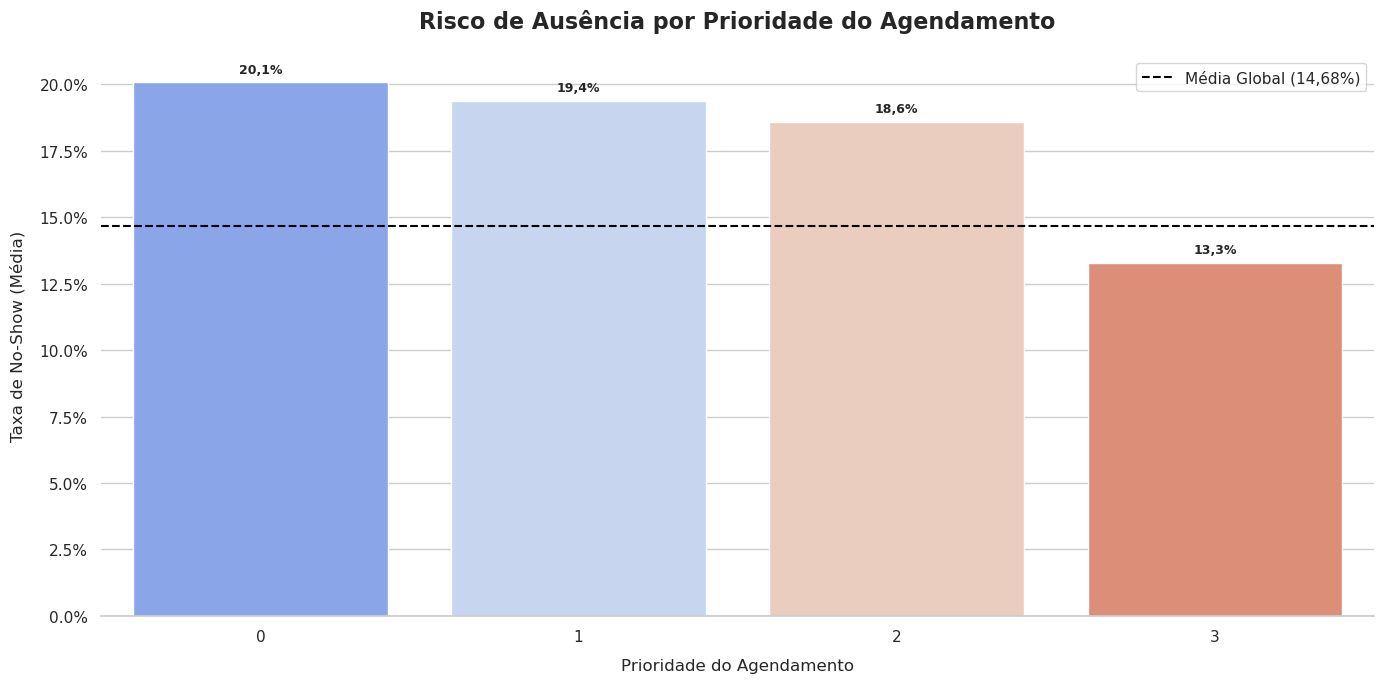


--- Feature: raca_cor_usuario ---
Número de categorias únicas: 6


,raca_cor_usuario,count,no_show_count,no_show_rate,feature,lift_vs_global,low_support_flag,no_show_rate_br
4,05,16413,3295,0.200755,raca_cor_usuario,1.36722,False,"20,08%"
1,02,437639,69648,0.159145,raca_cor_usuario,1.083836,False,"15,91%"
2,03,2624663,411466,0.156769,raca_cor_usuario,1.067656,False,"15,68%"
5,99,288163,41151,0.142805,raca_cor_usuario,0.972553,False,"14,28%"
3,04,858851,118974,0.138527,raca_cor_usuario,0.94342,False,"13,85%"
0,01,2888069,400019,0.138507,raca_cor_usuario,0.943288,False,"13,85%"


Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/11_bivariate_categorical_raca_cor_usuario.png


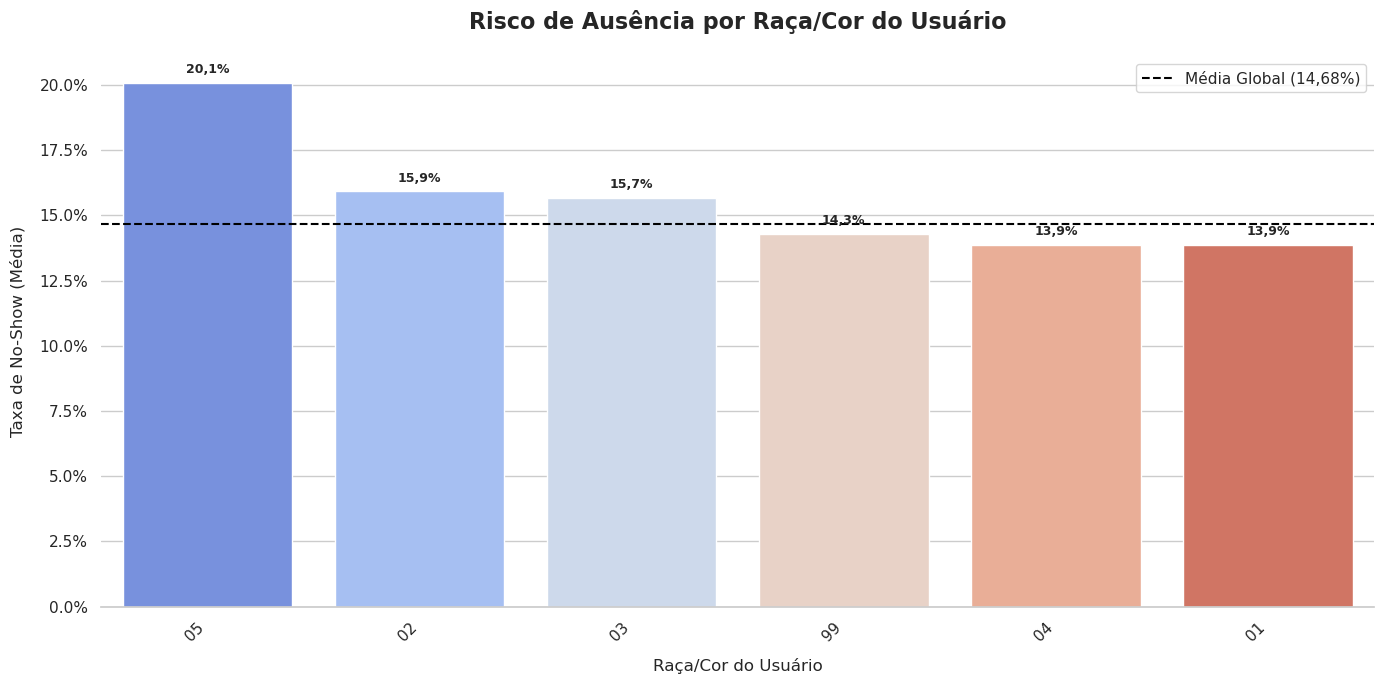


--- Feature: tip_marcacao ---
Número de categorias únicas: 3


,tip_marcacao,count,no_show_count,no_show_rate,feature,lift_vs_global,low_support_flag,no_show_rate_br
2,2,2116132,400521,0.18927,tip_marcacao,1.289002,False,"18,93%"
1,1,1772725,245464,0.138467,tip_marcacao,0.943013,False,"13,85%"
0,0,3224941,398568,0.123589,tip_marcacao,0.841689,False,"12,36%"


Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/11_bivariate_categorical_tip_marcacao.png


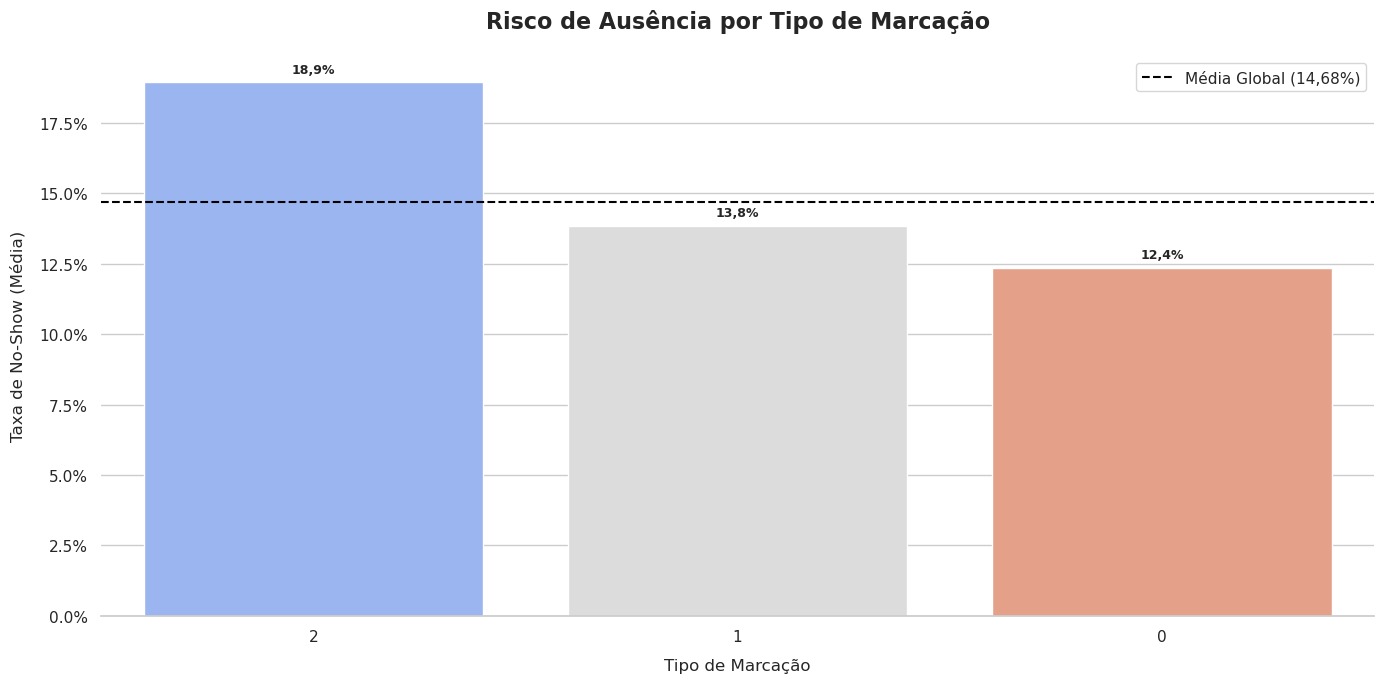


--- Feature: deslocamento ---
Número de categorias únicas: 3


,deslocamento,count,no_show_count,no_show_rate,feature,lift_vs_global,low_support_flag,no_show_rate_br
0,2,83307,16192,0.194365,deslocamento,1.323701,False,"19,44%"
2,Local,5759603,844448,0.146616,deslocamento,0.998508,False,"14,66%"
1,Em Trânsito,1270888,183913,0.144712,deslocamento,0.985544,False,"14,47%"


Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/11_bivariate_categorical_deslocamento.png


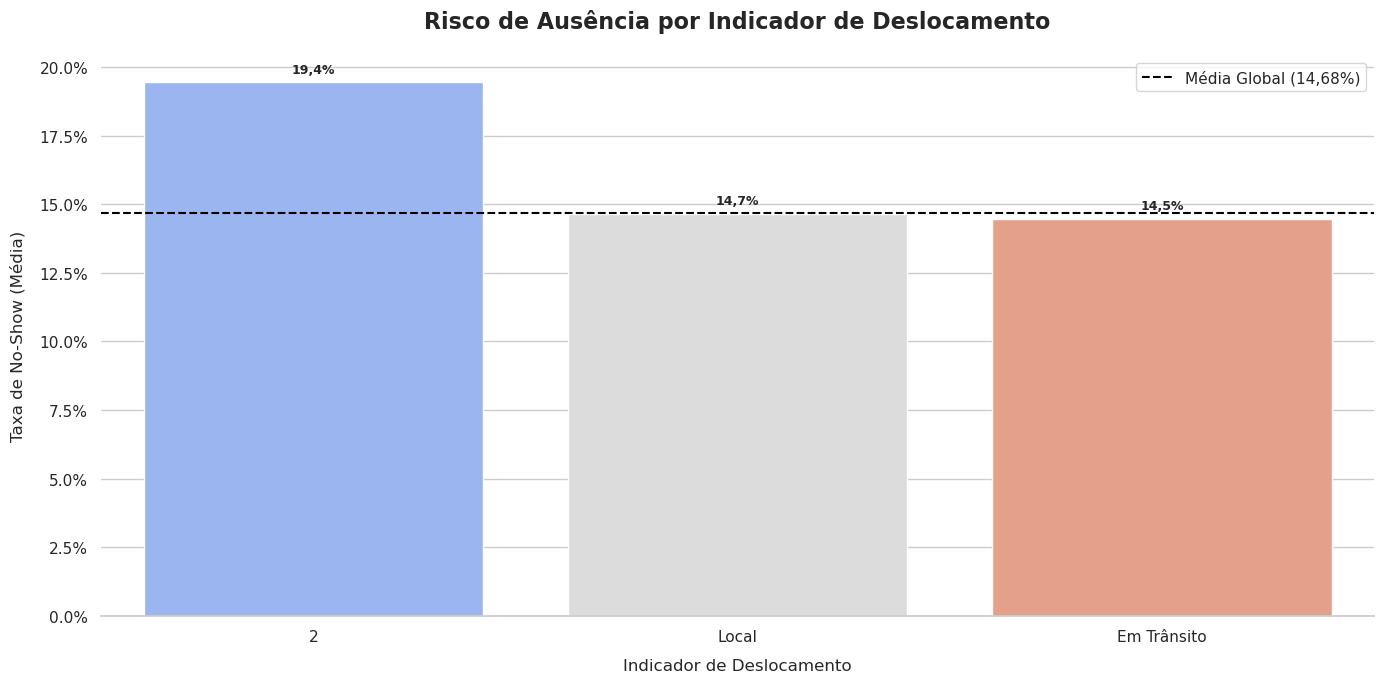


--- Feature: cbo_espec ---
Número de categorias únicas: 76


,cbo_espec,count,no_show_count,no_show_rate,feature,lift_vs_global,low_support_flag,no_show_rate_br
10,223280,14304,6410,0.448126,cbo_espec,3.051909,False,"44,81%"
40,225142,2435,1010,0.414784,cbo_espec,2.824837,False,"41,48%"
22,224120,996,408,0.409639,cbo_espec,2.789792,False,"40,96%"
2,223232,782,311,0.397698,cbo_espec,2.708474,False,"39,77%"
72,226310,284,105,0.369718,cbo_espec,2.51792,False,"36,97%"
15,223565,2349,846,0.360153,cbo_espec,2.452779,False,"36,02%"
1,223220,233,73,0.313305,cbo_espec,2.133723,False,"31,33%"
18,223710,166405,44881,0.269709,cbo_espec,1.836823,False,"26,97%"
9,223276,18135,4681,0.25812,cbo_espec,1.757892,False,"25,81%"
71,226305,514,131,0.254864,cbo_espec,1.735718,False,"25,49%"


Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/11_bivariate_categorical_cbo_espec.png


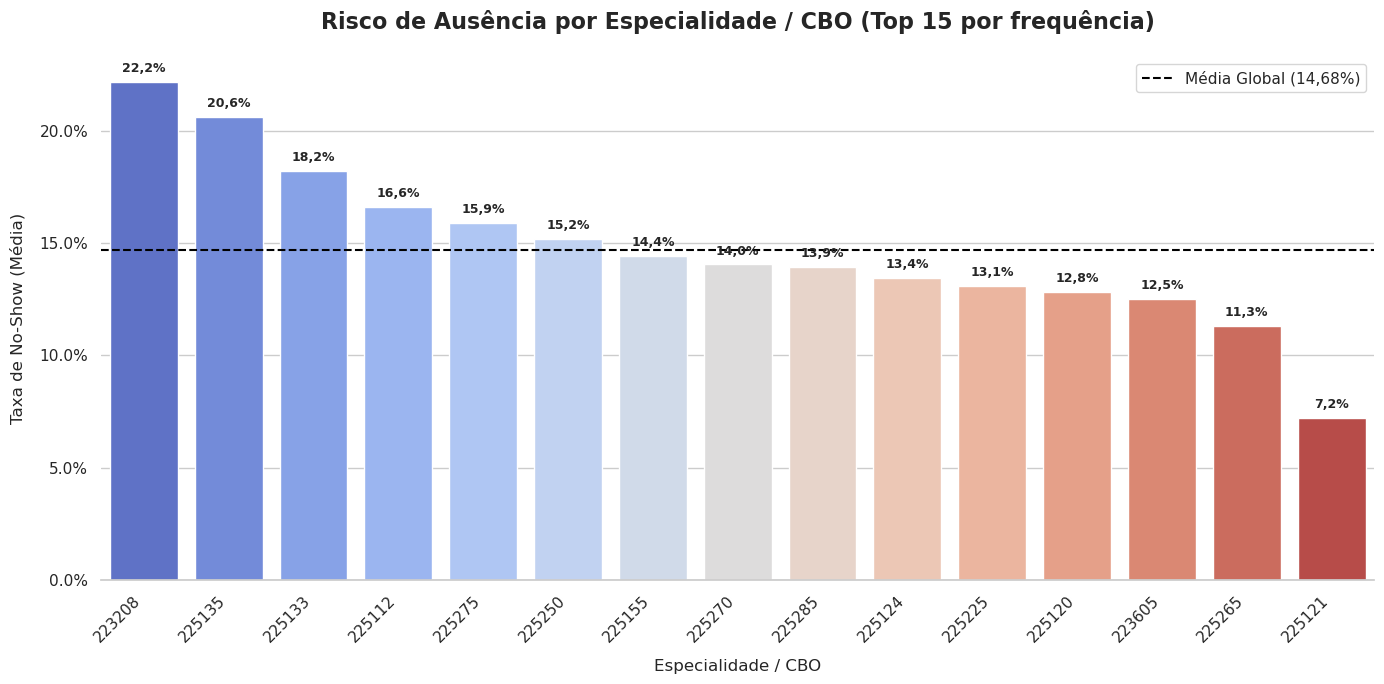


--- Feature: uf_usuario ---
Número de categorias únicas: 26


,uf_usuario,count,no_show_count,no_show_rate,feature,lift_vs_global,low_support_flag,no_show_rate_br
3,ap,3129,952,0.304251,uf_usuario,2.072061,False,"30,43%"
20,rr,1735,447,0.257637,uf_usuario,1.754604,False,"25,76%"
2,am,330979,84698,0.255901,uf_usuario,1.742785,False,"25,59%"
10,ms,409678,87138,0.212699,uf_usuario,1.448558,False,"21,27%"
17,rj,1275850,253311,0.198543,uf_usuario,1.352152,False,"19,85%"
15,pi,1213,235,0.193735,uf_usuario,1.319405,False,"19,37%"
19,ro,169661,31065,0.1831,uf_usuario,1.246983,False,"18,31%"
25,to,136676,24374,0.178334,uf_usuario,1.214523,False,"17,83%"
8,ma,748188,129859,0.173565,uf_usuario,1.182041,False,"17,36%"
16,pr,108200,18044,0.166765,uf_usuario,1.135734,False,"16,68%"


Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/11_bivariate_categorical_uf_usuario.png


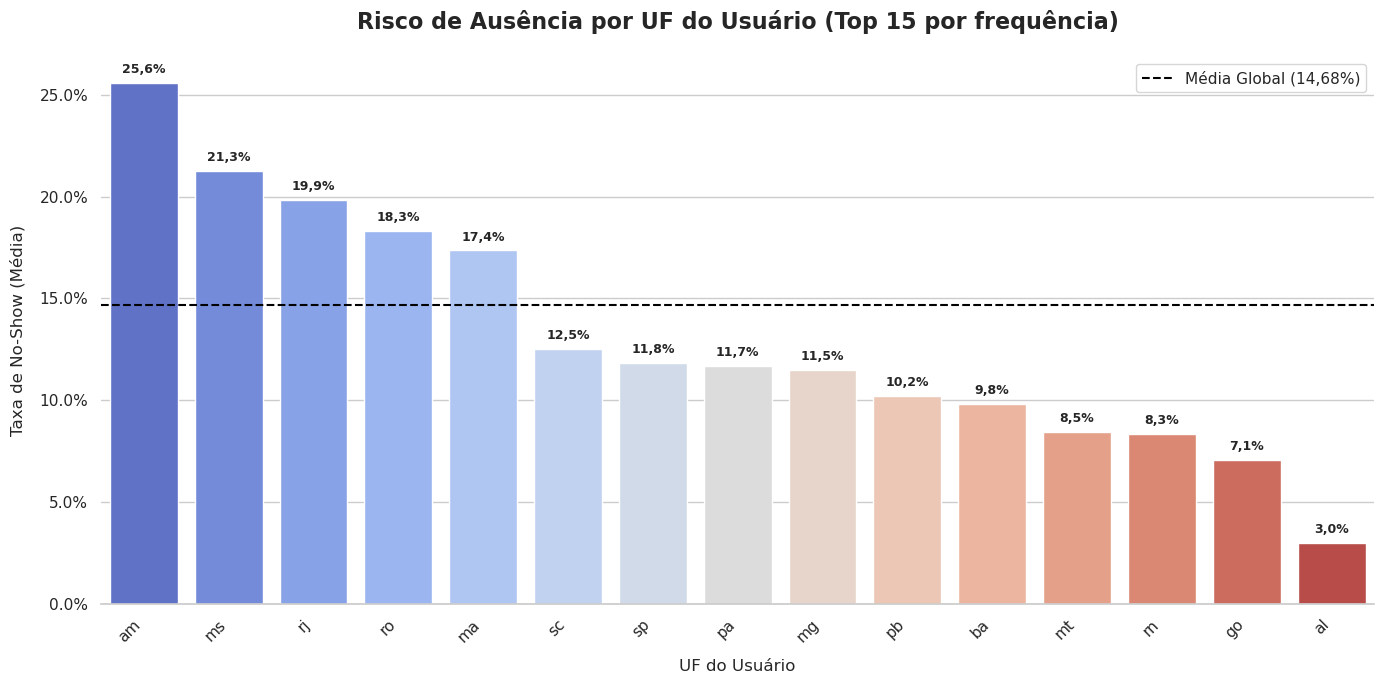


--- Feature: uf_cnes ---
Número de categorias únicas: 24


,uf_cnes,count,no_show_count,no_show_rate,feature,lift_vs_global,low_support_flag,no_show_rate_br
3,ap,2487,889,0.357459,uf_cnes,2.434429,False,"35,75%"
2,am,404815,96739,0.238971,uf_cnes,1.627481,False,"23,90%"
10,ms,407936,87276,0.213945,uf_cnes,1.457048,False,"21,39%"
16,rj,1281692,255154,0.199076,uf_cnes,1.355782,False,"19,91%"
18,ro,173207,31988,0.184681,uf_cnes,1.257745,False,"18,47%"
23,to,137537,24731,0.179813,uf_cnes,1.224597,False,"17,98%"
8,ma,758063,131578,0.173571,uf_cnes,1.182086,False,"17,36%"
0,ac,57169,9717,0.16997,uf_cnes,1.157558,False,"17,00%"
15,pr,98678,16553,0.167748,uf_cnes,1.142424,False,"16,77%"
20,sc,1435078,180247,0.125601,uf_cnes,0.855389,False,"12,56%"


Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/11_bivariate_categorical_uf_cnes.png


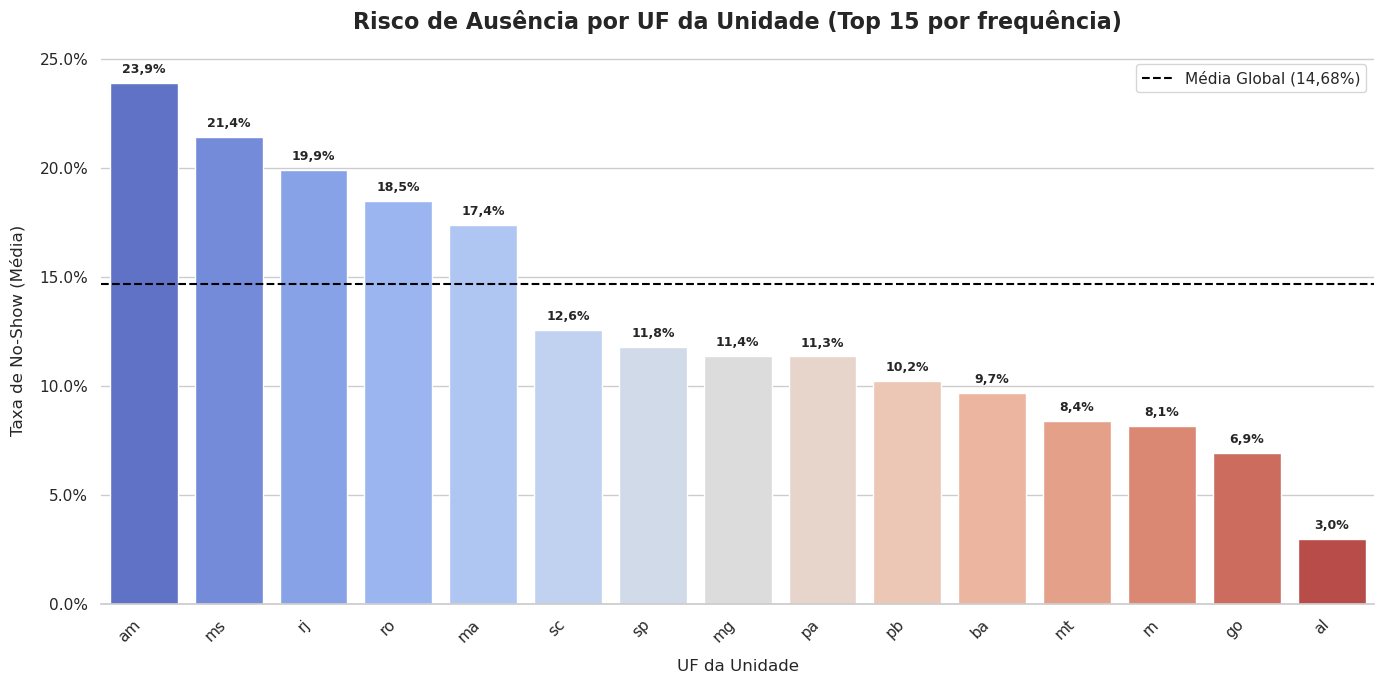


--- Feature: regiao_usuario ---
Número de categorias únicas: 5


,regiao_usuario,count,no_show_count,no_show_rate,feature,lift_vs_global,low_support_flag,no_show_rate_br
2,norte,1009928,190002,0.188134,regiao_usuario,1.281265,False,"18,81%"
3,sudeste,1864500,317483,0.170278,regiao_usuario,1.159656,False,"17,03%"
0,centro-oeste,1020308,134606,0.131927,regiao_usuario,0.898471,False,"13,19%"
4,sul,1543859,197617,0.128002,regiao_usuario,0.871741,False,"12,80%"
1,nordeste,1675203,204845,0.122281,regiao_usuario,0.832777,False,"12,23%"


Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/11_bivariate_categorical_regiao_usuario.png


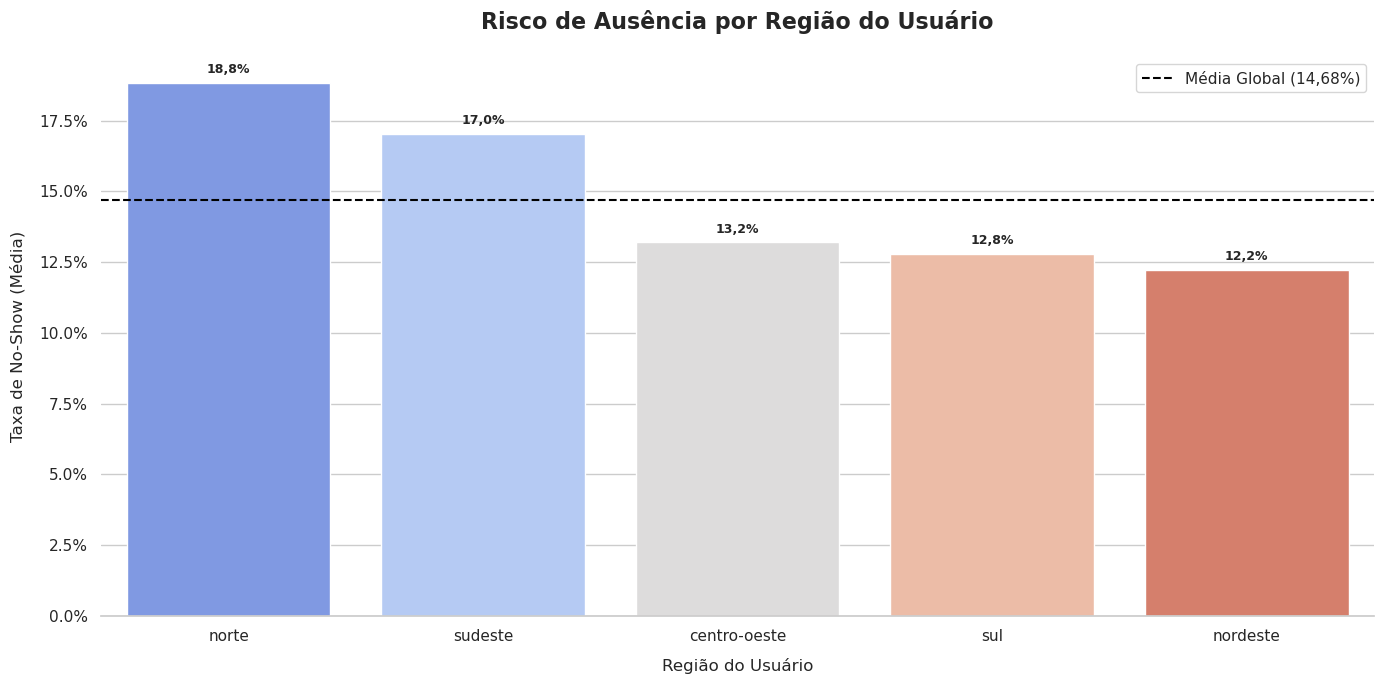


--- Feature: regiao_cnes ---
Número de categorias únicas: 5


,regiao_cnes,count,no_show_count,no_show_rate,feature,lift_vs_global,low_support_flag,no_show_rate_br
2,norte,1009343,190631,0.188866,regiao_cnes,1.286251,False,"18,89%"
3,sudeste,1859939,317592,0.170754,regiao_cnes,1.162899,False,"17,08%"
0,centro-oeste,1020315,134254,0.131581,regiao_cnes,0.896116,False,"13,16%"
4,sul,1543343,197421,0.127918,regiao_cnes,0.871168,False,"12,79%"
1,nordeste,1680858,204655,0.121756,regiao_cnes,0.829206,False,"12,18%"


Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/11_bivariate_categorical_regiao_cnes.png


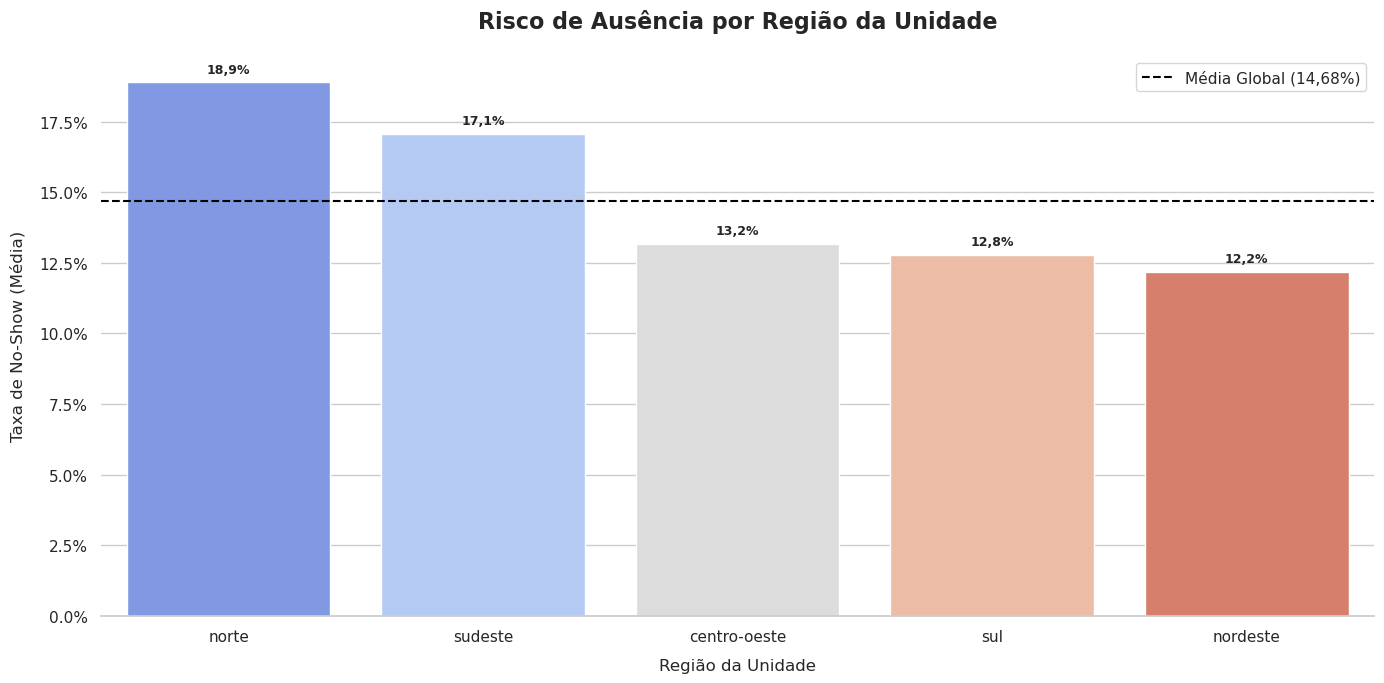

Saved table: ../reports/descriptive_analysis_refreshed_v3/tables/bivariate_categorical_features_vs_target.csv


PosixPath('../reports/descriptive_analysis_refreshed_v3/tables/bivariate_categorical_features_vs_target.csv')

In [ ]:
# ==============================================================================
# Bivariate analysis: categorical features vs target
# ==============================================================================
print("--- Análise Bivariada: Features Categóricas vs. Alvo ---")

# --- 1. Categorical Features ---
bivariate_categorical_features = available_columns([
    'sexo_usuario',
    'prioridade',
    'raca_cor_usuario',
    'tip_marcacao',
    'deslocamento',
    'cbo_espec',
    'uf_usuario',
    'uf_cnes',
    'regiao_usuario',
    'regiao_cnes',
])

plot_labels_cat = {
    'sexo_usuario': 'Sexo do Usuário',
    'prioridade': 'Prioridade do Agendamento',
    'raca_cor_usuario': 'Raça/Cor do Usuário',
    'tip_marcacao': 'Tipo de Marcação',
    'deslocamento': 'Indicador de Deslocamento',
    'cbo_espec': 'Especialidade / CBO',
    'uf_usuario': 'UF do Usuário',
    'uf_cnes': 'UF da Unidade',
    'regiao_usuario': 'Região do Usuário',
    'regiao_cnes': 'Região da Unidade',
}

# --- 2. Overall benchmark ---
global_rate = df_2023[TARGET].mean()
all_rate_tables = []

# --- 3. Loop by categorical feature ---
for col in bivariate_categorical_features:
    print(f"\n--- Feature: {col} ---")
    df_tmp = df_2023[[col, TARGET]].copy()

    # --- Specific mappings ---
    if col == 'sexo_usuario':
        df_tmp[col] = df_tmp[col].astype(object).replace({
            'f': 'Feminino', 'F': 'Feminino',
            'm': 'Masculino', 'M': 'Masculino',
            'i': 'Indefinido', 'I': 'Indefinido'
        })
    elif col == 'deslocamento':
        df_tmp[col] = df_tmp[col].astype(object).replace({
            0: 'Local', 1: 'Em Trânsito',
            '0': 'Local', '1': 'Em Trânsito'
        })

    rate_table = (
        df_tmp.groupby(col, observed=True)[TARGET]
        .agg(count='count', no_show_count='sum', no_show_rate='mean')
        .reset_index()
        .sort_values('no_show_rate', ascending=False)
    )
    rate_table['feature'] = col
    rate_table['lift_vs_global'] = rate_table['no_show_rate'] / global_rate if global_rate > 0 else np.nan
    rate_table['low_support_flag'] = rate_table['count'] < MIN_GROUP_N_FOR_RATE_TABLE
    all_rate_tables.append(rate_table.rename(columns={col: 'category'}))

    print(f"Número de categorias únicas: {df_tmp[col].nunique(dropna=False)}")
    display(rate_table.head(20).assign(no_show_rate_br=lambda x: x['no_show_rate'].map(br_percent)))

    # --- Reduce cardinality for the chart, if necessary ---
    # For plots, we show the top categories by frequency, then order those bars by risk.
    top_n = MAX_CATEGORIES_TO_PLOT
    top_cats_by_count = df_tmp[col].value_counts().index[:top_n]
    plot_table = rate_table[rate_table[col].isin(top_cats_by_count)].copy()
    plot_table = plot_table.sort_values('no_show_rate', ascending=False)
    title_suffix = f" (Top {top_n} por frequência)" if df_tmp[col].nunique() > top_n else ""

    plt.figure(figsize=(14, 7))
    ax = sns.barplot(
        data=plot_table,
        x=col,
        y='no_show_rate',
        order=plot_table[col].tolist(),
        palette='coolwarm',
        errorbar=None
    )

    ax.set_title(f'Risco de Ausência por {plot_labels_cat.get(col, col)}{title_suffix}', fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel(plot_labels_cat.get(col, col), fontsize=12, labelpad=10)
    ax.set_ylabel('Taxa de No-Show (Média)', fontsize=12, labelpad=10)
    ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0))
    ax.axhline(global_rate, color='black', linestyle='--', linewidth=1.5, label=f'Média Global ({br_percent(global_rate)})')
    ax.legend()

    for p in ax.patches:
        height = p.get_height()
        if pd.notnull(height) and height > 0:
            ax.annotate(
                br_percent(height, 1),
                (p.get_x() + p.get_width()/2, height),
                ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points',
                fontsize=9, fontweight='bold'
            )

    if len(plot_table) > 5:
        plt.xticks(rotation=45, ha='right')

    sns.despine(left=True)
    plt.tight_layout()
    save_current_figure(f'11_bivariate_categorical_{col}')
    plt.show()

    del df_tmp, rate_table, plot_table
    gc.collect()

bivariate_categorical_table = pd.concat(all_rate_tables, ignore_index=True) if all_rate_tables else pd.DataFrame()
save_table(bivariate_categorical_table, 'bivariate_categorical_features_vs_target.csv')


--- Análise Bivariada: Features Temporais vs. Alvo ---
Saved table: ../reports/descriptive_analysis_refreshed_v3/tables/bivariate_temporal_month_vs_target.csv
Saved table: ../reports/descriptive_analysis_refreshed_v3/tables/bivariate_temporal_day_of_week_vs_target.csv
Saved table: ../reports/descriptive_analysis_refreshed_v3/tables/bivariate_temporal_day_of_month_vs_target.csv
Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/12_bivariate_temporal_month_rate.png


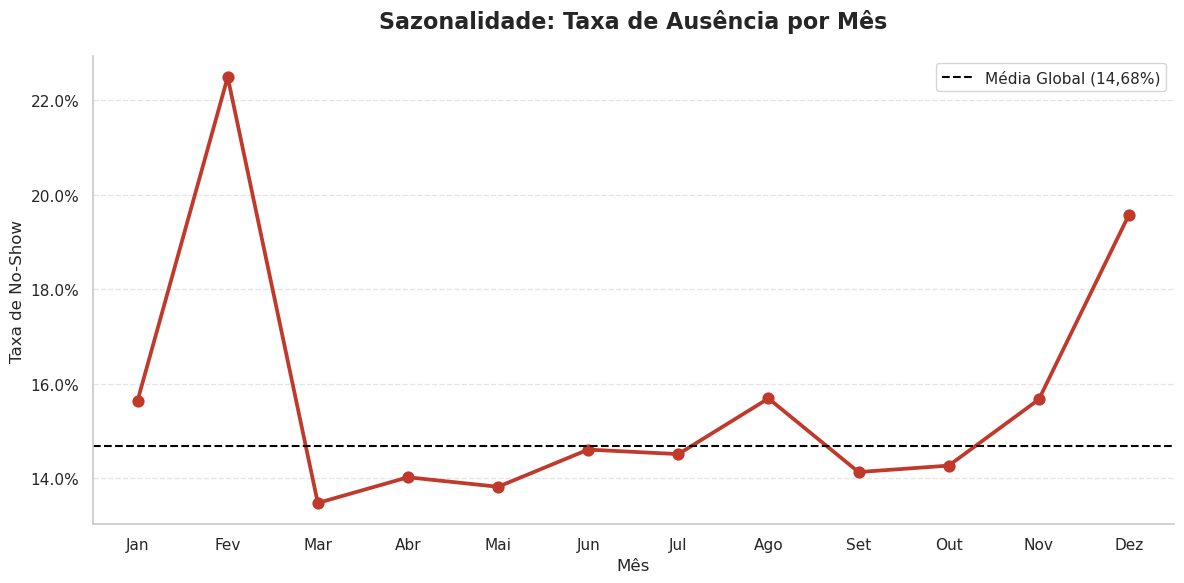

Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/13_bivariate_temporal_day_of_week_rate.png


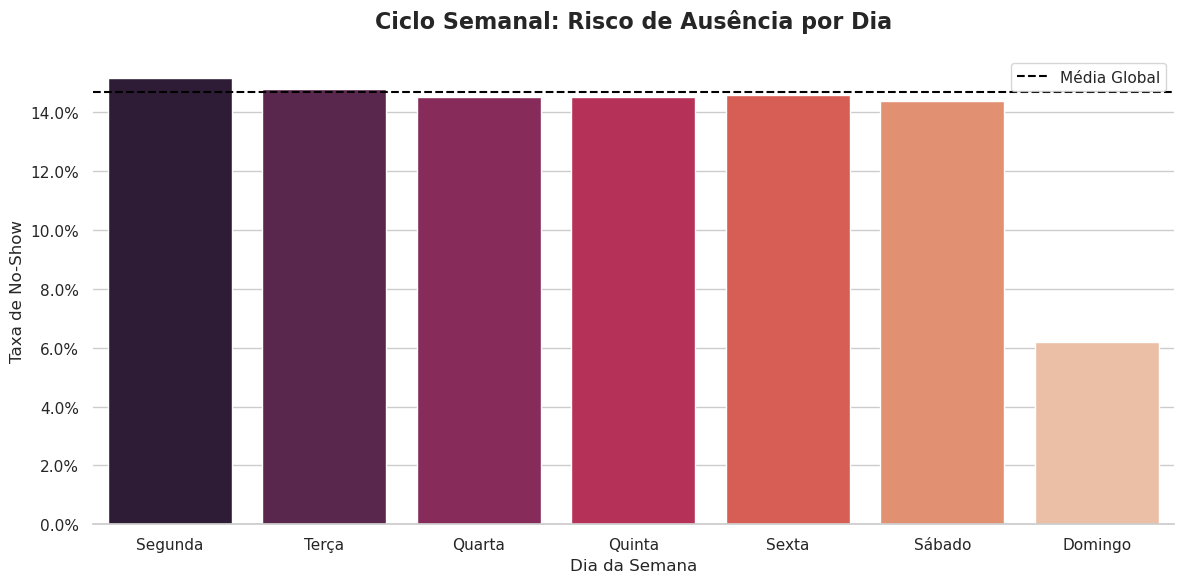

Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/14_bivariate_temporal_day_of_month_rate.png


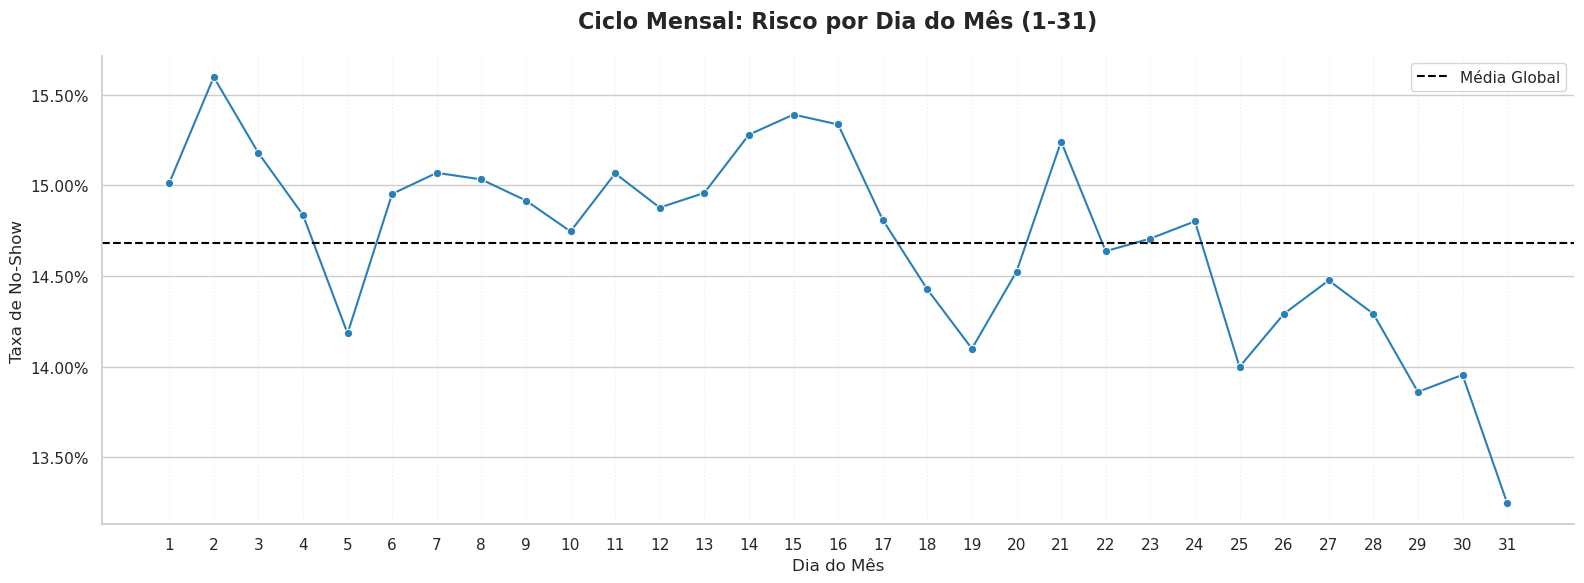

331

In [ ]:
# ==============================================================================
# Bivariate analysis: temporal features vs target
# ==============================================================================
print("--- Análise Bivariada: Features Temporais vs. Alvo ---")

# --- 1. Prepare Data ---
# Ensure column dia_da_semana.
if 'dia_da_semana' not in df_2023.columns:
    require_columns(['dta_atend'], context='temporal bivariate analysis')
    df_2023['dia_da_semana'] = df_2023['dta_atend'].dt.dayofweek

require_columns(['mes_consulta', 'dia_da_semana', 'dia_consulta', TARGET], context='temporal bivariate analysis')

# Maps PT-BR.
mapa_mes = {
    1: 'Jan', 2: 'Fev', 3: 'Mar', 4: 'Abr', 5: 'Mai', 6: 'Jun',
    7: 'Jul', 8: 'Ago', 9: 'Set', 10: 'Out', 11: 'Nov', 12: 'Dez'
}
mapa_dia_semana = {
    0: 'Segunda', 1: 'Terça', 2: 'Quarta', 3: 'Quinta',
    4: 'Sexta', 5: 'Sábado', 6: 'Domingo'
}

# Clean dataframe for plotting.
df_plot = df_2023[[TARGET, 'mes_consulta', 'dia_da_semana', 'dia_consulta']].copy()
df_plot['mes_nome'] = df_plot['mes_consulta'].map(mapa_mes)
df_plot['dia_semana_nome'] = df_plot['dia_da_semana'].map(mapa_dia_semana)

# Global benchmark.
global_rate = df_2023[TARGET].mean()

# Save rate tables.
month_rate = df_plot.groupby(['mes_consulta', 'mes_nome'], observed=True)[TARGET].agg(count='count', no_show_count='sum', no_show_rate='mean').reset_index()
weekday_rate = df_plot.groupby(['dia_da_semana', 'dia_semana_nome'], observed=True)[TARGET].agg(count='count', no_show_count='sum', no_show_rate='mean').reset_index()
day_month_rate = df_plot.groupby('dia_consulta', observed=True)[TARGET].agg(count='count', no_show_count='sum', no_show_rate='mean').reset_index()

save_table(month_rate, 'bivariate_temporal_month_vs_target.csv')
save_table(weekday_rate, 'bivariate_temporal_day_of_week_vs_target.csv')
save_table(day_month_rate, 'bivariate_temporal_day_of_month_vs_target.csv')

# =====================================================================
# --- 2. Plot 1: Monthly Seasonality ---
# =====================================================================
plt.figure(figsize=(12, 6))
mes_order = ['Jan', 'Fev', 'Mar', 'Abr', 'Mai', 'Jun', 'Jul', 'Ago', 'Set', 'Out', 'Nov', 'Dez']

ax1 = sns.pointplot(
    data=month_rate,
    x='mes_nome',
    y='no_show_rate',
    order=mes_order,
    color='#c0392b',
    markers='o',
    linestyles='-',
    errorbar=None
)

ax1.set_title('Sazonalidade: Taxa de Ausência por Mês', fontsize=16, fontweight='bold', pad=20)
ax1.set_xlabel('Mês', fontsize=12)
ax1.set_ylabel('Taxa de No-Show', fontsize=12)
ax1.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0))
ax1.axhline(global_rate, color='black', linestyle='--', label=f'Média Global ({br_percent(global_rate)})')
ax1.legend()
ax1.grid(axis='y', linestyle='--', alpha=0.5)
sns.despine()
plt.tight_layout()
save_current_figure('12_bivariate_temporal_month_rate')
plt.show()

# =====================================================================
# --- 3. Plot 2: Weekly Cycle ---
# =====================================================================
plt.figure(figsize=(12, 6))
dia_order = ['Segunda', 'Terça', 'Quarta', 'Quinta', 'Sexta', 'Sábado', 'Domingo']

ax2 = sns.barplot(
    data=weekday_rate,
    x='dia_semana_nome',
    y='no_show_rate',
    order=dia_order,
    palette='rocket',
    legend=False,
    errorbar=None
)

ax2.set_title('Ciclo Semanal: Risco de Ausência por Dia', fontsize=16, fontweight='bold', pad=20)
ax2.set_xlabel('Dia da Semana', fontsize=12)
ax2.set_ylabel('Taxa de No-Show', fontsize=12)
ax2.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0))
ax2.axhline(global_rate, color='black', linestyle='--', label='Média Global')
ax2.legend()
sns.despine(left=True)
plt.tight_layout()
save_current_figure('13_bivariate_temporal_day_of_week_rate')
plt.show()

# =====================================================================
# --- 4. Plot 3: Monthly Cycle (1 to 31) ---
# =====================================================================
plt.figure(figsize=(16, 6))

ax3 = sns.lineplot(
    data=day_month_rate,
    x='dia_consulta',
    y='no_show_rate',
    color='#2980b9',
    marker='o',
    errorbar=None
)

ax3.set_title('Ciclo Mensal: Risco por Dia do Mês (1-31)', fontsize=16, fontweight='bold', pad=20)
ax3.set_xlabel('Dia do Mês', fontsize=12)
ax3.set_ylabel('Taxa de No-Show', fontsize=12)
ax3.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1.0))
ax3.set_xticks(range(1, 32))
ax3.axhline(global_rate, color='black', linestyle='--', label='Média Global')
ax3.legend()
ax3.grid(axis='x', linestyle=':', alpha=0.3)
sns.despine()
plt.tight_layout()
save_current_figure('14_bivariate_temporal_day_of_month_rate')
plt.show()

del df_plot
gc.collect()


--- Análise Multivariada: Matriz de Correlação ---
Correlation columns (17): ['ausencia', 'idade_usuario', 'tempo_espera', 'distance_km', 'contagem_faltas_anteriores', 'total_consultas_anteriores', 'percentual_faltas_anteriores', 'cep_prefix_len_usuario', 'cep_prefix_len_cnes', 'mesma_unidade_anterior', 'mesma_cidade', 'mesmo_estado', 'mesma_regiao', 'cep_aprox_usuario', 'cep_aprox_cnes', 'dia_consulta', 'mes_consulta']
Saved table: ../reports/descriptive_analysis_refreshed_v3/tables/correlation_matrix_pearson.csv
Saved table: ../reports/descriptive_analysis_refreshed_v3/tables/correlation_matrix_spearman.csv
Matriz de Correlação de Pearson (relações lineares com o alvo):


,pearson_corr_with_target
ausencia,1.000000
tempo_espera,0.114637
percentual_faltas_anteriores,0.106685
contagem_faltas_anteriores,0.073867
distance_km,0.016258
cep_aprox_usuario,0.015666
cep_aprox_cnes,0.014970
mes_consulta,0.005866
mesma_cidade,0.000490
dia_consulta,-0.009042


---------------------------------
Matriz de Correlação de Spearman (relações monotônicas com o alvo):


,spearman_corr_with_target
ausencia,1.000000
tempo_espera,0.157263
percentual_faltas_anteriores,0.098435
contagem_faltas_anteriores,0.096269
distance_km,0.050776
cep_aprox_usuario,0.015666
cep_aprox_cnes,0.014970
mes_consulta,0.007425
mesma_cidade,0.000490
dia_consulta,-0.009090


---------------------------------
Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/15_correlation_heatmap_pearson.png


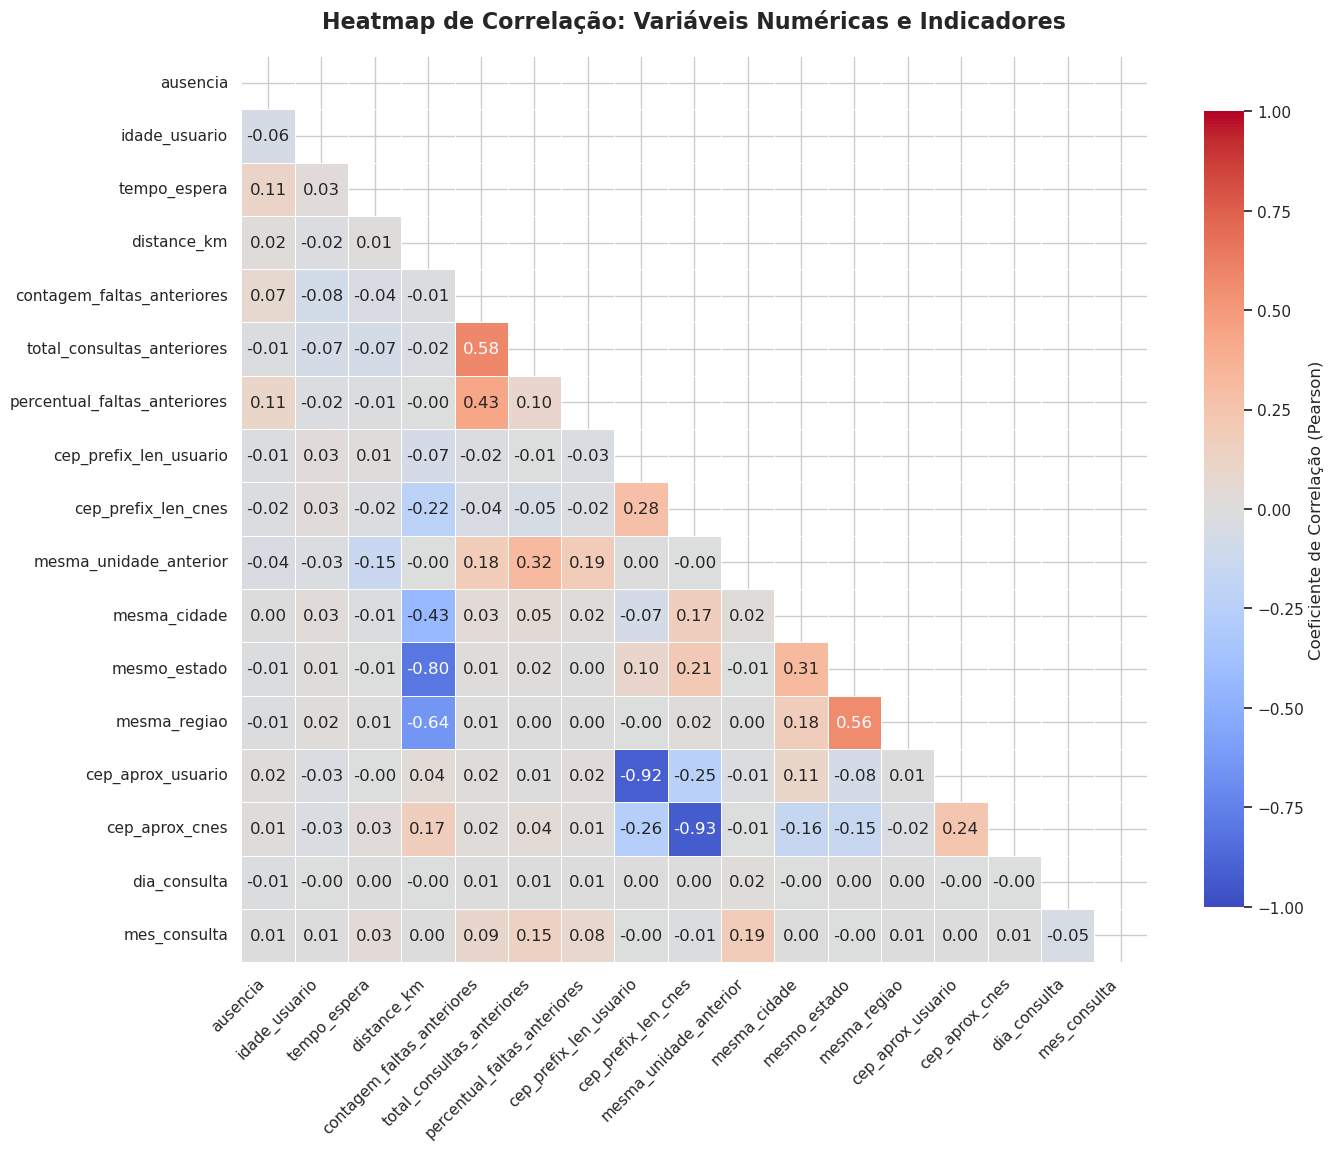

Saved figure: ../reports/descriptive_analysis_refreshed_v3/figures/16_correlation_heatmap_spearman.png


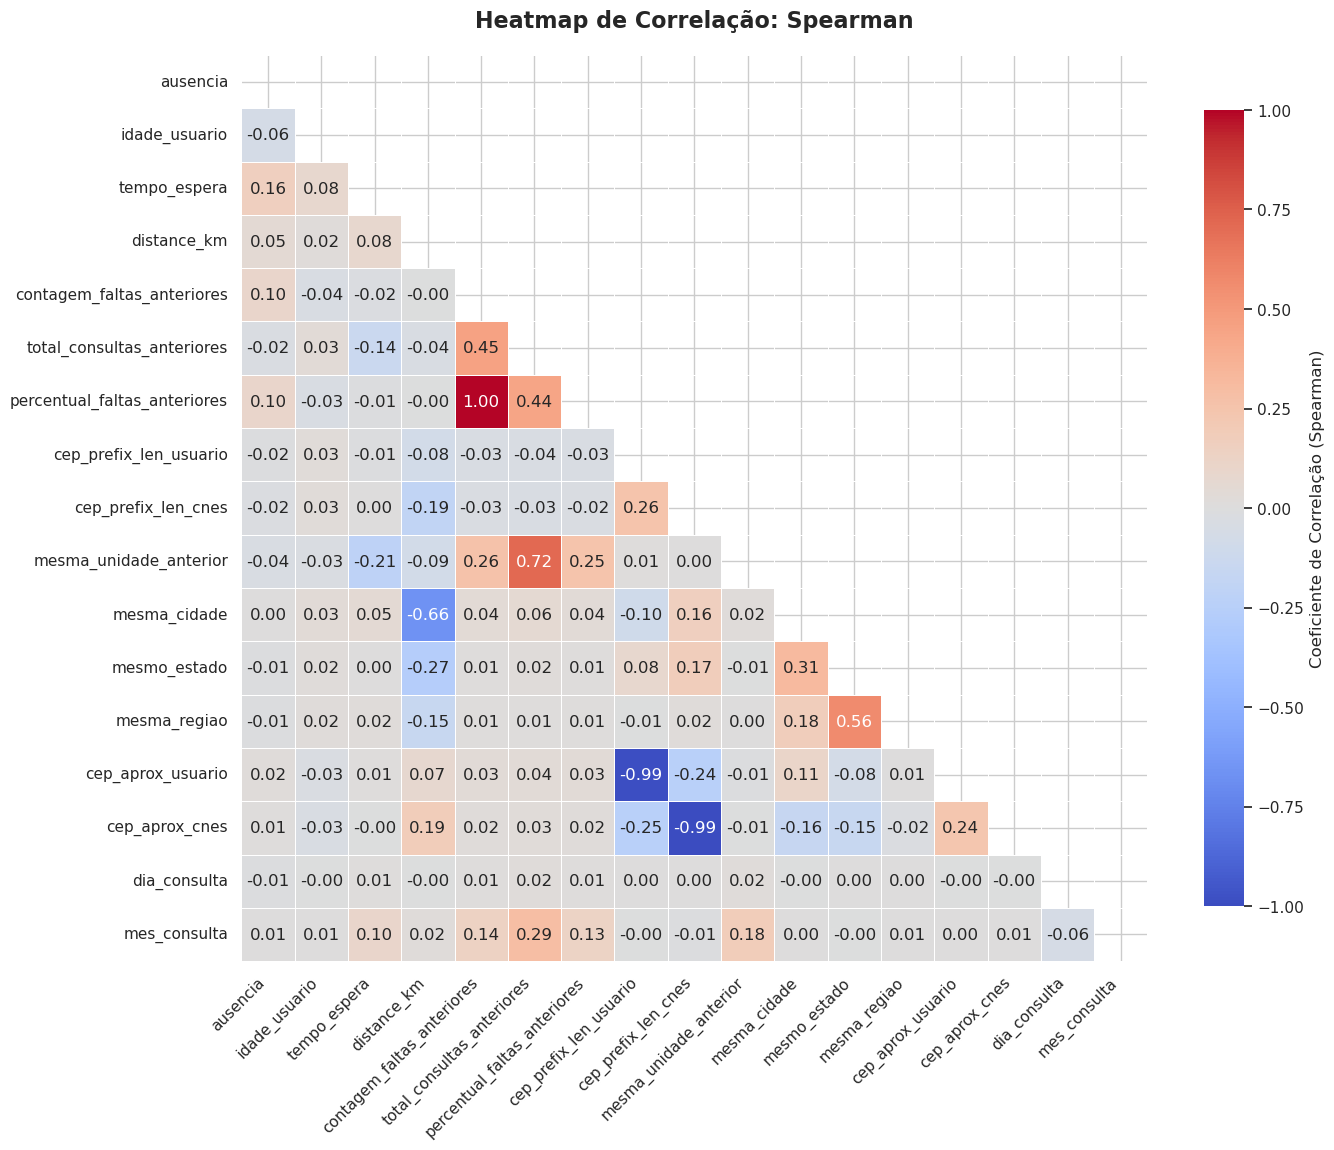

14797

In [ ]:
# ==============================================================================
# Multivariate analysis: correlation matrix
# ==============================================================================
print("--- Análise Multivariada: Matriz de Correlação ---")

# --- 1. Select Numeric Features ---
# Includes the target ('ausencia') to observe linear relationships.
# Binary indicators are included because they are numeric engineered features.
numerical_cols = available_columns([
    TARGET,
    'idade_usuario',
    'tempo_espera',
    'distance_km',
    'contagem_faltas_anteriores',
    'total_consultas_anteriores',
    'percentual_faltas_anteriores',
    'cep_prefix_len_usuario',
    'cep_prefix_len_cnes',
    'mesma_unidade_anterior',
    'mesma_cidade',
    'mesmo_estado',
    'mesma_regiao',
    'cep_aprox_usuario',
    'cep_aprox_cnes',
    'dia_consulta',
    'mes_consulta',
])

print(f"Correlation columns ({len(numerical_cols)}): {numerical_cols}")

# Create subset
# .corr() ignores NaNs automatically. It converts to numeric when possible.
df_corr = df_2023[numerical_cols].apply(pd.to_numeric, errors='coerce')

# --- 2. Calculate Correlation Matrices ---
pearson_corr = df_corr.corr(method='pearson')
spearman_corr = df_corr.corr(method='spearman')

save_table(pearson_corr.reset_index().rename(columns={'index': 'feature'}), 'correlation_matrix_pearson.csv')
save_table(spearman_corr.reset_index().rename(columns={'index': 'feature'}), 'correlation_matrix_spearman.csv')

print("Matriz de Correlação de Pearson (relações lineares com o alvo):")
display(pearson_corr[TARGET].sort_values(ascending=False).to_frame('pearson_corr_with_target'))
print("---------------------------------")

print("Matriz de Correlação de Spearman (relações monotônicas com o alvo):")
display(spearman_corr[TARGET].sort_values(ascending=False).to_frame('spearman_corr_with_target'))
print("---------------------------------")

# --- 3. Generate Pearson Heatmap ---
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(pearson_corr, dtype=bool))

ax = sns.heatmap(
    pearson_corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=.5,
    cbar_kws={'shrink': .8, 'label': 'Coeficiente de Correlação (Pearson)'}
)
ax.set_title('Heatmap de Correlação: Variáveis Numéricas e Indicadores', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
save_current_figure('15_correlation_heatmap_pearson')
plt.show()

# --- 4. Generate Spearman Heatmap ---
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(spearman_corr, dtype=bool))

ax = sns.heatmap(
    spearman_corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=.5,
    cbar_kws={'shrink': .8, 'label': 'Coeficiente de Correlação (Spearman)'}
)
ax.set_title('Heatmap de Correlação: Spearman', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
save_current_figure('16_correlation_heatmap_spearman')
plt.show()

del df_corr
gc.collect()


In [ ]:
# ==============================================================================
# Final feature inventory and notebook output summary
# ==============================================================================
print("--- Inventário Final das Features Analisadas ---")

feature_inventory = []

def add_inventory(group_name, features):
    for feature in features:
        feature_inventory.append({
            'analysis_group': group_name,
            'feature': feature,
            'exists_in_dataset': feature in df_2023.columns,
            'dtype': str(df_2023[feature].dtype) if feature in df_2023.columns else None,
            'nunique': int(df_2023[feature].nunique(dropna=False)) if feature in df_2023.columns else None,
        })

add_inventory('target', [TARGET])
add_inventory('univariate_numerical', numerical_features)
add_inventory('bivariate_numerical', bivariate_numerical_features)
add_inventory('categorical', categorical_features)
add_inventory('bivariate_categorical', bivariate_categorical_features)
add_inventory('binary_geographic', binary_features)
add_inventory('correlation_matrix', numerical_cols)

feature_inventory_df = pd.DataFrame(feature_inventory).drop_duplicates()
save_table(feature_inventory_df, 'feature_inventory_analyzed.csv')
display(feature_inventory_df)

print("\nNotebook outputs:")
print(f"Tables saved in: {TABLE_DIR}")
print(f"Figures saved in: {FIG_DIR}")
print("\nAnalysis complete.")


--- Inventário Final das Features Analisadas ---
Saved table: ../reports/descriptive_analysis_refreshed_v3/tables/feature_inventory_analyzed.csv


,analysis_group,feature,exists_in_dataset,dtype,nunique
0,target,ausencia,True,Int8,2
1,univariate_numerical,idade_usuario,True,Int16,119
2,univariate_numerical,tempo_espera,True,Int16,2399
3,univariate_numerical,distance_km,True,float32,934657
4,univariate_numerical,contagem_faltas_anteriores,True,Int32,59
5,univariate_numerical,total_consultas_anteriores,True,Int32,219
6,univariate_numerical,percentual_faltas_anteriores,True,float32,2140
7,univariate_numerical,cep_prefix_len_usuario,True,Int8,4
8,univariate_numerical,cep_prefix_len_cnes,True,Int8,4
9,bivariate_numerical,idade_usuario,True,Int16,119



Notebook outputs:
Tables saved in: ../reports/descriptive_analysis_refreshed_v3/tables
Figures saved in: ../reports/descriptive_analysis_refreshed_v3/figures

Analysis complete.
